# In Silico `Toxicity` prediction for `Ebola` AntiViral Candidates

This notebook implements a statistically grounded, **FDA-approved-AntiViral-reference-driven** workflow for ranking generated AntiViral candidates using:

- **pPotency (pIC50)** (higher is better)
- **Toxicity burden** (lower is better)
- **ADME feasibility** (higher is better)

The design follows three core ideas from the literature:

1. **QED-style desirability scoring**  
   Heterogeneous properties should first be mapped to a common 0–1 desirability scale and then combined continuously rather than by rigid pass/fail rules.

2. **ADMET-score-style weighted aggregation**  
   ADMET endpoints should not all contribute equally. More informative and clinically important endpoints should get stronger weight.

3. **ADMET-AI reference-based interpretation**  
   ADMET properties are most meaningful when interpreted relative to an appropriate approved-drug reference set.  
   For this project, the most relevant reference set is **FDA-approved AntiVirals**.

The goal is to support **early prioritization**, not to make definitive toxicity claims.

## What this notebook does

1. Harmonizes the reference and candidate dataframes
2. Keeps only metadata, potency, toxicity, ADME, and useful physicochemical columns
3. Splits `ADMET-AI` outputs into **Toxicity** and **ADME**
4. Derives **AntiViral-reference-driven statistical weights**
5. Converts each endpoint into a **desirability score**
6. Builds:
   - `ToxicitySafety`
   - `Toxicity Score = 1 - ToxicitySafety`
   - `ADMEFeasibility`
7. Generates:
   - 2D plot: pPotency vs Toxicity burden
   - 3D plot: pPotency vs Toxicity burden vs ADME feasibility
   - Save top-20 candidates to CSV files

In [48]:
import sys
import os

# Completely suppress stderr output
sys.stderr = open(os.devnull, 'w')

# Now import everything
import warnings
warnings.filterwarnings('ignore')

import math
import numpy as np
import pandas as pd
import pubchempy as pcp
from rdkit import Chem, DataStructs
from rdkit.Chem import Descriptors, rdMolDescriptors, AllChem
from admet_ai import ADMETModel
from admet_ai.drugbank import get_drugbank
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import matplotlib.patches as patches
from matplotlib.patches import ConnectionPatch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.lines as mlines, math
from scipy.stats import percentileofscore

## Define data directory for model trained on `ChEMBL + PubChem` bioassay dataset

In [49]:
target_organism = "combinedEbolaVirus"

In [50]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
modelBuildingDataDir = os.path.join(dataDir, 'modelBuildingData/')
saveDir = os.path.join(dataDir, f"Results/{target_organism}_bestMACAW_allDB/")
os.makedirs(saveDir, exist_ok=True)

### Read `ADMET` endpoints with `pPotency`of the FDA approved Drug data from `Drugbank`

In [51]:
drugBankDrug_FDAapproved_AntiViral_wART = pd.read_csv(saveDir + f'{target_organism}Data_FDA_approved_Antivirals_ARTprediction.csv')
drugBankDrug_FDAapproved_AntiViral_wART = drugBankDrug_FDAapproved_AntiViral_wART.rename(columns={'smiles': 'SMILES'})
# Identify columns that match the string
matched_cols = drugBankDrug_FDAapproved_AntiViral_wART.filter(like='drugbank_approved_percentile').columns
# Keep everything EXCEPT those columns
drugBankDrug_FDAapproved_AntiViral_wART = drugBankDrug_FDAapproved_AntiViral_wART.drop(columns=matched_cols)
max_val = drugBankDrug_FDAapproved_AntiViral_wART['pPotency_prediction'].max()
min_val = drugBankDrug_FDAapproved_AntiViral_wART['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
drugBankDrug_FDAapproved_AntiViral_wART

pPotency_prediction range: 4.852 → 5.879


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1,5.237696,0.541353,4.176643,6.298748,0.000006,5.026341e-07,0.000067
1,Nc1nc(=O)c2ncn(COCCO)c2[nH]1,5.037581,0.543129,3.973048,6.102114,0.000009,7.904713e-07,0.000106
2,CC(C)(C)C(=O)OCOP(=O)(COCCn1cnc2c(N)ncnc21)OCO...,5.233644,0.545209,4.165035,6.302253,0.000006,4.985938e-07,0.000068
3,CC(C)CN(C[C@@H](O)[C@H](Cc1ccccc1)NC(=O)O[C@H]...,5.175844,0.542325,4.112886,6.238802,0.000007,5.770297e-07,0.000077
4,C=C[C@@H]1C[C@]1(NC(=O)[C@@H]1C[C@@H](Oc2ncc(O...,5.626048,0.541898,4.563928,6.688167,0.000002,2.050374e-07,0.000027
...,...,...,...,...,...,...,...,...
70,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@@H]1O,5.536453,0.540180,4.477700,6.595206,0.000003,2.539768e-07,0.000033
71,CC[C@@H]1[C@@H]2CN(C(=O)[C@H](C(C)(C)C)NC(=O)O...,5.878781,0.543114,4.814277,6.943285,0.000001,1.139502e-07,0.000015
72,Nc1ccn([C@H]2CC[C@@H](CO)O2)c(=O)n1,5.039875,0.540991,3.979532,6.100217,0.000009,7.939315e-07,0.000105
73,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)OC(C(=O)...,5.297290,0.545680,4.227758,6.366822,0.000005,4.297122e-07,0.000059


In [52]:
drugBankDrug_FDAapproved_AntiViral_wToxicity = pd.read_csv(dataDir + '/Toxicity/DrugBank/drugBankDrug_FDAapproved_antiviral_wToxicity.csv')
drugBankDrug_FDAapproved_AntiViral_wToxicity["source_DataBase"] = "FDA_Antivirals"
drugBankDrug_FDAapproved_AntiViral_wToxicity = drugBankDrug_FDAapproved_AntiViral_wToxicity.rename(columns={'smiles': 'SMILES'})
drugBankDrug_FDAapproved_AntiViral_wToxicity

,Unnamed: 0,SMILES,ATC_code,Drug_Type,molecular_weight,logP,hydrogen_bond_acceptors,hydrogen_bond_donors,Lipinski,QED,...,Clearance_Hepatocyte_AZ_drugbank_approved_percentile,Clearance_Microsome_AZ_drugbank_approved_percentile,Half_Life_Obach_drugbank_approved_percentile,HydrationFreeEnergy_FreeSolv_drugbank_approved_percentile,LD50_Zhu_drugbank_approved_percentile,Lipophilicity_AstraZeneca_drugbank_approved_percentile,PPBR_AZ_drugbank_approved_percentile,Solubility_AqSolDB_drugbank_approved_percentile,VDss_Lombardo_drugbank_approved_percentile,source_DataBase
0,0,Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1,J05AF;J05AR,antiviral,286.339,1.09230,7,3,4.0,0.727230,...,14.928267,11.942613,38.891043,12.407910,40.674680,56.029469,33.385033,62.582396,36.719659,FDA_Antivirals
1,1,Nc1nc(=O)c2ncn(COCCO)c2[nH]1,J05AB,antiviral,225.208,-1.33180,7,3,4.0,0.554386,...,37.495153,7.289647,10.779372,2.210159,17.409849,13.067080,12.679333,70.337340,68.476154,FDA_Antivirals
2,2,CC(C)(C)C(=O)OCOP(=O)(COCCn1cnc2c(N)ncnc21)OCO...,J05AF,antiviral,501.477,2.70250,13,1,2.0,0.207152,...,91.818534,96.936797,17.138426,57.658007,27.025979,62.000775,43.544009,51.298953,49.670415,FDA_Antivirals
3,3,CC(C)CN(C[C@@H](O)[C@H](Cc1ccccc1)NC(=O)O[C@H]...,J05AE,antiviral,505.637,2.40280,7,3,3.0,0.399740,...,84.722761,96.316402,23.652579,45.637844,82.667701,75.843350,59.790617,21.558744,71.733230,FDA_Antivirals
4,4,C=C[C@@H]1C[C@]1(NC(=O)[C@@H]1C[C@@H](Oc2ncc(O...,J05AP,antiviral,748.299,3.85380,10,3,3.0,0.285739,...,34.082978,83.753393,65.878247,44.241954,98.953083,77.975960,79.526948,10.120202,57.153936,FDA_Antivirals
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,72,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@@H]1O,J05AB,antiviral,267.245,-1.98000,9,4,4.0,0.490520,...,21.054672,28.460644,47.227608,1.318340,25.009694,13.454827,7.367197,78.673905,13.144630,FDA_Antivirals
73,73,CC[C@@H]1[C@@H]2CN(C(=O)[C@H](C(C)(C)C)NC(=O)O...,J05AP,antiviral,868.948,4.95650,11,3,2.0,0.303895,...,54.168282,96.200078,60.178364,62.504847,99.612253,80.302443,89.957348,2.248934,87.902288,FDA_Antivirals
74,74,Nc1ccn([C@H]2CC[C@@H](CO)O2)c(=O)n1,J05AF,antiviral,211.221,-0.50460,6,2,4.0,0.687546,...,37.844126,9.616130,49.864288,3.916247,25.785188,12.601784,6.397829,87.708414,48.623497,FDA_Antivirals
75,75,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)OC(C(=O)...,J05AH,antiviral,332.313,-3.78550,7,7,3.0,0.188042,...,3.955021,6.824351,17.797596,1.861187,10.314075,0.504071,3.140752,88.716557,84.257464,FDA_Antivirals


In [53]:
def canonicalize(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        return Chem.MolToSmiles(mol) if mol else None
    except:
        return None

# Canonicalize SMILES in both DataFrames
drugBankDrug_FDAapproved_AntiViral_wART["canon_SMILES"] = \
    drugBankDrug_FDAapproved_AntiViral_wART["SMILES"].apply(canonicalize)

drugBankDrug_FDAapproved_AntiViral_wToxicity["canon_SMILES"] = \
    drugBankDrug_FDAapproved_AntiViral_wToxicity["SMILES"].apply(canonicalize)

# Merge on canonical SMILES
drugBankDrug_FDAapproved_AntiViral_wART_wADMET = pd.merge(
    drugBankDrug_FDAapproved_AntiViral_wART,
    drugBankDrug_FDAapproved_AntiViral_wToxicity.drop(columns="SMILES"),  
    on="canon_SMILES",
    how="inner"
).drop(columns="canon_SMILES").reset_index(drop=True)

print(f"wART shape        : {drugBankDrug_FDAapproved_AntiViral_wART.shape}")
print(f"wToxicity shape   : {drugBankDrug_FDAapproved_AntiViral_wToxicity.shape}")
print(f"Merged shape      : {drugBankDrug_FDAapproved_AntiViral_wART_wADMET.shape}")

wART shape        : (75, 9)
wToxicity shape   : (77, 104)
Merged shape      : (75, 110)


### Convert `SMILES` to `Canonical SMILES` for comparison

In [54]:
def canonicalizeSmiles(smilesValue):
    if pd.isna(smilesValue):
        return None

    smilesStr = str(smilesValue).strip()
    if smilesStr == "":
        return None

    mol = Chem.MolFromSmiles(smilesStr)
    if mol is None:
        return None

    return Chem.MolToSmiles(mol, canonical=True)

drugBankDrug_FDAapproved_AntiViral_wART_wADMET = drugBankDrug_FDAapproved_AntiViral_wART_wADMET.copy()
drugBankDrug_FDAapproved_AntiViral_wART_wADMET["SMILES"] = (
    drugBankDrug_FDAapproved_AntiViral_wART_wADMET["SMILES"].apply(canonicalizeSmiles)
)

drugBankDrug_FDAapproved_AntiViral_wART_wADMET

,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,Unnamed: 0,ATC_code,...,Clearance_Hepatocyte_AZ_drugbank_approved_percentile,Clearance_Microsome_AZ_drugbank_approved_percentile,Half_Life_Obach_drugbank_approved_percentile,HydrationFreeEnergy_FreeSolv_drugbank_approved_percentile,LD50_Zhu_drugbank_approved_percentile,Lipophilicity_AstraZeneca_drugbank_approved_percentile,PPBR_AZ_drugbank_approved_percentile,Solubility_AqSolDB_drugbank_approved_percentile,VDss_Lombardo_drugbank_approved_percentile,source_DataBase
0,Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1,5.237696,0.541353,4.176643,6.298748,0.000006,5.026341e-07,0.000067,0,J05AF;J05AR,...,14.928267,11.942613,38.891043,12.407910,40.674680,56.029469,33.385033,62.582396,36.719659,FDA_Antivirals
1,Nc1nc(=O)c2ncn(COCCO)c2[nH]1,5.037581,0.543129,3.973048,6.102114,0.000009,7.904713e-07,0.000106,1,J05AB,...,37.495153,7.289647,10.779372,2.210159,17.409849,13.067080,12.679333,70.337340,68.476154,FDA_Antivirals
2,CC(C)(C)C(=O)OCOP(=O)(COCCn1cnc2c(N)ncnc21)OCO...,5.233644,0.545209,4.165035,6.302253,0.000006,4.985938e-07,0.000068,2,J05AF,...,91.818534,96.936797,17.138426,57.658007,27.025979,62.000775,43.544009,51.298953,49.670415,FDA_Antivirals
3,CC(C)CN(C[C@@H](O)[C@H](Cc1ccccc1)NC(=O)O[C@H]...,5.175844,0.542325,4.112886,6.238802,0.000007,5.770297e-07,0.000077,3,J05AE,...,84.722761,96.316402,23.652579,45.637844,82.667701,75.843350,59.790617,21.558744,71.733230,FDA_Antivirals
4,C=C[C@@H]1C[C@]1(NC(=O)[C@@H]1C[C@@H](Oc2ncc(O...,5.626048,0.541898,4.563928,6.688167,0.000002,2.050374e-07,0.000027,4,J05AP,...,34.082978,83.753393,65.878247,44.241954,98.953083,77.975960,79.526948,10.120202,57.153936,FDA_Antivirals
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@@H]1O,5.536453,0.540180,4.477700,6.595206,0.000003,2.539768e-07,0.000033,72,J05AB,...,21.054672,28.460644,47.227608,1.318340,25.009694,13.454827,7.367197,78.673905,13.144630,FDA_Antivirals
71,CC[C@@H]1[C@@H]2CN(C(=O)[C@H](C(C)(C)C)NC(=O)O...,5.878781,0.543114,4.814277,6.943285,0.000001,1.139502e-07,0.000015,73,J05AP,...,54.168282,96.200078,60.178364,62.504847,99.612253,80.302443,89.957348,2.248934,87.902288,FDA_Antivirals
72,Nc1ccn([C@H]2CC[C@@H](CO)O2)c(=O)n1,5.039875,0.540991,3.979532,6.100217,0.000009,7.939315e-07,0.000105,74,J05AF,...,37.844126,9.616130,49.864288,3.916247,25.785188,12.601784,6.397829,87.708414,48.623497,FDA_Antivirals
73,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)OC(C(=O)...,5.297290,0.545680,4.227758,6.366822,0.000005,4.297122e-07,0.000059,75,J05AH,...,3.955021,6.824351,17.797596,1.861187,10.314075,0.504071,3.140752,88.716557,84.257464,FDA_Antivirals


### Retain only `toxicity`, `mechanistic`, and `ADME` related endpoints

In [55]:
# Potency-related columns
dataCols = [
    "SMILES",
    "ATC_code", "Drug_Type", "source_DataBase"
]

# Potency-related columns
potencyCols = [
    "pPotency_prediction", "pPotency_std",
    "pPotency_lower_95CI", "pPotency_upper_95CI",
    "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"
]

# Core toxicity endpoints
coreToxicityCols = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu"
]

# Mechanistic alert endpoints
mechanisticAlertCols = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma"
]

# Mechanistic alert endpoints
# ADME / metabolism liability endpoints
admeLiabilityCols = [
    "BBB_Martins",
    "Pgp_Broccatelli",
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith"
]

# Keep only columns that exist
selectedCols = dataCols + potencyCols + [
    col for col in (coreToxicityCols + mechanisticAlertCols + admeLiabilityCols)
    if col in drugBankDrug_FDAapproved_AntiViral_wART_wADMET.columns
]

drugBankDrug_FDAapproved_AntiViral_wART_wADMET = drugBankDrug_FDAapproved_AntiViral_wART_wADMET[selectedCols].copy()

print("Filtered dataframe shape:", drugBankDrug_FDAapproved_AntiViral_wART_wADMET.shape)
drugBankDrug_FDAapproved_AntiViral_wART_wADMET.head()

Filtered dataframe shape: (75, 44)


,SMILES,ATC_code,Drug_Type,source_DataBase,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,...,PAMPA_NCATS,Bioavailability_Ma,CYP1A2_Veith,CYP2C19_Veith,CYP2C9_Substrate_CarbonMangels,CYP2C9_Veith,CYP2D6_Substrate_CarbonMangels,CYP2D6_Veith,CYP3A4_Substrate_CarbonMangels,CYP3A4_Veith
0,Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1,J05AF;J05AR,antiviral,FDA_Antivirals,5.237696,0.541353,4.176643,6.298748,0.000006,5.026341e-07,...,0.682142,0.900314,0.452779,0.051874,0.091861,0.045425,0.090017,0.021314,0.279831,0.205709
1,Nc1nc(=O)c2ncn(COCCO)c2[nH]1,J05AB,antiviral,FDA_Antivirals,5.037581,0.543129,3.973048,6.102114,0.000009,7.904713e-07,...,0.024756,0.576378,0.003340,0.000488,0.049340,0.001506,0.021066,0.000547,0.052355,0.000207
2,CC(C)(C)C(=O)OCOP(=O)(COCCn1cnc2c(N)ncnc21)OCO...,J05AF,antiviral,FDA_Antivirals,5.233644,0.545209,4.165035,6.302253,0.000006,4.985938e-07,...,0.950870,0.675607,0.003372,0.131225,0.038136,0.208273,0.030708,0.023926,0.875641,0.698997
3,CC(C)CN(C[C@@H](O)[C@H](Cc1ccccc1)NC(=O)O[C@H]...,J05AE,antiviral,FDA_Antivirals,5.175844,0.542325,4.112886,6.238802,0.000007,5.770297e-07,...,0.789846,0.558204,0.087809,0.779787,0.377403,0.749684,0.240774,0.437612,0.715497,0.982761
4,C=C[C@@H]1C[C@]1(NC(=O)[C@@H]1C[C@@H](Oc2ncc(O...,J05AP,antiviral,FDA_Antivirals,5.626048,0.541898,4.563928,6.688167,0.000002,2.050374e-07,...,0.946405,0.847933,0.093194,0.616985,0.333340,0.768412,0.095483,0.129816,0.905202,0.989531


# Check ADMET properties for `buyable` AntiVirals

### 1. Read `ART` predicted `pPotency` of all the compounds

In [56]:
Ebola_wART_Buyable_predicted_all = pd.read_csv(saveDir + f'{target_organism}_all_Buyable_AntiVirals_ARTprediction.csv')
max_val = Ebola_wART_Buyable_predicted_all['pPotency_prediction'].max()
min_val = Ebola_wART_Buyable_predicted_all['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
Ebola_wART_Buyable_predicted_all

pPotency_prediction range: 4.615 → 6.410


,SMILES,source_DataBase,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,COCC(C)NC(=O)Nc1nnc(C2CC2)s1,Enamine_Antivirals,5.105670,0.545426,4.036636,6.174704,0.000008,6.687996e-07,0.000092
1,Cn1c(=O)ccn(CC(=O)NCC2CC2)c1=O,Enamine_Antivirals,5.007438,0.547443,3.934450,6.080427,0.000010,8.309468e-07,0.000116
2,CCN(CC)CCNC(=O)c1cccnc1N1CCOCC1,Enamine_Antivirals,4.819532,0.541383,3.758420,5.880643,0.000015,1.316305e-06,0.000174
3,CCC(CNC(=O)Cc1c(C)noc1C)N1CCCC1,Enamine_Antivirals,5.087139,0.546747,4.015516,6.158762,0.000008,6.938054e-07,0.000096
4,CCC(C)(CNC(=O)Cn1ccccc1=O)N1CCOCC1,Enamine_Antivirals,5.392557,0.543045,4.328189,6.456925,0.000004,3.492006e-07,0.000047
...,...,...,...,...,...,...,...,...,...
113180,CCOC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(OC...,ChemDiv_Antivirals,5.484249,0.540973,4.423942,6.544555,0.000003,2.853942e-07,0.000038
113181,CCOC(=O)c1c(NC(=O)c2cc3nc(-c4ccc(Br)cc4)cc(C(F...,ChemDiv_Antivirals,5.403186,0.539742,4.345291,6.461081,0.000004,3.458748e-07,0.000045
113182,COC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4cccs4)n...,ChemDiv_Antivirals,5.406166,0.541336,4.345146,6.467185,0.000004,3.410477e-07,0.000045
113183,COc1cc(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(Br)cc4)...,ChemDiv_Antivirals,5.376473,0.541037,4.316041,6.436905,0.000004,3.656748e-07,0.000048


### plot `pPotency` distribution with error bars

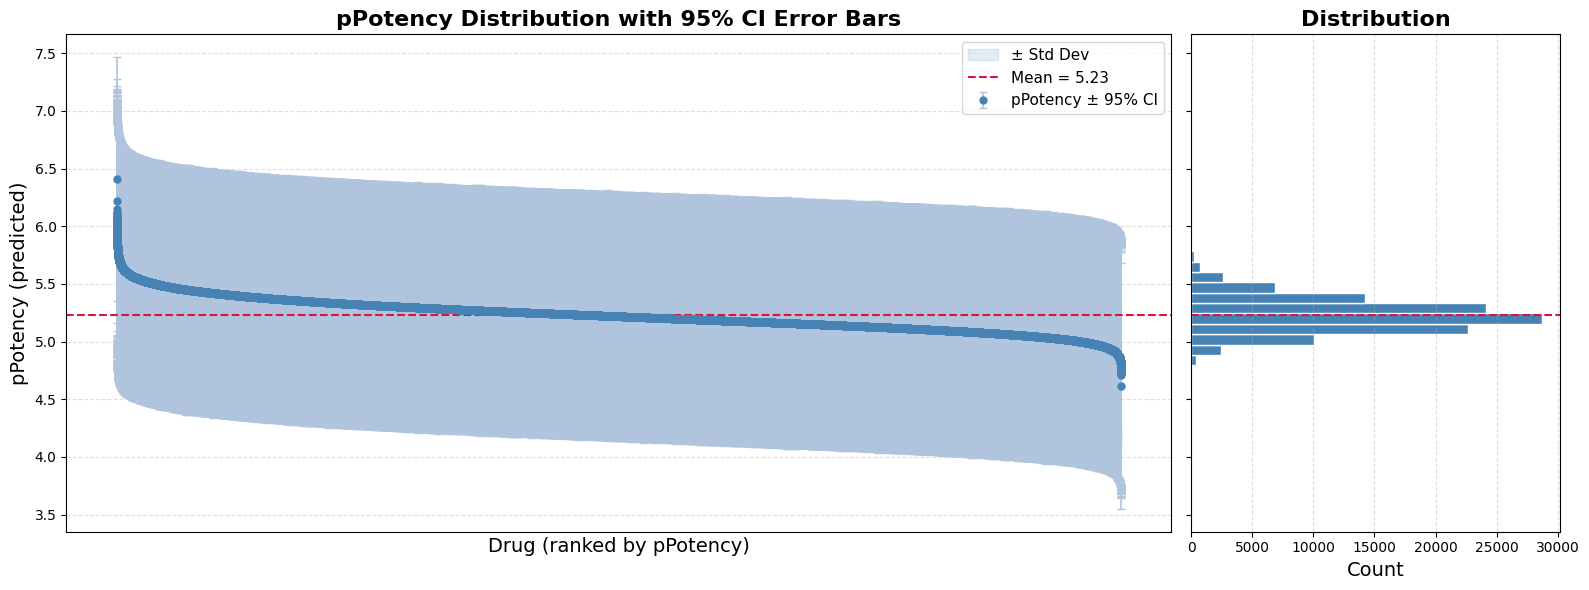

In [57]:
ppotencyDF = Ebola_wART_Buyable_predicted_all.sort_values(
    "pPotency_prediction", ascending=False).reset_index(drop=True)

x = np.arange(len(ppotencyDF))
pred = ppotencyDF["pPotency_prediction"]
yerr = np.array([pred - ppotencyDF["pPotency_lower_95CI"],
                 ppotencyDF["pPotency_upper_95CI"] - pred])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6),
                                gridspec_kw={"width_ratios": [3, 1]}, sharey=True)

# ── Scatter + error bars ──────────────────────────────────────────────────────
ax1.errorbar(x, pred, yerr=yerr, fmt='o', color='steelblue', ecolor='lightsteelblue',
             elinewidth=1.2, capsize=3, markersize=5, alpha=1, label="pPotency ± 95% CI")
ax1.fill_between(x, pred - ppotencyDF["pPotency_std"], pred + ppotencyDF["pPotency_std"],
                 alpha=0.15, color='steelblue', label="± Std Dev")
ax1.axhline(pred.mean(),   color='crimson',    linestyle='--', linewidth=1.5, label=f'Mean = {pred.mean():.2f}')
#ax1.axhline(pred.median(), color='darkorange', linestyle=':',  linewidth=1.5, label=f'Median = {pred.median():.2f}')
ax1.set_xlabel("Drug (ranked by pPotency)", fontsize=14)  
ax1.set_ylabel("pPotency (predicted)",      fontsize=14) 
ax1.set_title("pPotency Distribution with 95% CI Error Bars", fontsize=16, fontweight='bold')  
ax1.set_xticks([])
ax1.legend(fontsize=11); ax1.grid(axis='y', linestyle='--', alpha=0.4)

# ── Histogram ─────────────────────────────────────────────────────────────────
ax2.hist(pred, bins=20, orientation='horizontal', color='steelblue', edgecolor='white', alpha=1)
ax2.axhline(pred.mean(),   color='crimson',    linestyle='--', linewidth=1.5)
#ax2.axhline(pred.median(), color='darkorange', linestyle=':',  linewidth=1.5)
ax2.set_xlabel("Count", fontsize=14)        
ax2.set_title("Distribution", fontsize=16, fontweight='bold') 
ax2.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
svg_path = os.path.join(saveDir, f"{target_organism}_pPotency_distribution_buyable.svg")
png_path = os.path.join(saveDir, f"{target_organism}_pPotency_distribution_buyable.png")
plt.savefig(svg_path, format="svg", dpi=600)
plt.savefig(png_path, format="png", dpi=600)
plt.show()

### Read predicted `ADMET` properties for all candidate SMILES

In [58]:
Ebola_wART_BuyableDataset_predicted_all_wToxicity = pd.read_csv(saveDir + f'{target_organism}_all_Buyable_AntiVirals_ARTprediction_wToxicity.csv')
# Identify columns that match the string
matched_cols = Ebola_wART_BuyableDataset_predicted_all_wToxicity.filter(like='drugbank_approved_percentile').columns
# Keep everything EXCEPT those columns
Ebola_wART_BuyableDataset_predicted_all_wToxicity = Ebola_wART_BuyableDataset_predicted_all_wToxicity.drop(columns=matched_cols)
max_val = Ebola_wART_BuyableDataset_predicted_all_wToxicity['pPotency_prediction'].max()
min_val = Ebola_wART_BuyableDataset_predicted_all_wToxicity['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
Ebola_wART_BuyableDataset_predicted_all_wToxicity

pPotency_prediction range: 4.615 → 6.410


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,molecular_weight,logP,...,Caco2_Wang,Clearance_Hepatocyte_AZ,Clearance_Microsome_AZ,Half_Life_Obach,HydrationFreeEnergy_FreeSolv,LD50_Zhu,Lipophilicity_AstraZeneca,PPBR_AZ,Solubility_AqSolDB,VDss_Lombardo
0,COCC(C)NC(=O)Nc1nnc(C2CC2)s1,5.105670,0.545426,4.036636,6.174704,0.000008,6.687996e-07,0.000092,256.331,1.57190,...,-4.387420,64.435593,40.445525,-0.887841,-12.251157,2.346986,1.866958,63.776392,-2.795747,-2.227612
1,Cn1c(=O)ccn(CC(=O)NCC2CC2)c1=O,5.007438,0.547443,3.934450,6.080427,0.000010,8.309468e-07,0.000116,237.259,-0.92680,...,-4.118667,36.395596,10.623648,5.505255,-15.261978,2.588685,-0.504724,40.281371,-0.807687,-1.102727
2,CCN(CC)CCNC(=O)c1cccnc1N1CCOCC1,4.819532,0.541383,3.758420,5.880643,0.000015,1.316305e-06,0.000174,306.410,0.98980,...,-4.513040,43.755997,-2.262052,28.229884,-13.875501,2.486431,-0.378004,13.197555,-0.554629,12.543866
3,CCC(CNC(=O)Cc1c(C)noc1C)N1CCCC1,5.087139,0.546747,4.015516,6.158762,0.000008,6.938054e-07,0.000096,279.384,1.82454,...,-4.838942,26.530763,-0.233076,6.638393,-11.161636,2.715900,-0.066394,26.616980,-0.733000,2.773648
4,CCC(C)(CNC(=O)Cn1ccccc1=O)N1CCOCC1,5.392557,0.543045,4.328189,6.456925,0.000004,3.492006e-07,0.000047,307.394,0.46540,...,-4.732135,59.017449,-6.087209,11.271385,-13.392374,2.247248,-0.336078,20.670329,-0.587551,4.776085
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62704,CCOC(=O)c1c(NC(=O)c2cc3nc(-c4ccc(OC)cc4)cc(C(F...,5.394282,0.540136,4.335616,6.452948,0.000004,3.524128e-07,0.000046,518.517,5.53104,...,-4.730722,80.398760,114.804424,120.250929,-9.220663,3.371748,3.856508,98.441311,-5.570580,0.703579
62705,COC(=O)c1ccc(C(=O)OC)c(NC(=O)c2cc3nc(-c4ccc(Cl...,5.337847,0.539813,4.279814,6.395881,0.000005,4.019010e-07,0.000053,532.862,4.89400,...,-4.707452,60.007165,94.408947,136.472807,-10.000819,2.649364,3.893967,96.525146,-6.358163,-1.840952
62706,O=C(Nc1cccc2c1OCO2)c1nn2c(C(F)(F)F)cc(-c3ccc(B...,5.310343,0.540605,4.250758,6.369928,0.000005,4.266506e-07,0.000056,539.695,5.81200,...,-4.720724,49.311068,61.478602,113.462363,-9.338126,3.658687,3.878444,98.976398,-7.572840,-1.263532
62707,COC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4cccs4)n...,5.595679,0.541848,4.533656,6.657701,0.000003,2.199372e-07,0.000029,555.003,6.35520,...,-4.633107,59.457291,97.702937,107.697867,-8.234177,3.655312,3.864897,99.018482,-6.029606,4.871039


### 2. AntiViral candidate prioritization by comparing with `Drugbank`

In [59]:
refDrugbankDF = drugBankDrug_FDAapproved_AntiViral_wART_wADMET.copy()
generatedCandidateDF = Ebola_wART_BuyableDataset_predicted_all_wToxicity.copy()

print("Drugbank reference dataframe shape:", refDrugbankDF.shape)
print("Generated candidate dataframe shape:", generatedCandidateDF.shape)

Drugbank reference dataframe shape: (75, 44)
Generated candidate dataframe shape: (62709, 57)


### 3. Harmonize metadata and the SMILES column

The candidate dataframe may use `SMILES` instead of `smiles`.  
This cell standardizes that and fills a few metadata fields if they are missing.

In [60]:
if "SMILES" in generatedCandidateDF.columns:
    generatedCandidateDF = generatedCandidateDF.rename(columns={"SMILES": "SMILES"})

if "ATC_code" not in generatedCandidateDF.columns:
    generatedCandidateDF["ATC_code"] = pd.NA

if "Drug_Type" not in generatedCandidateDF.columns:
    generatedCandidateDF["Drug_Type"] = "Predicted_candidate"

if "source_DataBase" not in generatedCandidateDF.columns:
    generatedCandidateDF["source_DataBase"] = "Generated"

refDrugbankDF["datasetLabel"] = "FDA-approved AntiVirals"
generatedCandidateDF["datasetLabel"] = "Generated candidates"

print("smiles in refDrugbankDF:", "SMILES" in refDrugbankDF.columns)
print("smiles in generatedCandidateDF:", "SMILES" in generatedCandidateDF.columns)

smiles in refDrugbankDF: True
smiles in generatedCandidateDF: True


### 4. Define `ADMET` column groups

We keep:
- metadata
- potency-related columns
- toxicity-related columns
- ADME-related columns
- a few physicochemical property columns such as `QED`, `logP` and `molecular_weight`

In [61]:
metadataCols = [
    "SMILES",
    "ATC_code",
    "Drug_Type",
    "source_DataBase",
    "datasetLabel",
]

potencyCols = [
    "pPotency_prediction",
    "pPotency_std",
    "pPotency_lower_95CI",
    "pPotency_upper_95CI",
    "IC50(M)_prediction",
    "IC50(M)_lower_95CI",
    "IC50(M)_upper_95CI",
]

toxicityCols = [
    "AMES",
    "Carcinogens_Lagunin",
    "ClinTox",
    "DILI",
    "Skin_Reaction",
    "hERG",
    "LD50_Zhu",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma",
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
]

admeCols = [
    "Bioavailability_Ma",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Caco2_Wang",
    "Solubility_AqSolDB",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith",
    "Pgp_Broccatelli",
    "Clearance_Hepatocyte_AZ",
    "Clearance_Microsome_AZ",
    "Half_Life_Obach",
    "PPBR_AZ",
    "VDss_Lombardo",
]

optionalCols = ["BBB_Martins"]

physicochemCols = [
    "molecular_weight",
    "logP",
    "hydrogen_bond_acceptors",
    "hydrogen_bond_donors",
    "Lipinski",
    "QED",
    "stereo_centers",
    "tpsa",
    "HydrationFreeEnergy_FreeSolv",
    "Lipophilicity_AstraZeneca",
]

keepCols = list(dict.fromkeys(metadataCols + potencyCols + toxicityCols + admeCols + optionalCols + physicochemCols))
print("Total kept columns:", len(keepCols))

Total kept columns: 61


### 5. Build aligned reference and candidate dataframes

This cell keeps the same columns in both dataframes and creates any missing columns as `NaN`

In [62]:
def ensureCols(DF, colList):
    outDF = DF.copy()
    for colName in colList:
        if colName not in outDF.columns:
            outDF[colName] = np.nan
    return outDF[colList].copy()

refScoreDF = ensureCols(refDrugbankDF, keepCols)
candScoreDF = ensureCols(generatedCandidateDF, keepCols)

print("Reference aligned shape:", refScoreDF.shape)
print("Candidate aligned shape:", candScoreDF.shape)

Reference aligned shape: (75, 61)
Candidate aligned shape: (62709, 61)


### 6. Convert relevant columns to numeric

All scoring-related columns are converted to numeric.  

In [63]:
numericCols = list(dict.fromkeys(potencyCols + toxicityCols + admeCols + optionalCols + physicochemCols))

for colName in numericCols:
    if colName in refScoreDF.columns:
        refScoreDF[colName] = pd.to_numeric(refScoreDF[colName], errors="coerce")
    if colName in candScoreDF.columns:
        candScoreDF[colName] = pd.to_numeric(candScoreDF[colName], errors="coerce")

refScoreDF["potencyConservative"] = refScoreDF["pPotency_lower_95CI"].fillna(refScoreDF["pPotency_prediction"])
candScoreDF["potencyConservative"] = candScoreDF["pPotency_lower_95CI"].fillna(candScoreDF["pPotency_prediction"])

### 7. Define endpoint metadata

This table contains:
- endpoint name
- whether it belongs to the **toxicity** or **adme** group
- the direction of desirability:
  - `lowerBetter`
  - `higherBetter`
  - `referenceMatch`


In [64]:
endpointMetaDF = pd.DataFrame([
    # Toxicity
    {"endpoint": "AMES",                "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "Carcinogens_Lagunin", "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "ClinTox",             "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "DILI",                "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "Skin_Reaction",       "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "hERG",                "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "LD50_Zhu",            "majorGroup": "toxicity", "direction": "higherBetter"},
    {"endpoint": "NR-AR-LBD",           "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-AR",               "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-AhR",              "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-Aromatase",        "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-ER-LBD",           "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-ER",               "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-PPAR-gamma",       "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "SR-ARE",              "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "SR-ATAD5",            "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "SR-HSE",              "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "SR-MMP",              "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "SR-p53",              "majorGroup": "toxicity", "direction": "lowerBetter"},

    # ADME
    {"endpoint": "Bioavailability_Ma",             "majorGroup": "adme", "direction": "higherBetter"},
    {"endpoint": "HIA_Hou",                        "majorGroup": "adme", "direction": "higherBetter"},
    {"endpoint": "PAMPA_NCATS",                    "majorGroup": "adme", "direction": "higherBetter"},
    {"endpoint": "Caco2_Wang",                     "majorGroup": "adme", "direction": "higherBetter"},
    {"endpoint": "Solubility_AqSolDB",             "majorGroup": "adme", "direction": "higherBetter"},
    {"endpoint": "CYP1A2_Veith",                   "majorGroup": "adme", "direction": "lowerBetter"},
    {"endpoint": "CYP2C19_Veith",                  "majorGroup": "adme", "direction": "lowerBetter"},
    {"endpoint": "CYP2C9_Substrate_CarbonMangels", "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "CYP2C9_Veith",                   "majorGroup": "adme", "direction": "lowerBetter"},
    {"endpoint": "CYP2D6_Substrate_CarbonMangels", "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "CYP2D6_Veith",                   "majorGroup": "adme", "direction": "lowerBetter"},
    {"endpoint": "CYP3A4_Substrate_CarbonMangels", "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "CYP3A4_Veith",                   "majorGroup": "adme", "direction": "lowerBetter"},
    {"endpoint": "Pgp_Broccatelli",                "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "Clearance_Hepatocyte_AZ",        "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "Clearance_Microsome_AZ",         "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "Half_Life_Obach",                "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "PPBR_AZ",                        "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "VDss_Lombardo",                  "majorGroup": "adme", "direction": "referenceMatch"},
])

endpointMetaDF

,endpoint,majorGroup,direction
0,AMES,toxicity,lowerBetter
1,Carcinogens_Lagunin,toxicity,lowerBetter
2,ClinTox,toxicity,lowerBetter
3,DILI,toxicity,lowerBetter
4,Skin_Reaction,toxicity,lowerBetter
5,hERG,toxicity,lowerBetter
6,LD50_Zhu,toxicity,higherBetter
7,NR-AR-LBD,toxicity,lowerBetter
8,NR-AR,toxicity,lowerBetter
9,NR-AhR,toxicity,lowerBetter


### 8. Derive fully statistical endpoint weights from FDA-approved AntiVirals from `Drugbank`

For each endpoint we compute:

- **informativeness** = inverse of the reference IQR  
  A tighter approved-AntiViral distribution means the endpoint is more constrained and therefore more informative.

- **uniqueness** = inverse redundancy penalty  
  Endpoints that are highly correlated with other endpoints in the same group get reduced weight.

The final endpoint weights are normalized inside each major group:
- `toxicity`
- `adme`

In [65]:
def robustIQR(series):
    cleanSeries = pd.to_numeric(series, errors="coerce").dropna()
    if len(cleanSeries) < 5:
        return np.nan
    q25, q75 = np.percentile(cleanSeries, [25, 75])
    return q75 - q25

weightRows = []

for majorGroupName in endpointMetaDF["majorGroup"].unique():
    groupMetaDF = endpointMetaDF[endpointMetaDF["majorGroup"] == majorGroupName].copy()
    groupEndpoints = groupMetaDF["endpoint"].tolist()

    groupRefDF = refScoreDF[groupEndpoints].apply(pd.to_numeric, errors="coerce")
    groupCorrDF = groupRefDF.corr().abs()

    for endpointName in groupEndpoints:
        series = groupRefDF[endpointName]
        iqrValue = robustIQR(series)

        informativeness = 1.0 / (iqrValue + 1e-6) if pd.notna(iqrValue) else 1.0

        otherEndpoints = [x for x in groupEndpoints if x != endpointName]
        if len(otherEndpoints) > 0 and endpointName in groupCorrDF.index:
            meanAbsCorr = groupCorrDF.loc[endpointName, otherEndpoints].dropna().mean()
            uniqueness = max(1.0 - meanAbsCorr, 1e-3) if pd.notna(meanAbsCorr) else 1.0
        else:
            uniqueness = 1.0

        rawWeight = informativeness * uniqueness

        weightRows.append({
            "endpoint": endpointName,
            "majorGroup": majorGroupName,
            "direction": groupMetaDF.loc[groupMetaDF["endpoint"] == endpointName, "direction"].iloc[0],
            "iqrValue": iqrValue,
            "informativeness": informativeness,
            "uniqueness": uniqueness,
            "rawWeight": rawWeight,
        })

weightDF = pd.DataFrame(weightRows)
weightDF["finalWeight"] = (
    weightDF.groupby("majorGroup")["rawWeight"]
    .transform(lambda x: x / x.sum())
)

weightDF.sort_values(["majorGroup", "finalWeight"], ascending=[True, False])

,endpoint,majorGroup,direction,iqrValue,informativeness,uniqueness,rawWeight,finalWeight
20,HIA_Hou,adme,higherBetter,0.021880,45.702296,0.664728,30.379574,0.448401
24,CYP1A2_Veith,adme,lowerBetter,0.093155,10.734647,0.774213,8.310900,0.122669
28,CYP2D6_Substrate_CarbonMangels,adme,referenceMatch,0.116814,8.560575,0.669611,5.732252,0.084608
29,CYP2D6_Veith,adme,lowerBetter,0.117351,8.521400,0.626252,5.336541,0.078767
19,Bioavailability_Ma,adme,higherBetter,0.212015,4.716615,0.757873,3.574597,0.052761
26,CYP2C9_Substrate_CarbonMangels,adme,referenceMatch,0.225672,4.431191,0.593906,2.631713,0.038844
22,Caco2_Wang,adme,higherBetter,0.556913,1.795609,0.664372,1.192952,0.017608
23,Solubility_AqSolDB,adme,higherBetter,NaN,1.000000,1.000000,1.000000,0.014760
33,Clearance_Hepatocyte_AZ,adme,referenceMatch,NaN,1.000000,1.000000,1.000000,0.014760
34,Clearance_Microsome_AZ,adme,referenceMatch,NaN,1.000000,1.000000,1.000000,0.014760


### 9. Helper functions for desirability scoring and weighted aggregation

This section defines:

- percentile-based desirability functions
- a reference-matching desirability function
- weighted geometric mean aggregation

In [66]:
def getSortedRefArray(refSeries):
    refArray = pd.to_numeric(refSeries, errors="coerce").dropna().to_numpy(dtype=float)
    refArray = refArray[np.isfinite(refArray)]
    refArray = np.sort(refArray)
    return refArray

def higherBetterDes(refSeries, valueSeries):
    refArray = getSortedRefArray(refSeries)
    valueArray = pd.to_numeric(valueSeries, errors="coerce").to_numpy(dtype=float)
    outArray = np.full(len(valueArray), np.nan, dtype=float)

    if len(refArray) == 0:
        return pd.Series(outArray, index=valueSeries.index)

    finiteMask = np.isfinite(valueArray)
    percentArray = np.searchsorted(refArray, valueArray[finiteMask], side="right") / len(refArray)
    outArray[finiteMask] = np.clip(percentArray, 0.0, 1.0)
    return pd.Series(outArray, index=valueSeries.index)

def lowerBetterDes(refSeries, valueSeries):
    refArray = getSortedRefArray(refSeries)
    valueArray = pd.to_numeric(valueSeries, errors="coerce").to_numpy(dtype=float)
    outArray = np.full(len(valueArray), np.nan, dtype=float)

    if len(refArray) == 0:
        return pd.Series(outArray, index=valueSeries.index)

    finiteMask = np.isfinite(valueArray)
    percentArray = np.searchsorted(refArray, valueArray[finiteMask], side="right") / len(refArray)
    outArray[finiteMask] = np.clip(1.0 - percentArray, 0.0, 1.0)
    return pd.Series(outArray, index=valueSeries.index)

def referenceMatchDes(refSeries, valueSeries):
    refArray = getSortedRefArray(refSeries)
    valueArray = pd.to_numeric(valueSeries, errors="coerce").to_numpy(dtype=float)
    outArray = np.full(len(valueArray), np.nan, dtype=float)

    if len(refArray) == 0:
        return pd.Series(outArray, index=valueSeries.index)

    refMedian = np.nanmedian(refArray)
    q25, q75 = np.nanpercentile(refArray, [25, 75])
    robustSigma = (q75 - q25) / 1.349 if q75 > q25 else np.nanstd(refArray)

    if not np.isfinite(robustSigma) or robustSigma <= 0:
        robustSigma = 1e-6

    finiteMask = np.isfinite(valueArray)
    zArray = (valueArray[finiteMask] - refMedian) / robustSigma
    outArray[finiteMask] = np.exp(-0.5 * (zArray ** 2))
    outArray = np.clip(outArray, 0.0, 1.0)

    return pd.Series(outArray, index=valueSeries.index)

def weightedGeoMeanSeries(DF, valueColList, weightSeries):
    valueMatrix = DF[valueColList].to_numpy(dtype=float)
    weightArray = np.asarray(weightSeries, dtype=float)
    outArray = np.full(valueMatrix.shape[0], np.nan, dtype=float)

    for rowIdx in range(valueMatrix.shape[0]):
        rowArray = valueMatrix[rowIdx]
        finiteMask = np.isfinite(rowArray)

        if finiteMask.sum() == 0:
            continue

        rowValues = np.clip(rowArray[finiteMask], 1e-6, 1.0)
        rowWeights = weightArray[finiteMask]
        outArray[rowIdx] = np.exp(np.sum(rowWeights * np.log(rowValues)) / np.sum(rowWeights))

    return pd.Series(outArray, index=DF.index)

### 10. Convert endpoints into 0–1 desirability scores

Every endpoint becomes a new `*_des` column.
We also compute `PotencyDesRaw` from the reference AntiViral potency distribution.

In [67]:
for _, rowDF in weightDF.iterrows():
    endpointName = rowDF["endpoint"]
    directionName = rowDF["direction"]
    desCol = f"{endpointName}_des"

    if directionName == "higherBetter":
        refScoreDF[desCol] = higherBetterDes(refScoreDF[endpointName], refScoreDF[endpointName])
        candScoreDF[desCol] = higherBetterDes(refScoreDF[endpointName], candScoreDF[endpointName])

    elif directionName == "lowerBetter":
        refScoreDF[desCol] = lowerBetterDes(refScoreDF[endpointName], refScoreDF[endpointName])
        candScoreDF[desCol] = lowerBetterDes(refScoreDF[endpointName], candScoreDF[endpointName])

    elif directionName == "referenceMatch":
        refScoreDF[desCol] = referenceMatchDes(refScoreDF[endpointName], refScoreDF[endpointName])
        candScoreDF[desCol] = referenceMatchDes(refScoreDF[endpointName], candScoreDF[endpointName])

refScoreDF["PotencyDesRaw"] = higherBetterDes(
    refScoreDF["pPotency_prediction"],
    refScoreDF["pPotency_prediction"]
)

candScoreDF["PotencyDesRaw"] = higherBetterDes(
    refScoreDF["pPotency_prediction"],
    candScoreDF["pPotency_prediction"]
)
refScoreDF

,SMILES,ATC_code,Drug_Type,source_DataBase,datasetLabel,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,...,CYP2D6_Veith_des,CYP3A4_Substrate_CarbonMangels_des,CYP3A4_Veith_des,Pgp_Broccatelli_des,Clearance_Hepatocyte_AZ_des,Clearance_Microsome_AZ_des,Half_Life_Obach_des,PPBR_AZ_des,VDss_Lombardo_des,PotencyDesRaw
0,Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1,J05AF;J05AR,antiviral,FDA_Antivirals,FDA-approved AntiVirals,5.237696,0.541353,4.176643,6.298748,0.000006,...,0.680000,0.749483,0.546667,0.837055,NaN,NaN,NaN,NaN,NaN,0.386667
1,Nc1nc(=O)c2ncn(COCCO)c2[nH]1,J05AB,antiviral,FDA_Antivirals,FDA-approved AntiVirals,5.037581,0.543129,3.973048,6.102114,0.000009,...,0.866667,0.468450,0.893333,0.829210,NaN,NaN,NaN,NaN,NaN,0.093333
2,CC(C)(C)C(=O)OCOP(=O)(COCCn1cnc2c(N)ncnc21)OCO...,J05AF,antiviral,FDA_Antivirals,FDA-approved AntiVirals,5.233644,0.545209,4.165035,6.302253,0.000006,...,0.626667,0.892440,0.386667,0.998700,NaN,NaN,NaN,NaN,NaN,0.373333
3,CC(C)CN(C[C@@H](O)[C@H](Cc1ccccc1)NC(=O)O[C@H]...,J05AE,antiviral,FDA_Antivirals,FDA-approved AntiVirals,5.175844,0.542325,4.112886,6.238802,0.000007,...,0.080000,0.989583,0.053333,0.978069,NaN,NaN,NaN,NaN,NaN,0.293333
4,C=C[C@@H]1C[C@]1(NC(=O)[C@@H]1C[C@@H](Oc2ncc(O...,J05AP,antiviral,FDA_Antivirals,FDA-approved AntiVirals,5.626048,0.541898,4.563928,6.688167,0.000002,...,0.253333,0.865070,0.026667,0.978080,NaN,NaN,NaN,NaN,NaN,0.880000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@@H]1O,J05AB,antiviral,FDA_Antivirals,FDA-approved AntiVirals,5.536453,0.540180,4.477700,6.595206,0.000003,...,0.826667,0.500345,0.826667,0.825648,NaN,NaN,NaN,NaN,NaN,0.760000
71,CC[C@@H]1[C@@H]2CN(C(=O)[C@H](C(C)(C)C)NC(=O)O...,J05AP,antiviral,FDA_Antivirals,FDA-approved AntiVirals,5.878781,0.543114,4.814277,6.943285,0.000001,...,0.586667,0.944027,0.266667,0.969470,NaN,NaN,NaN,NaN,NaN,1.000000
72,Nc1ccn([C@H]2CC[C@@H](CO)O2)c(=O)n1,J05AF,antiviral,FDA_Antivirals,FDA-approved AntiVirals,5.039875,0.540991,3.979532,6.100217,0.000009,...,0.933333,0.495126,0.853333,0.824738,NaN,NaN,NaN,NaN,NaN,0.106667
73,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)OC(C(=O)...,J05AH,antiviral,FDA_Antivirals,FDA-approved AntiVirals,5.297290,0.545680,4.227758,6.366822,0.000005,...,0.386667,0.465962,0.986667,0.825159,NaN,NaN,NaN,NaN,NaN,0.533333


### 11. Directly aggregate within the two separate ADMET groups

This notebook uses:
- one direct **toxicity** aggregate
- one direct **adme** aggregate

Then we define:
- `ToxicitySafety`
- `Toxicity Score = 1 - ToxicitySafety`
- `ADMEFeasibility`

In [68]:
toxWeightDF = weightDF[weightDF["majorGroup"] == "toxicity"].copy()
admeWeightDF = weightDF[weightDF["majorGroup"] == "adme"].copy()

toxDesCols = [f"{endpointName}_des" for endpointName in toxWeightDF["endpoint"]]
admeDesCols = [f"{endpointName}_des" for endpointName in admeWeightDF["endpoint"]]

refScoreDF["ToxicitySafety"] = weightedGeoMeanSeries(
    refScoreDF,
    toxDesCols,
    toxWeightDF["finalWeight"]
)
candScoreDF["ToxicitySafety"] = weightedGeoMeanSeries(
    candScoreDF,
    toxDesCols,
    toxWeightDF["finalWeight"]
)

refScoreDF["ADMEFeasibility"] = weightedGeoMeanSeries(
    refScoreDF,
    admeDesCols,
    admeWeightDF["finalWeight"]
)
candScoreDF["ADMEFeasibility"] = weightedGeoMeanSeries(
    candScoreDF,
    admeDesCols,
    admeWeightDF["finalWeight"]
)

refScoreDF["coreToxicityScore"] = 1.0 - refScoreDF["ToxicitySafety"]
candScoreDF["coreToxicityScore"] = 1.0 - candScoreDF["ToxicitySafety"]

refScoreDF["ToxicityBurden"] = refScoreDF["coreToxicityScore"]
candScoreDF["ToxicityBurden"] = candScoreDF["coreToxicityScore"]

refScoreDF[["pPotency_prediction", "coreToxicityScore", "ADMEFeasibility"]].describe().T

,count,mean,std,min,25%,50%,75%,max
pPotency_prediction,75.0,5.329120,0.235755,4.852256,5.173378,5.289192,5.533146,5.878781
coreToxicityScore,75.0,0.585980,0.199487,0.219589,0.421852,0.564323,0.705460,0.999424
ADMEFeasibility,75.0,0.429011,0.187771,0.080314,0.314571,0.432448,0.551611,0.837525


## 12. Inspect the statistically derived endpoint weights

In [69]:
weightDF.sort_values(["majorGroup", "finalWeight"], ascending=[True, False])

,endpoint,majorGroup,direction,iqrValue,informativeness,uniqueness,rawWeight,finalWeight
20,HIA_Hou,adme,higherBetter,0.021880,45.702296,0.664728,30.379574,0.448401
24,CYP1A2_Veith,adme,lowerBetter,0.093155,10.734647,0.774213,8.310900,0.122669
28,CYP2D6_Substrate_CarbonMangels,adme,referenceMatch,0.116814,8.560575,0.669611,5.732252,0.084608
29,CYP2D6_Veith,adme,lowerBetter,0.117351,8.521400,0.626252,5.336541,0.078767
19,Bioavailability_Ma,adme,higherBetter,0.212015,4.716615,0.757873,3.574597,0.052761
26,CYP2C9_Substrate_CarbonMangels,adme,referenceMatch,0.225672,4.431191,0.593906,2.631713,0.038844
22,Caco2_Wang,adme,higherBetter,0.556913,1.795609,0.664372,1.192952,0.017608
23,Solubility_AqSolDB,adme,higherBetter,NaN,1.000000,1.000000,1.000000,0.014760
33,Clearance_Hepatocyte_AZ,adme,referenceMatch,NaN,1.000000,1.000000,1.000000,0.014760
34,Clearance_Microsome_AZ,adme,referenceMatch,NaN,1.000000,1.000000,1.000000,0.014760


### 13. Plot: `high pPotency` and `low Toxicity Score`

Selection rule:
- pPotency in the top quartile of generated compounds
- Toxicity Score in the bottom quartile of generated compounds

Within that selected region, ranking uses the geometric mean of:
- `PotencyDesRaw`
- `ToxicitySafety`

In [70]:
cand2DDF = candScoreDF.copy()

cand2DDF = cand2DDF[
    cand2DDF[["pPotency_prediction", "coreToxicityScore", "ToxicitySafety", "PotencyDesRaw"]]
    .notna()
    .all(axis=1)
].copy()

xCutoff2D = cand2DDF["pPotency_prediction"].quantile(0.75)
yCutoff2D = cand2DDF["coreToxicityScore"].quantile(0.25)

optimal2DDF = cand2DDF[
    (cand2DDF["pPotency_prediction"] >= xCutoff2D) &
    (cand2DDF["coreToxicityScore"] <= yCutoff2D)
].copy()

optimal2DDF["OverallPriority2D"] = np.sqrt(
    optimal2DDF["PotencyDesRaw"] * optimal2DDF["ToxicitySafety"]
)

top20_2D_DF = optimal2DDF.sort_values(
    by=["OverallPriority2D", "pPotency_prediction", "coreToxicityScore"],
    ascending=[False, False, True]
).head(20).copy()

top20_2D_DF["Top20Rank_2D"] = np.arange(1, len(top20_2D_DF) + 1)

top20_2D_DF[
    [
        "Top20Rank_2D",
        "SMILES",
        "pPotency_prediction",
        "pPotency_std",
        "pPotency_lower_95CI",
        "coreToxicityScore",
        "ToxicitySafety",
        "OverallPriority2D",
        "QED",
    ]
]

,Top20Rank_2D,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,coreToxicityScore,ToxicitySafety,OverallPriority2D,QED
4583,1,CCOc1ccccc1C(=O)NCC(C)(O)COC,5.823113,0.546096,4.752764,0.118124,0.881876,0.932801,0.779012
1706,2,CCCC(C)(NC(=O)Cn1cccn1)C(=O)O,5.719594,0.550054,4.641488,0.135935,0.864065,0.910770,0.762710
1713,3,CCC(CC)(CNC(=O)Cn1cccn1)C(=O)O,5.696235,0.546756,4.624594,0.138524,0.861476,0.903067,0.755490
51147,4,CCN(CC)CCNC(=O)C(C1CCCC1)N1CCN(C(=O)Nc2ccccc2)CC1,6.115866,0.550110,5.037650,0.213680,0.786320,0.886747,0.633463
31733,5,CSCCC(C)(O)CNC(=O)COc1ccccc1F,5.930354,0.546142,4.859916,0.220451,0.779549,0.882921,0.768877
10478,6,COc1ccc(C2NC(=O)NC(C)=C2C(=O)OC(C)C)cc1OC,5.830609,0.549417,4.753751,0.214804,0.785196,0.880186,0.807005
4543,7,CCOc1ccccc1C(=O)NCC1(O)CCCC1,5.798669,0.550467,4.719753,0.222017,0.777983,0.876133,0.855183
31312,8,Cc1ccccc1OCC(O)CN1C(C)(C)CC(O)CC1(C)C,5.597218,0.539301,4.540188,0.096783,0.903217,0.857098,0.875453
6980,9,CC(O)(CCc1ccccc1)CNC(=O)NC1CCCCC1,6.020269,0.541001,4.959906,0.275157,0.724843,0.851377,0.756350
4494,10,CCC1(c2ccccc2)NC(=O)NC1=O,5.802353,0.545225,4.733711,0.267865,0.732135,0.849925,0.709364


### 14. plot: pPotency vs Toxicity Score

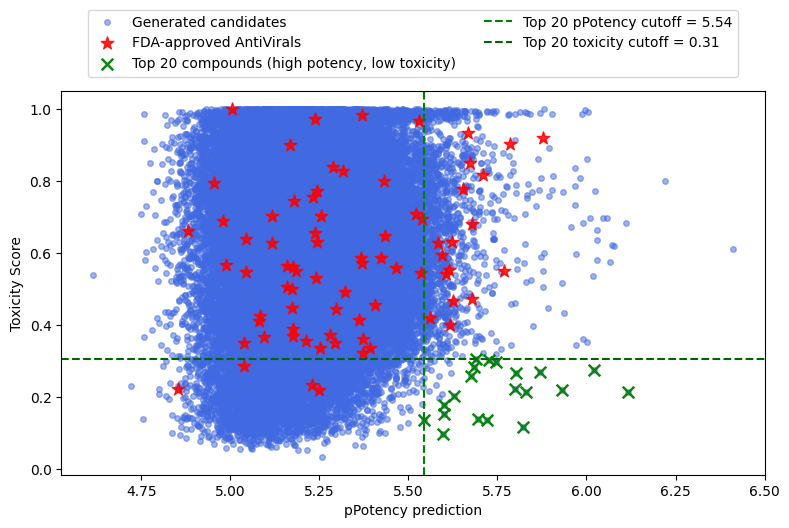

In [71]:
# Display cutoffs from the actual top 20 compounds
xDisplay = top20_2D_DF["pPotency_prediction"].min()
yDisplay = top20_2D_DF["coreToxicityScore"].max()

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    cand2DDF["pPotency_prediction"],
    cand2DDF["coreToxicityScore"],
    s=16, alpha=0.5, color="royalblue", label="Generated candidates"
)

ax.scatter(
    refScoreDF["pPotency_prediction"],
    refScoreDF["coreToxicityScore"],
    marker="*", s=90, alpha=0.85, color="red", label="FDA-approved AntiVirals"
)

ax.scatter(
    top20_2D_DF["pPotency_prediction"],
    top20_2D_DF["coreToxicityScore"],
    marker="x", s=70, linewidths=1.8, alpha=0.95, color="green",
    label="Top 20 compounds (high potency, low toxicity)"
)

ax.axvline(
    xDisplay,
    linestyle="--",
    linewidth=1.5,
    color="green",
    label=f"Top 20 pPotency cutoff = {xDisplay:.2f}"
)

ax.axhline(
    yDisplay,
    linestyle="--",
    linewidth=1.5,
    color="darkgreen",
    label=f"Top 20 toxicity cutoff = {yDisplay:.2f}"
)

ax.set_xlabel("pPotency prediction")
ax.set_ylabel("Toxicity Score")

ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=True)
plt.tight_layout(rect=[0, 0, 1, 0.90])

svg_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_buyable.svg")
png_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_buyable.png")

plt.savefig(svg_path, format="svg", dpi=600)
plt.savefig(png_path, format="png", dpi=600)
plt.show()

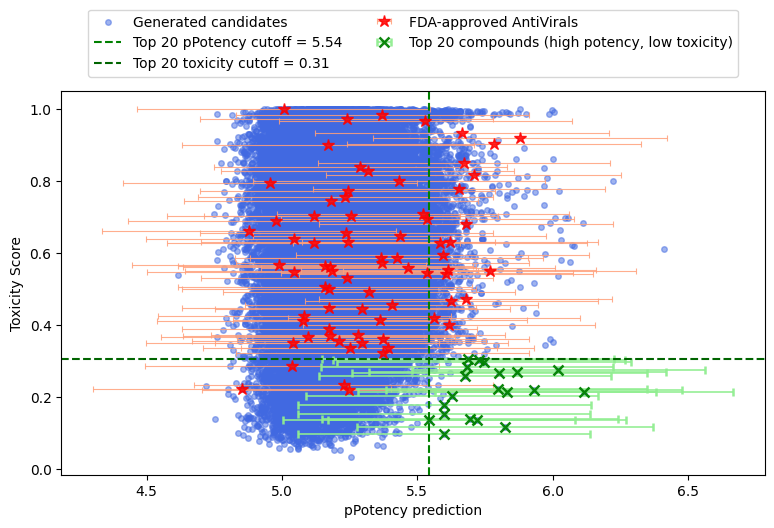

In [72]:
# Display cutoffs from the actual top 20 compounds
xDisplay = top20_2D_DF["pPotency_prediction"].min()
yDisplay = top20_2D_DF["coreToxicityScore"].max()

fig, ax = plt.subplots(figsize=(8, 6))

# ── Helper to compute asymmetric xerr ────────────────────────────────────────
'''
def get_xerr(df):
    return np.array([
        df["pPotency_prediction"] - df["pPotency_lower_95CI"],
        df["pPotency_upper_95CI"] - df["pPotency_prediction"],
    ])
'''

def get_xerr(df):
    return df["pPotency_std"].values  # symmetric → single array, not shape(2,N)


# ── Generated candidates ──────────────────────────────────────────────────────
ax.scatter(
    cand2DDF["pPotency_prediction"],
    cand2DDF["coreToxicityScore"],
    s=16, alpha=0.5, color="royalblue", label="Generated candidates"
)


# ── FDA-approved AntiVirals ───────────────────────────────────────────────────
ax.errorbar(
    refScoreDF["pPotency_prediction"],
    refScoreDF["coreToxicityScore"],
    xerr=get_xerr(refScoreDF),
    fmt="*", color="red", ecolor="lightsalmon",
    elinewidth=0.8, capsize=2, capthick=0.8,
    markersize=9, alpha=0.85, label="FDA-approved AntiVirals"
)

# ── Top 20 compounds ──────────────────────────────────────────────────────────
ax.errorbar(
    top20_2D_DF["pPotency_prediction"],
    top20_2D_DF["coreToxicityScore"],
    xerr=get_xerr(top20_2D_DF),
    fmt="x", color="green", ecolor="lightgreen",
    elinewidth=1.2, capsize=3, capthick=1.2,
    markersize=7, markeredgewidth=1.8,
    alpha=0.95, label="Top 20 compounds (high potency, low toxicity)"
)

ax.axvline(xDisplay, linestyle="--", linewidth=1.5, color="green",
           label=f"Top 20 pPotency cutoff = {xDisplay:.2f}")
ax.axhline(yDisplay, linestyle="--", linewidth=1.5, color="darkgreen",
           label=f"Top 20 toxicity cutoff = {yDisplay:.2f}")

ax.set_xlabel("pPotency prediction")
ax.set_ylabel("Toxicity Score")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=True)
plt.tight_layout(rect=[0, 0, 1, 0.90])

svg_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_DORAnetGenerated_Antivirals.svg")
png_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_DORAnetGenerated_Antivirals.png")
plt.savefig(svg_path, format="svg", dpi=600)
plt.savefig(png_path, format="png", dpi=600)
plt.show()

### 15. Plot: `high pPotency`, `low Toxicity Score`, `high ADME feasibility`

Selection rule:
- pPotency in the top quartile
- Toxicity Score in the bottom quartile
- ADMEFeasibility in the top quartile

Within that region, ranking uses the unweighted geometric mean of:
- `PotencyDesRaw`
- `ToxicitySafety`
- `ADMEFeasibility`

In [73]:
cand3DDF = candScoreDF.copy()

cand3DDF = cand3DDF[
    cand3DDF[["pPotency_prediction", "coreToxicityScore", "ADMEFeasibility", "ToxicitySafety", "PotencyDesRaw"]]
    .notna()
    .all(axis=1)
].copy()

xCutoff3D = cand3DDF["pPotency_prediction"].quantile(0.75)
yCutoff3D = cand3DDF["coreToxicityScore"].quantile(0.25)
zCutoff3D = cand3DDF["ADMEFeasibility"].quantile(0.75)

optimal3DDF = cand3DDF[
    (cand3DDF["pPotency_prediction"] >= xCutoff3D) &
    (cand3DDF["coreToxicityScore"] <= yCutoff3D) &
    (cand3DDF["ADMEFeasibility"] >= zCutoff3D)
].copy()

optimal3DDF["OverallPriority3D"] = (
    optimal3DDF["PotencyDesRaw"] *
    optimal3DDF["ToxicitySafety"] *
    optimal3DDF["ADMEFeasibility"]
) ** (1 / 3)

top20_3D_DF = optimal3DDF.sort_values(
    by=["OverallPriority3D", "pPotency_prediction", "coreToxicityScore", "ADMEFeasibility"],
    ascending=[False, False, True, False]
).head(20).copy()

top20_3D_DF["Top20Rank_3D"] = np.arange(1, len(top20_3D_DF) + 1)

top20_3D_DF[
    [
        "Top20Rank_3D",
        "SMILES",
        "pPotency_prediction",
        "pPotency_std",
        "pPotency_lower_95CI",
        "coreToxicityScore",
        "ADMEFeasibility",
        "ToxicitySafety",
        "OverallPriority3D",
        "QED",
    ]
]

,Top20Rank_3D,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,coreToxicityScore,ADMEFeasibility,ToxicitySafety,OverallPriority3D,QED
4494,1,CCC1(c2ccccc2)NC(=O)NC1=O,5.802353,0.545225,4.733711,0.267865,0.807699,0.732135,0.835610,0.709364
10478,2,COc1ccc(C2NC(=O)NC(C)=C2C(=O)OC(C)C)cc1OC,5.830609,0.549417,4.753751,0.214804,0.738309,0.785196,0.830097,0.807005
54580,3,COc1cccc(CC(=O)N2CCn3nnc(CCC(=O)N4CCCC4)c3C2)c1,5.627495,0.540206,4.568691,0.204176,0.780262,0.795824,0.817548,0.736629
664,4,CC(=O)NCC(=O)NCC1(c2ccncc2)CCCCC1,5.869404,0.547578,4.796152,0.270209,0.745556,0.729791,0.812736,0.863398
62079,5,Cc1c(C(=O)O)nnn1Cc1cccc(C(F)(F)F)c1,5.620942,0.541800,4.559014,0.268042,0.821575,0.731958,0.800604,0.939548
59030,6,COc1cccc(CN2C(=O)C3(CCOCC3)CC2c2nnnn2C(C)(C)C)...,5.498755,0.539894,4.440562,0.128749,0.812886,0.871251,0.798917,0.721557
32344,7,CC1=NN(C(=O)c2cccnc2)C(O)(c2cccnc2)C1,5.434135,0.544397,4.367117,0.100233,0.809207,0.899767,0.796240,0.905917
52651,8,COCCn1nnnc1C1CC2(CCOCC2)C(=O)N1CCc1ccc(OC)c(OC)c1,5.440766,0.539247,4.383842,0.140284,0.830636,0.859716,0.796147,0.574372
52652,9,COc1ccccc1OCCN1C(=O)C2(CCOCC2)CC1c1nnnn1C(C)(C)C,5.436684,0.540021,4.378242,0.165092,0.812896,0.834908,0.782761,0.696874
37391,10,COc1ccc(C(=O)N2CCn3c(C)nnc3C2)cc1OC,5.381866,0.541967,4.319611,0.109427,0.841186,0.890573,0.782673,0.853484


### 16. plot: pPotency vs Toxicity Score vs ADME feasibility

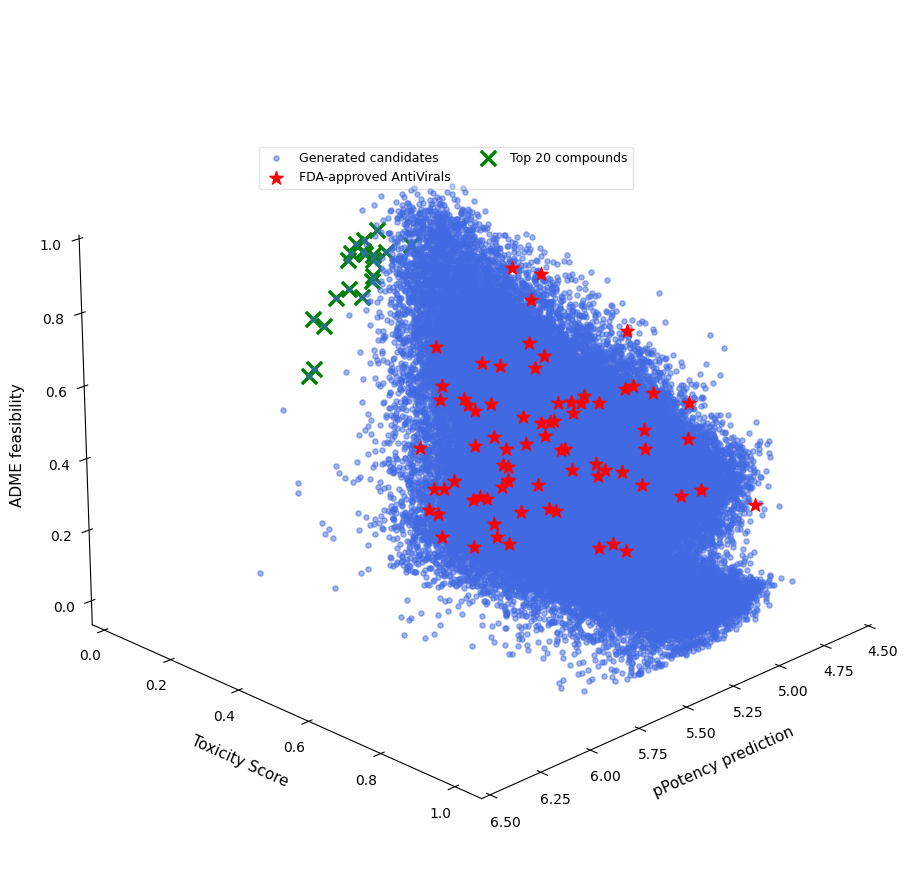

In [74]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(13, 10))
ax  = fig.add_subplot(111, projection="3d")

fig.patch.set_alpha(0.0)
ax.set_facecolor((0, 0, 0, 0))

for pane in [ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane]:
    pane.fill = False
    pane.set_edgecolor("lightgray")
    pane.set_alpha(0.0)

ax.grid(False)
for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis._axinfo["grid"]["linewidth"] = 0
    axis.label.set_color("k")
    axis.set_tick_params(colors="k")

ax.scatter(
    cand3DDF["pPotency_prediction"], cand3DDF["coreToxicityScore"], cand3DDF["ADMEFeasibility"],
    s=14, alpha=0.5, color="royalblue", label="Generated candidates", depthshade=False,
)
ax.scatter(
    refScoreDF["pPotency_prediction"], refScoreDF["coreToxicityScore"], refScoreDF["ADMEFeasibility"],
    marker="*", s=100, alpha=1.0, color="red", label="FDA-approved AntiVirals", depthshade=False,
)
ax.scatter(
    top20_3D_DF["pPotency_prediction"], top20_3D_DF["coreToxicityScore"], top20_3D_DF["ADMEFeasibility"],
    marker="x", s=120, linewidths=2.5, alpha=1.0, color="green", label="Top 20 compounds", depthshade=False,
)

xCutoff = top20_3D_DF["pPotency_prediction"].min()
yCutoff = top20_3D_DF["coreToxicityScore"].max()
zCutoff = top20_3D_DF["ADMEFeasibility"].min()

xMin, xMax = ax.get_xlim()
yMin, yMax = ax.get_ylim()
zMin, zMax = ax.get_zlim()

#cutoffStyle = dict(linewidth=1.8, linestyle="--", alpha=0.85)
#ax.plot([xMin,    xCutoff], [yCutoff, yCutoff], [zCutoff, zCutoff], color="green",     label=f"pPotency cutoff = {xCutoff:.2f}", **cutoffStyle)
#ax.plot([xCutoff, xCutoff], [yCutoff, yMax],    [zCutoff, zCutoff], color="darkolivegreen", label=f"Toxicity cutoff = {yCutoff:.2f}", **cutoffStyle)
#ax.plot([xCutoff, xCutoff], [yCutoff, yCutoff], [zMin,    zCutoff], color="seagreen",  label=f"ADME cutoff = {zCutoff:.2f}",    **cutoffStyle)
#ax.scatter([xCutoff], [yCutoff], [zCutoff], marker="D", s=180, color="gold", edgecolors="darkorange", linewidths=1.5, zorder=10, label="Optimal cutoff corner", depthshade=False)

ax.set_xlabel("pPotency prediction", labelpad=10, color="k", fontsize=11)
ax.set_ylabel("Toxicity Score", labelpad=10, color="k", fontsize=11)
ax.set_zlabel("ADME feasibility",    labelpad=10, color="k", fontsize=11)
ax.set_zlabel("")
ax.text2D(-0.02, 0.5, "ADME feasibility", transform=ax.transAxes, fontsize=11, color="k", rotation=90, va="center", ha="center")

for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis.set_tick_params(colors="k", labelsize=10)

ax.view_init(elev=22, azim=45)
ax.legend(loc="upper left", bbox_to_anchor=(0.25, 0.85), ncol=2, frameon=True, framealpha=0.3, facecolor="white", edgecolor="darkgray", labelcolor="black", fontsize=9)
fig.subplots_adjust(left=0.05, right=0.95, top=0.92, bottom=0.05)

svg_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_adme_3d_buyable.svg")
png_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_adme_3d_buyable.png")
plt.savefig(svg_path, format="svg", dpi=600, transparent=True, pad_inches=0.5)
plt.savefig(png_path, format="png", dpi=600, transparent=True, pad_inches=0.5)
plt.show()

### 17. Custom projected 3D plot for presentation

This is a presentation-oriented 2D projection of 3 variables.

Projected axes:
- horizontal right = `pPotency`
- vertical up = `Toxicity Score`
- diagonal lower-left = `ADME feasibility`

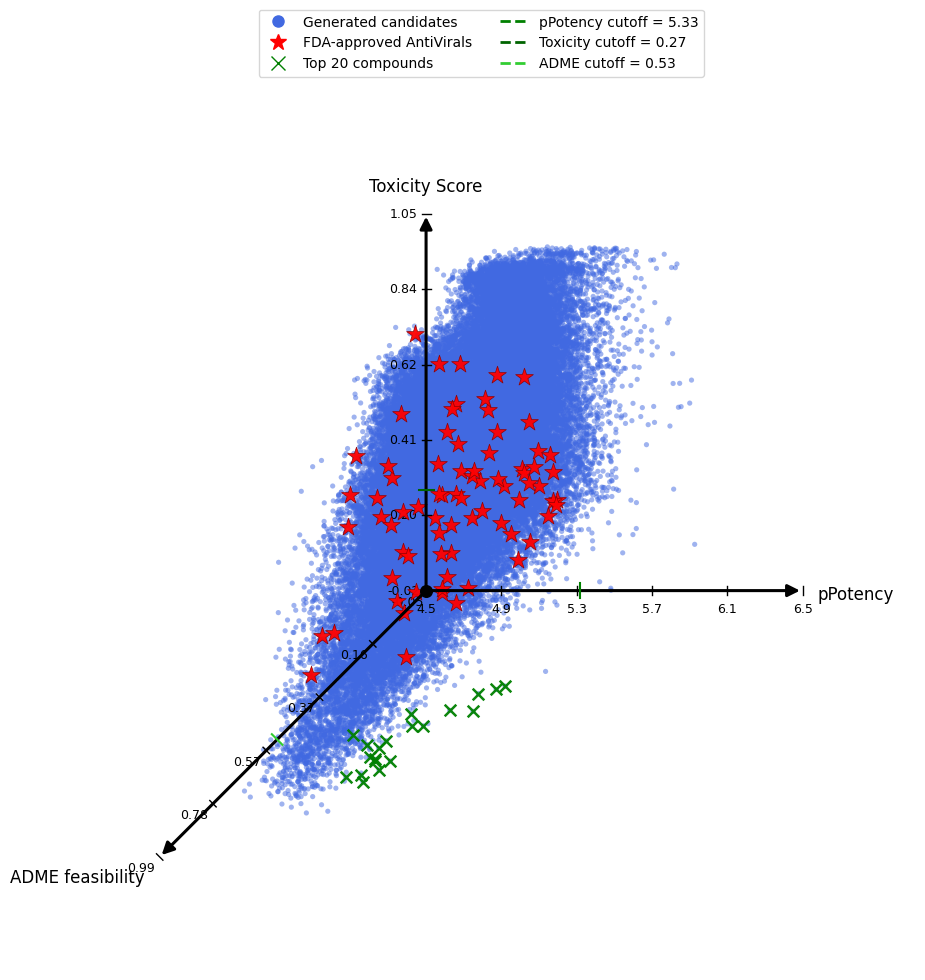

In [75]:
xCol, yCol, zCol = "pPotency_prediction", "coreToxicityScore", "ADMEFeasibility"
cols = [xCol, yCol, zCol]

allPlotDF = cand3DDF[cols][np.isfinite(cand3DDF[cols]).all(axis=1)].copy()
refPlotDF = refScoreDF[cols][np.isfinite(refScoreDF[cols]).all(axis=1)].copy()
topPlotDF = top20_3D_DF[cols][np.isfinite(top20_3D_DF[cols]).all(axis=1)].copy()

def paddedRange(arr, frac=0.05):
    lo, hi = np.nanmin(arr), np.nanmax(arr)
    pad = (hi - lo) * frac if (hi - lo) > 0 else 1.0
    return lo - pad, hi + pad

combined          = pd.concat([allPlotDF, refPlotDF, topPlotDF])
(X_MIN, X_MAX), (Y_MIN, Y_MAX), (Z_MIN, Z_MAX) = [paddedRange(combined[c]) for c in cols]

O  = np.zeros(2)
UX = np.array([1.0, 0.0])
UY = np.array([0.0, 1.0])
UZ = np.array([math.cos(math.radians(225)), math.sin(math.radians(225))])

def project(x, y, z):
    return O + ((x-X_MIN)/(X_MAX-X_MIN))*UX + ((y-Y_MIN)/(Y_MAX-Y_MIN))*UY + ((z-Z_MIN)/(Z_MAX-Z_MIN))*UZ

def projectDF(df):
    pts = np.array([project(r[xCol], r[yCol], r[zCol]) for _, r in df.iterrows()])
    return pts[:, 0], pts[:, 1]

allCX, allCY = projectDF(allPlotDF)
refCX, refCY = projectDF(refPlotDF)
topCX, topCY = projectDF(topPlotDF)

TIP_X, TIP_Y, TIP_Z = O + UX, O + UY, O + UZ

fig, ax = plt.subplots(figsize=(12, 11), facecolor="white")
ax.set(facecolor="white", aspect="equal")
ax.axis("off")

for tip in [TIP_X, TIP_Y, TIP_Z]:
    ax.annotate("", xy=tip, xytext=O, zorder=5,
                arrowprops=dict(arrowstyle="-|>", color="black", lw=2.2, mutation_scale=18))

ax.scatter(*O, s=70, c="black", zorder=6)

def drawTicks(unitVec, valMin, valMax, offset, nTicks=5, fmt="{:.2f}"):
    perp = np.array([unitVec[1], -unitVec[0]])
    perp /= np.linalg.norm(perp)
    for i in range(nTicks + 1):
        t, pos = i / nTicks, O + (i / nTicks) * unitVec
        ax.plot(*zip(pos - 0.012*perp, pos + 0.012*perp), color="black", lw=1.0, zorder=5)
        ax.text(*(pos + offset), fmt.format(valMin + t*(valMax-valMin)), fontsize=9, ha="center", va="center")

drawTicks(UX, X_MIN, X_MAX, np.array([ 0.00, -0.05]), fmt="{:.1f}")
drawTicks(UY, Y_MIN, Y_MAX, np.array([-0.06,  0.00]))
drawTicks(UZ, Z_MIN, Z_MAX, np.array([-0.05, -0.03]))

ax.scatter(allCX, allCY, color="royalblue", s=14,  alpha=0.5,  edgecolors="none", zorder=2)
ax.scatter(refCX, refCY, color="red",       s=180, alpha=0.95, marker="*", edgecolors="darkred", linewidths=0.5, zorder=4)
ax.scatter(topCX, topCY, color="green",     s=70,  alpha=0.95, marker="x", linewidths=1.8, zorder=5)

xCut, yCut, zCut = topPlotDF[xCol].min(), topPlotDF[yCol].max(), topPlotDF[zCol].min()
tickLen = 0.02

UZ_perp = np.array([-UZ[1], UZ[0]]) 
UZ_perp /= np.linalg.norm(UZ_perp)           
zPt = O + ((zCut-Z_MIN)/(Z_MAX-Z_MIN))*UZ 

for pt, color, dx, dy in [
    (O + ((xCut-X_MIN)/(X_MAX-X_MIN))*UX, "green", 0, tickLen),
    (O + ((yCut-Y_MIN)/(Y_MAX-Y_MIN))*UY, "darkgreen",  tickLen, 0),
]:
    ax.plot([pt[0]-dx, pt[0]+dx], [pt[1]-dy, pt[1]+dy], color=color, lw=1.5, zorder=5)

# Z cutoff tick perpendicular to UZ
ax.plot(
    [zPt[0] - tickLen*UZ_perp[0], zPt[0] + tickLen*UZ_perp[0]],
    [zPt[1] - tickLen*UZ_perp[1], zPt[1] + tickLen*UZ_perp[1]],
    color="limegreen", lw=1.5, zorder=5
)

ax.text(TIP_X[0]+0.04, TIP_X[1]-0.01, "pPotency",            fontsize=12, ha="left",   va="center")
ax.text(TIP_Y[0],      TIP_Y[1]+0.05, "Toxicity Score",  fontsize=12, ha="center", va="bottom")
ax.text(TIP_Z[0]-0.04, TIP_Z[1]-0.03, "ADME feasibility",    fontsize=12, ha="right",  va="top")

allPx = np.concatenate([allCX, refCX, topCX, [TIP_X[0], TIP_Y[0], TIP_Z[0]]])
allPy = np.concatenate([allCY, refCY, topCY, [TIP_X[1], TIP_Y[1], TIP_Z[1]]])
ax.set_xlim(allPx.min()-0.3, allPx.max()+0.3)
ax.set_ylim(allPy.min()-0.3, allPy.max()+0.3)

handles = [
    mlines.Line2D([], [], color="royalblue", marker="o", linestyle="None", markersize=8, label="Generated candidates"),
    mlines.Line2D([], [], color="red",       marker="*", linestyle="None", markersize=12, label="FDA-approved AntiVirals"),
    mlines.Line2D([], [], color="green",     marker="x", linestyle="None", markersize=10, label="Top 20 compounds"),
    mlines.Line2D([], [], color="green",     linestyle="--", lw=2, label=f"pPotency cutoff = {xCut:.2f}"),
    mlines.Line2D([], [], color="darkgreen", linestyle="--", lw=2, label=f"Toxicity cutoff = {yCut:.2f}"),
    mlines.Line2D([], [], color="limegreen", linestyle="--", lw=2, label=f"ADME cutoff = {zCut:.2f}"),
]
ax.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig(os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_adme_buyable.svg"), format="svg", dpi=600, bbox_inches="tight", facecolor="white")
plt.savefig(os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_adme_buyable.png"), format="png", dpi=600, bbox_inches="tight", facecolor="white")
plt.show()

### 18. Save the top 20 candidates

In [76]:
top20_2D_cols = ["Top20Rank_2D", "SMILES", "pPotency_prediction", "pPotency_std", "pPotency_lower_95CI", "pPotency_upper_95CI", "coreToxicityScore", "ToxicitySafety", "OverallPriority2D", "QED"]
top20_3D_cols = ["Top20Rank_3D", "SMILES", "pPotency_prediction", "pPotency_std", "pPotency_lower_95CI", "pPotency_upper_95CI", "coreToxicityScore", "ADMEFeasibility", "ToxicitySafety", "OverallPriority3D", "QED"]

toxicityTop20Path = os.path.join(saveDir, f"{target_organism}_potency_coreToxicity_top20_buyable.csv")
admetTop20Path    = os.path.join(saveDir, f"{target_organism}_potency_coreToxicity_adme_top20_buyable.csv")

top20_2D_DF[top20_2D_cols[1:]].to_csv(toxicityTop20Path, index=False)
top20_3D_DF[top20_3D_cols[1:]].to_csv(admetTop20Path,    index=False)

print(f"Saved:\n- {toxicityTop20Path}\n- {admetTop20Path}")

#display(top20_2D_DF[top20_2D_cols])
#display(top20_3D_DF[top20_3D_cols])

Saved:
- /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB/combinedEbolaVirus_potency_coreToxicity_top20_buyable.csv
- /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB/combinedEbolaVirus_potency_coreToxicity_adme_top20_buyable.csv


# Check ADMET properties for `DORAnet` generated AntiVirals
- Starter - `Inosine + Adenosine + Guanosine + Xanthosine`

### 1. Read `ART` predicted `pPotency` of all the compounds

In [77]:
Ebola_wART_DORAnetGenerated_Antivirals_predicted_all = pd.read_csv(saveDir + 'Ebola_allDORAnetGenerated_Antivirals_ARTprediction.csv')
max_val = Ebola_wART_DORAnetGenerated_Antivirals_predicted_all['pPotency_prediction'].max()
min_val = Ebola_wART_DORAnetGenerated_Antivirals_predicted_all['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
Ebola_wART_DORAnetGenerated_Antivirals_predicted_all

pPotency_prediction range: 4.470 → 5.649


,SMILES,Is_Starter,SourceDirectories,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,True,InosineOnly_gen3,5.459329,0.540618,4.399719,6.518939,0.000003,3.027338e-07,0.000040
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,InosineOnly_gen3,5.336136,0.541734,4.274338,6.397935,0.000005,4.000046e-07,0.000053
2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,InosineOnly_gen3,5.260644,0.540668,4.200935,6.320352,0.000005,4.782418e-07,0.000063
3,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,InosineOnly_gen3,5.447737,0.540431,4.388491,6.506983,0.000004,3.111842e-07,0.000041
4,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,InosineOnly_gen3,5.460962,0.540024,4.402515,6.519408,0.000003,3.024068e-07,0.000040
...,...,...,...,...,...,...,...,...,...,...
20367,NC(O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c32...,False,XanthosineOnly_gen3,5.255267,0.543298,4.190404,6.320131,0.000006,4.784854e-07,0.000065
20368,NC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c3...,False,XanthosineOnly_gen3,5.260999,0.542954,4.196810,6.325188,0.000005,4.729461e-07,0.000064
20369,NC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c3...,False,XanthosineOnly_gen3,5.269796,0.541144,4.209154,6.330439,0.000005,4.672626e-07,0.000062
20370,CNC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c...,False,XanthosineOnly_gen3,5.209218,0.543006,4.144925,6.273511,0.000006,5.327083e-07,0.000072


In [78]:
print(f"Filtered shape: {Ebola_wART_DORAnetGenerated_Antivirals_predicted_all.shape}")

Filtered shape: (20372, 10)


### plot `pPotency` distribution with error bars

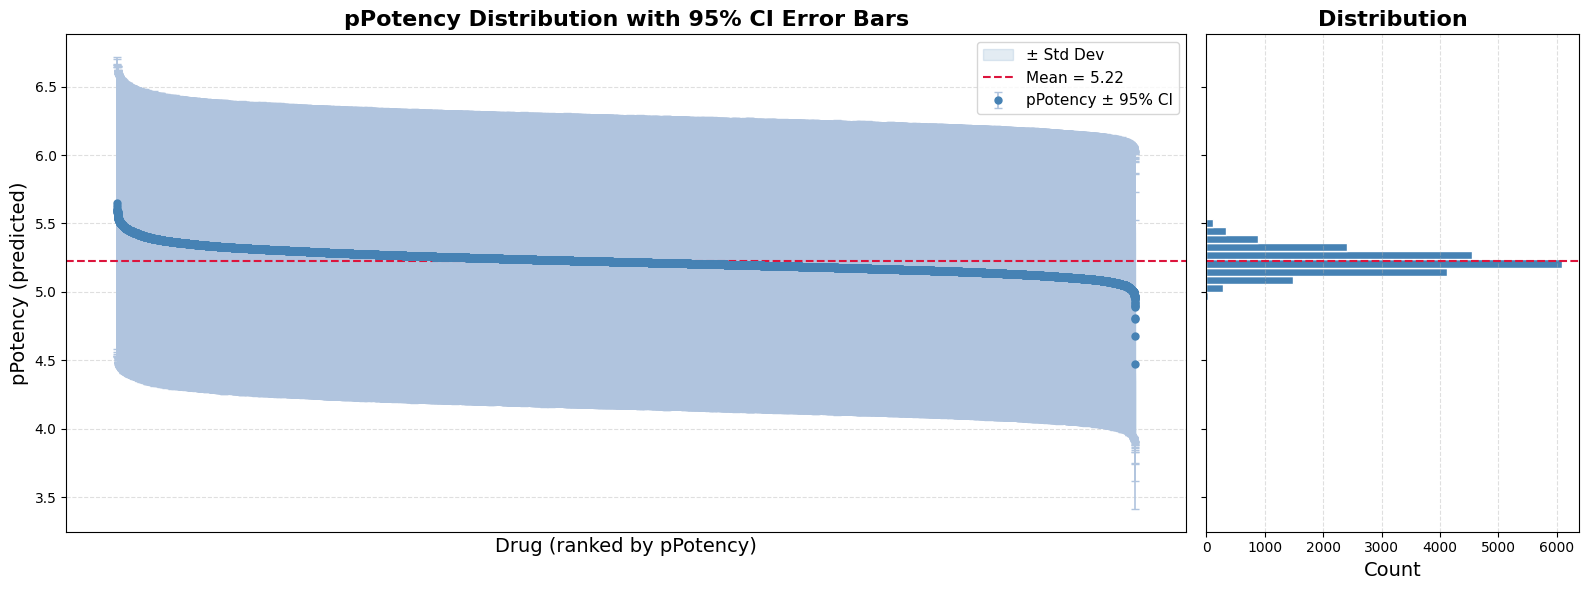

In [79]:
ppotencyDF = Ebola_wART_DORAnetGenerated_Antivirals_predicted_all.sort_values(
    "pPotency_prediction", ascending=False).reset_index(drop=True)

x = np.arange(len(ppotencyDF))
pred = ppotencyDF["pPotency_prediction"]
yerr = np.array([pred - ppotencyDF["pPotency_lower_95CI"],
                 ppotencyDF["pPotency_upper_95CI"] - pred])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6),
                                gridspec_kw={"width_ratios": [3, 1]}, sharey=True)

# ── Scatter + error bars ──────────────────────────────────────────────────────
ax1.errorbar(x, pred, yerr=yerr, fmt='o', color='steelblue', ecolor='lightsteelblue',
             elinewidth=1.2, capsize=3, markersize=5, alpha=1, label="pPotency ± 95% CI")
ax1.fill_between(x, pred - ppotencyDF["pPotency_std"], pred + ppotencyDF["pPotency_std"],
                 alpha=0.15, color='steelblue', label="± Std Dev")
ax1.axhline(pred.mean(),   color='crimson',    linestyle='--', linewidth=1.5, label=f'Mean = {pred.mean():.2f}')
#ax1.axhline(pred.median(), color='darkorange', linestyle=':',  linewidth=1.5, label=f'Median = {pred.median():.2f}')
ax1.set_xlabel("Drug (ranked by pPotency)", fontsize=14)  
ax1.set_ylabel("pPotency (predicted)",      fontsize=14) 
ax1.set_title("pPotency Distribution with 95% CI Error Bars", fontsize=16, fontweight='bold')  
ax1.set_xticks([])
ax1.legend(fontsize=11); ax1.grid(axis='y', linestyle='--', alpha=0.4)

# ── Histogram ─────────────────────────────────────────────────────────────────
ax2.hist(pred, bins=20, orientation='horizontal', color='steelblue', edgecolor='white', alpha=1)
ax2.axhline(pred.mean(),   color='crimson',    linestyle='--', linewidth=1.5)
#ax2.axhline(pred.median(), color='darkorange', linestyle=':',  linewidth=1.5)
ax2.set_xlabel("Count", fontsize=14)        
ax2.set_title("Distribution", fontsize=16, fontweight='bold') 
ax2.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
svg_path = os.path.join(saveDir, f"{target_organism}_pPotency_distribution_DORAnetGenerated_Antivirals.svg")
png_path = os.path.join(saveDir, f"{target_organism}_pPotency_distribution_DORAnetGenerated_Antivirals.png")
plt.savefig(svg_path, format="svg", dpi=600)
plt.savefig(png_path, format="png", dpi=600)
plt.show()

### Read predicted `ADMET` properties for all candidate SMILES

In [80]:
Ebola_wART_DORAnetGenerated_AntiviralsDataset_predicted_all_wToxicity = pd.read_csv(saveDir + 'Ebola_allDORAnetGenerated_Antivirals_ARTprediction_wToxicity.csv')

# Drop columns containing 'drugbank_approved_percentile'
matched_cols = Ebola_wART_DORAnetGenerated_AntiviralsDataset_predicted_all_wToxicity.filter(like='drugbank_approved_percentile').columns
Ebola_wART_DORAnetGenerated_AntiviralsDataset_predicted_all_wToxicity = \
    Ebola_wART_DORAnetGenerated_AntiviralsDataset_predicted_all_wToxicity.drop(columns=matched_cols)

# Canonicalize SMILES
def canon_smiles(s):
    m = Chem.MolFromSmiles(str(s))
    return Chem.MolToSmiles(m) if m else None

smiles_col = "SMILES" if "SMILES" in Ebola_wART_DORAnetGenerated_AntiviralsDataset_predicted_all_wToxicity.columns else "smiles"
Ebola_wART_DORAnetGenerated_AntiviralsDataset_predicted_all_wToxicity[smiles_col] = \
    Ebola_wART_DORAnetGenerated_AntiviralsDataset_predicted_all_wToxicity[smiles_col].apply(canon_smiles)

max_val = Ebola_wART_DORAnetGenerated_AntiviralsDataset_predicted_all_wToxicity['pPotency_prediction'].max()
min_val = Ebola_wART_DORAnetGenerated_AntiviralsDataset_predicted_all_wToxicity['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")

Ebola_wART_DORAnetGenerated_AntiviralsDataset_predicted_all_wToxicity

pPotency_prediction range: 4.470 → 5.649


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,molecular_weight,logP,...,Caco2_Wang,Clearance_Hepatocyte_AZ,Clearance_Microsome_AZ,Half_Life_Obach,HydrationFreeEnergy_FreeSolv,LD50_Zhu,Lipophilicity_AstraZeneca,PPBR_AZ,Solubility_AqSolDB,VDss_Lombardo
0,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,5.459329,0.540618,4.399719,6.518939,0.000003,3.027338e-07,0.000040,268.229,-2.26890,...,-5.835234,28.025204,-17.188645,4.934540,-24.011630,2.159634,-1.774638,31.001650,-1.080324,-1.642514
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,5.336136,0.541734,4.274338,6.397935,0.000005,4.000046e-07,0.000053,507.182,-1.62900,...,-6.532908,10.607536,21.695647,50.300162,-17.205968,1.654107,0.655960,57.025779,-0.437743,-4.687410
2,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,5.447737,0.540431,4.388491,6.506983,0.000004,3.111842e-07,0.000041,785.557,-2.42396,...,-6.475772,-3.364867,23.998967,23.188328,-17.767413,2.572223,0.824762,72.098404,-1.021829,-8.492948
3,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,5.460962,0.540024,4.402515,6.519408,0.000003,3.024068e-07,0.000040,787.573,-1.75026,...,-6.679487,1.394358,30.020669,41.759685,-18.648854,2.694055,1.037456,70.919499,-0.882326,-5.521714
4,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,5.346715,0.540573,4.287192,6.406237,0.000005,3.924304e-07,0.000052,744.417,-2.89890,...,-6.818474,5.750305,18.362396,75.728975,-19.110544,1.835266,0.205004,52.787176,0.022007,-3.040320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7312,N#CC(O)(O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[n...,5.311236,0.542423,4.248086,6.374385,0.000005,4.222944e-07,0.000056,350.247,-3.86964,...,-5.955260,-8.761916,-26.770016,14.103317,-22.354659,3.105875,-1.044692,56.499127,-1.956776,2.486373
7313,N#CC(O)(O)[C@H]1O[C@](C#N)(n2cnc3c(=O)[nH]c(=O...,5.157317,0.542338,4.094336,6.220299,0.000007,6.021448e-07,0.000080,350.247,-4.08564,...,-5.818521,-13.439529,-30.363843,23.556845,-21.883500,3.207771,-1.054912,57.989126,-2.152616,-1.152304
7314,N#Cc1nc2c(=O)[nH]c(=O)[nH]c2n1[C@@H]1O[C@H](C(...,5.297589,0.541998,4.235274,6.359904,0.000005,4.366119e-07,0.000058,350.247,-3.89174,...,-5.849040,-4.257238,-21.835345,18.294608,-21.778549,3.044578,-0.985986,57.468950,-2.193930,-0.049402
7315,O=C1NC2=NC(=O)[C@H]3O[C@H]([C@H](O)[C@@H]3O)n3...,5.303743,0.541890,4.241639,6.365846,0.000005,4.306792e-07,0.000057,279.212,-2.07580,...,-5.684864,-9.842546,-16.313448,76.343168,-23.489791,2.280219,-1.492284,34.876469,-2.238372,-4.511073


### Export compounds need to be highlighted

In [81]:
Inosine_SMILES = 'C1=NC2=C(C(=O)N1)N=CN2[C@H]3[C@@H]([C@@H]([C@H](O3)CO)O)O'
Adenosine_SMILES = 'C1=NC(=C2C(=N1)N(C=N2)[C@H]3[C@@H]([C@@H]([C@H](O3)CO)O)O)N'
Guanosine_SMILES = 'C1=NC2=C(N1[C@H]3[C@@H]([C@@H]([C@H](O3)CO)O)O)N=C(NC2=O)N'
Xanthosine_SMILES = 'C1=NC2=C(N1[C@H]3[C@@H]([C@@H]([C@H](O3)CO)O)O)NC(=O)NC2=O'

query_smiles = {
    "Inosine": Inosine_SMILES,
    "Adenosine": Adenosine_SMILES,
    "Guanosine": Guanosine_SMILES,
    "Xanthosine": Xanthosine_SMILES
}
query_canon = {k: canon_smiles(v) for k, v in query_smiles.items()}

smiles_col = "SMILES" if "SMILES" in Ebola_wART_DORAnetGenerated_Antivirals_predicted_all.columns else "smiles"

df = Ebola_wART_DORAnetGenerated_Antivirals_predicted_all.copy()
df[smiles_col] = df[smiles_col].apply(canon_smiles)

queryDF = df[df[smiles_col].isin(set(query_canon.values()))].copy()

# add drugName from canonical SMILES
name_map = {v: k for k, v in query_canon.items()}
queryDF["drugName"] = queryDF[smiles_col].map(name_map)

# place drugName just left of SMILES column
cols = queryDF.columns.tolist()
cols.insert(cols.index(smiles_col), cols.pop(cols.index("drugName")))
queryDF = queryDF[cols]

print("Matched queries:", queryDF["drugName"].dropna().unique().tolist())
queryDF

Matched queries: ['Inosine', 'Adenosine', 'Guanosine', 'Xanthosine']


,drugName,SMILES,Is_Starter,SourceDirectories,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,Inosine,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,True,InosineOnly_gen3,5.459329,0.540618,4.399719,6.518939,0.000003,3.027338e-07,0.000040
4727,Adenosine,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,True,AdenosineOnly_gen3,5.536453,0.540180,4.477700,6.595206,0.000003,2.539768e-07,0.000033
9956,Guanosine,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,True,GuanosineOnly_gen3,5.354144,0.540868,4.294042,6.414245,0.000004,3.852609e-07,0.000051
16072,Xanthosine,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,True,XanthosineOnly_gen3,5.262729,0.541633,4.201129,6.324330,0.000005,4.738815e-07,0.000063


In [82]:
querySmilesDict = {
    "Remdesivir": "CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](C#N)([C@H](O)[C@@H]1O)C1=CC=C2N1N=CN=C2N)OC1=CC=CC=C1",
    "Favipiravir": "C1=C(N=C(C(=O)N1)C(=O)N)F",
    "Brincidofovir": "CCCCCCCCCCCCCCCCOCCCOP(=O)(CO[C@@H](CN1C=CC(=NC1=O)N)CO)O",
}

queryPotencyDict = {
    "Remdesivir": [
        7.07,  # Warren et al. 2016, EBOV, primary macrophages
        6.85,  # Warren et al. 2016, EBOV, HeLa
        6.89,  # Warren et al. 2016, EBOV, HFF-1
        7.22,  # Warren et al. 2016, EBOV, HMVEC-TERT
        7.15,  # Warren et al. 2016, EBOV, Huh-7
        7.18,  # Lo et al. 2017, EBOV Mayinga-GFP reporter assay
        7.68,  # Lo et al. 2017, EBOV Mayinga-Gluc reporter assay
        7.85,  # Lo et al. 2017, EBOV Makona-ZSG reporter assay
        8.52,  # Lo et al. 2017, EBOV Makona virus titer reduction assay
        7.11,  # Radoshitzky et al. 2023, EBOV Makona, HeLa
        6.87,  # Radoshitzky et al. 2023, EBOV Mayinga, HeLa
        7.15,  # Radoshitzky et al. 2023, EBOV Kikwit, HeLa
    ],
    "Favipiravir": [4.17, 3.96],
    "Brincidofovir": [6.10, 6.18, 6.06],
}

def canonicalizeSmiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return Chem.MolToSmiles(mol, canonical=True, isomericSmiles=True) if mol else None

queryData = []
for drugName, smiles in querySmilesDict.items():
    potencyValues = pd.Series(queryPotencyDict[drugName], dtype="float64")
    queryData.append({
        "drugName": drugName,
        "SMILES": canonicalizeSmiles(smiles),
        "pPotency_min": potencyValues.min(),
        "pPotency_max": potencyValues.max(),
        "meanpPotency": potencyValues.mean(),
        "potency_std": potencyValues.std(ddof=1),  # standard deviation
    })

queryDF_FDA = pd.DataFrame(queryData)
queryDF_FDA = queryDF_FDA.rename (columns={'meanpPotency' :'pPotency_prediction', 'potency_std' : 'pPotency_std'})
queryDF_FDA

,drugName,SMILES,pPotency_min,pPotency_max,pPotency_prediction,pPotency_std
0,Remdesivir,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,6.85,8.52,7.295000,0.490389
1,Favipiravir,NC(=O)c1nc(F)c[nH]c1=O,3.96,4.17,4.065000,0.148492
2,Brincidofovir,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,6.06,6.18,6.113333,0.061101


In [83]:
queryDF_FDA = queryDF_FDA.drop(columns=["pPotency_min", "pPotency_max"])
queryDF_FDA

,drugName,SMILES,pPotency_prediction,pPotency_std
0,Remdesivir,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,7.295000,0.490389
1,Favipiravir,NC(=O)c1nc(F)c[nH]c1=O,4.065000,0.148492
2,Brincidofovir,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,6.113333,0.061101


In [84]:
combinedQueryDF = pd.concat([queryDF, queryDF_FDA], ignore_index=True)
combinedQueryDF = combinedQueryDF.drop_duplicates(subset=["SMILES"]).reset_index(drop=True)

combinedQueryDF = combinedQueryDF[[
    'drugName', 'SMILES', 'pPotency_prediction', 'pPotency_std',
    'pPotency_lower_95CI', 'pPotency_upper_95CI', 'IC50(M)_prediction',
    'IC50(M)_lower_95CI', 'IC50(M)_upper_95CI'
]]
combinedQueryDF

,drugName,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,Inosine,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,5.459329,0.540618,4.399719,6.518939,0.000003,3.027338e-07,0.000040
1,Adenosine,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,5.536453,0.540180,4.477700,6.595206,0.000003,2.539768e-07,0.000033
2,Guanosine,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,5.354144,0.540868,4.294042,6.414245,0.000004,3.852609e-07,0.000051
3,Xanthosine,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,5.262729,0.541633,4.201129,6.324330,0.000005,4.738815e-07,0.000063
4,Remdesivir,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,7.295000,0.490389,NaN,NaN,NaN,NaN,NaN
5,Favipiravir,NC(=O)c1nc(F)c[nH]c1=O,4.065000,0.148492,NaN,NaN,NaN,NaN,NaN
6,Brincidofovir,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,6.113333,0.061101,NaN,NaN,NaN,NaN,NaN


### Compute their ADMET profile

In [85]:
model = ADMETModel()
pred = model.predict(smiles=combinedQueryDF["SMILES"].dropna().astype(str).tolist())
pred = pred if isinstance(pred, pd.DataFrame) else pd.DataFrame(pred)
pred = pred.reset_index().rename(columns={"index": "SMILES"}) if "SMILES" not in pred.columns else pred
combinedQueryDF_wADMET = combinedQueryDF.merge(pred, on="SMILES", how="left")
combinedQueryDF_wADMET

Loading pretrained parameter "encoder.encoder.0.cached_zero_vector".
Loading pretrained parameter "encoder.encoder.0.W_i.weight".
Loading pretrained parameter "encoder.encoder.0.W_h.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.bias".
Loading pretrained parameter "readout.1.weight".
Loading pretrained parameter "readout.1.bias".
Loading pretrained parameter "readout.4.weight".
Loading pretrained parameter "readout.4.bias".
Loading pretrained parameter "encoder.encoder.0.cached_zero_vector".
Loading pretrained parameter "encoder.encoder.0.W_i.weight".
Loading pretrained parameter "encoder.encoder.0.W_h.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.bias".
Loading pretrained parameter "readout.1.weight".
Loading pretrained parameter "readout.1.bias".
Loading pretrained parameter "readout.4.weight".
Loading pretrained parameter "readout.4.b

,drugName,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,molecular_weight,...,Caco2_Wang_drugbank_approved_percentile,Clearance_Hepatocyte_AZ_drugbank_approved_percentile,Clearance_Microsome_AZ_drugbank_approved_percentile,Half_Life_Obach_drugbank_approved_percentile,HydrationFreeEnergy_FreeSolv_drugbank_approved_percentile,LD50_Zhu_drugbank_approved_percentile,Lipophilicity_AstraZeneca_drugbank_approved_percentile,PPBR_AZ_drugbank_approved_percentile,Solubility_AqSolDB_drugbank_approved_percentile,VDss_Lombardo_drugbank_approved_percentile
0,Inosine,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,5.459329,0.540618,4.399719,6.518939,0.000003,3.027338e-07,0.000040,268.229,...,14.967041,41.954246,10.856921,46.413339,0.038775,28.034122,6.475378,9.965103,82.241179,24.156650
1,Adenosine,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,5.536453,0.540180,4.477700,6.595206,0.000003,2.539768e-07,0.000033,267.245,...,12.873207,20.162854,26.521908,46.335789,1.357115,25.087243,13.609926,7.405971,78.092284,14.385421
2,Guanosine,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,5.354144,0.540868,4.294042,6.414245,0.000004,3.852609e-07,0.000051,283.244,...,8.103916,38.658395,12.330361,20.317953,0.038775,32.609539,8.103916,9.189608,72.043428,26.715781
3,Xanthosine,O=c1[nH]c(=O)c2ncn([C@@H]3O[C@H](CO)[C@@H](O)[...,5.262729,0.541633,4.201129,6.324330,0.000005,4.738815e-07,0.000063,284.228,...,14.928267,29.507561,4.963164,57.270260,0.038775,22.295463,4.924389,11.632416,78.014734,11.322218
4,Remdesivir,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,7.295000,0.490389,NaN,NaN,NaN,NaN,NaN,602.585,...,15.005816,77.626987,98.293912,68.165956,26.599457,96.393951,73.206669,73.167895,27.452501,86.777821
5,Favipiravir,NC(=O)c1nc(F)c[nH]c1=O,4.065000,0.148492,NaN,NaN,NaN,NaN,NaN,157.104,...,67.778209,29.778984,39.278790,4.148895,4.148895,74.757658,31.795269,29.119814,79.216751,15.975184
6,Brincidofovir,CCCCCCCCCCCCCCCCOCCCOP(=O)(O)CO[C@H](CO)Cn1ccc...,6.113333,0.061101,NaN,NaN,NaN,NaN,NaN,561.701,...,30.903451,78.945328,91.779760,91.934858,55.021326,53.315238,84.877860,82.357503,16.324157,89.104304


In [86]:
# ------------------------------------------------------------
# 1. Input data
# ------------------------------------------------------------
refDrugbankDF = drugBankDrug_FDAapproved_AntiViral_wART_wADMET.copy()
generatedCandidateDF = Ebola_wART_DORAnetGenerated_AntiviralsDataset_predicted_all_wToxicity.copy()
queryCandidateDF = combinedQueryDF_wADMET.copy()

print("Drugbank reference dataframe shape:", refDrugbankDF.shape)
print("Generated candidate dataframe shape:", generatedCandidateDF.shape)
print("Combined query dataframe shape:", queryCandidateDF.shape)

# ------------------------------------------------------------
# 2. Basic harmonization
# ------------------------------------------------------------
def prepareDF(DF, datasetLabel):
    DF = DF.copy()

    if "smiles" in DF.columns and "SMILES" not in DF.columns:
        DF = DF.rename(columns={"smiles": "SMILES"})

    if "drugName" not in DF.columns:
        DF["drugName"] = DF["SMILES"]

    DF["datasetLabel"] = datasetLabel
    return DF

refDrugbankDF = prepareDF(refDrugbankDF, "Reference")
generatedCandidateDF = prepareDF(generatedCandidateDF, "Generated")
queryCandidateDF = prepareDF(queryCandidateDF, "Query")

# ------------------------------------------------------------
# 3. Keep only the columns needed for pPotency–toxicity scoring
# ------------------------------------------------------------
potencyCols = [
    "pPotency_prediction",
    "pPotency_std",
    "pPotency_lower_95CI",
    "pPotency_upper_95CI",
]

toxicityMeta = [
    ("AMES", "lowerBetter"),
    ("Carcinogens_Lagunin", "lowerBetter"),
    ("ClinTox", "lowerBetter"),
    ("DILI", "lowerBetter"),
    ("Skin_Reaction", "lowerBetter"),
    ("hERG", "lowerBetter"),
    ("LD50_Zhu", "higherBetter"),
    ("NR-AR-LBD", "lowerBetter"),
    ("NR-AR", "lowerBetter"),
    ("NR-AhR", "lowerBetter"),
    ("NR-Aromatase", "lowerBetter"),
    ("NR-ER-LBD", "lowerBetter"),
    ("NR-ER", "lowerBetter"),
    ("NR-PPAR-gamma", "lowerBetter"),
    ("SR-ARE", "lowerBetter"),
    ("SR-ATAD5", "lowerBetter"),
    ("SR-HSE", "lowerBetter"),
    ("SR-MMP", "lowerBetter"),
    ("SR-p53", "lowerBetter"),
]

toxicityCols = [endpoint for endpoint, _ in toxicityMeta]
keepCols = ["drugName", "SMILES"] + potencyCols + toxicityCols

def ensureCols(DF, colList):
    DF = DF.copy()
    for colName in colList:
        if colName not in DF.columns:
            DF[colName] = np.nan
    return DF[colList].copy()

refScoreDF = ensureCols(refDrugbankDF, keepCols)
candScoreDF = ensureCols(generatedCandidateDF, keepCols)
queryScoreDF = ensureCols(queryCandidateDF, keepCols)

for colName in potencyCols + toxicityCols:
    refScoreDF[colName] = pd.to_numeric(refScoreDF[colName], errors="coerce")
    candScoreDF[colName] = pd.to_numeric(candScoreDF[colName], errors="coerce")
    queryScoreDF[colName] = pd.to_numeric(queryScoreDF[colName], errors="coerce")

# ------------------------------------------------------------
# 4. Build endpoint weights from refDrugbankDF only
# ------------------------------------------------------------
def robustIQR(series):
    cleanSeries = pd.to_numeric(series, errors="coerce").dropna()
    if len(cleanSeries) < 5:
        return np.nan
    q25, q75 = np.percentile(cleanSeries, [25, 75])
    return q75 - q25

refToxDF = refScoreDF[toxicityCols].apply(pd.to_numeric, errors="coerce")
toxCorrDF = refToxDF.corr().abs()

weightRows = []
for endpointName, directionName in toxicityMeta:
    iqrValue = robustIQR(refToxDF[endpointName])
    informativeness = 1.0 / (iqrValue + 1e-6) if pd.notna(iqrValue) else 1.0

    otherEndpoints = [x for x in toxicityCols if x != endpointName]
    if endpointName in toxCorrDF.index and len(otherEndpoints) > 0:
        meanAbsCorr = toxCorrDF.loc[endpointName, otherEndpoints].dropna().mean()
    else:
        meanAbsCorr = np.nan

    uniqueness = max(1.0 - meanAbsCorr, 1e-3) if pd.notna(meanAbsCorr) else 1.0

    weightRows.append({
        "endpoint": endpointName,
        "direction": directionName,
        "rawWeight": informativeness * uniqueness,
    })

toxWeightDF = pd.DataFrame(weightRows)
toxWeightDF["finalWeight"] = toxWeightDF["rawWeight"] / toxWeightDF["rawWeight"].sum()

# ------------------------------------------------------------
# 5. Reference-based desirability functions
# ------------------------------------------------------------
def getSortedRefArray(series):
    refArray = pd.to_numeric(series, errors="coerce").dropna().to_numpy(dtype=float)
    refArray = refArray[np.isfinite(refArray)]
    return np.sort(refArray)

def higherBetterDes(refSeries, valueSeries):
    refArray = getSortedRefArray(refSeries)
    valueArray = pd.to_numeric(valueSeries, errors="coerce").to_numpy(dtype=float)
    outArray = np.full(len(valueArray), np.nan)

    if len(refArray) == 0:
        return pd.Series(outArray, index=valueSeries.index)

    finiteMask = np.isfinite(valueArray)
    percentileArray = np.searchsorted(refArray, valueArray[finiteMask], side="right") / len(refArray)
    outArray[finiteMask] = np.clip(percentileArray, 0.0, 1.0)
    return pd.Series(outArray, index=valueSeries.index)

def lowerBetterDes(refSeries, valueSeries):
    refArray = getSortedRefArray(refSeries)
    valueArray = pd.to_numeric(valueSeries, errors="coerce").to_numpy(dtype=float)
    outArray = np.full(len(valueArray), np.nan)

    if len(refArray) == 0:
        return pd.Series(outArray, index=valueSeries.index)

    finiteMask = np.isfinite(valueArray)
    percentileArray = np.searchsorted(refArray, valueArray[finiteMask], side="right") / len(refArray)
    outArray[finiteMask] = np.clip(1.0 - percentileArray, 0.0, 1.0)
    return pd.Series(outArray, index=valueSeries.index)

def weightedGeoMeanSeries(DF, valueColList, weightSeries):
    valueMatrix = DF[valueColList].to_numpy(dtype=float)
    weightArray = np.asarray(weightSeries, dtype=float)
    outArray = np.full(valueMatrix.shape[0], np.nan)

    for rowIdx in range(valueMatrix.shape[0]):
        rowArray = valueMatrix[rowIdx]
        finiteMask = np.isfinite(rowArray)

        if finiteMask.sum() == 0:
            continue

        rowValues = np.clip(rowArray[finiteMask], 1e-6, 1.0)
        rowWeights = weightArray[finiteMask]
        outArray[rowIdx] = np.exp(np.sum(rowWeights * np.log(rowValues)) / np.sum(rowWeights))

    return pd.Series(outArray, index=DF.index)

# ------------------------------------------------------------
# 6. Score generatedCandidateDF and queryCandidateDF
#    relative to refDrugbankDF
# ------------------------------------------------------------
for endpointName, directionName in toxicityMeta:
    desCol = f"{endpointName}_des"

    if directionName == "higherBetter":
        candScoreDF[desCol] = higherBetterDes(refScoreDF[endpointName], candScoreDF[endpointName])
        queryScoreDF[desCol] = higherBetterDes(refScoreDF[endpointName], queryScoreDF[endpointName])
    else:
        candScoreDF[desCol] = lowerBetterDes(refScoreDF[endpointName], candScoreDF[endpointName])
        queryScoreDF[desCol] = lowerBetterDes(refScoreDF[endpointName], queryScoreDF[endpointName])

candScoreDF["PotencyDesRaw"] = higherBetterDes(refScoreDF["pPotency_prediction"], candScoreDF["pPotency_prediction"])
queryScoreDF["PotencyDesRaw"] = higherBetterDes(refScoreDF["pPotency_prediction"], queryScoreDF["pPotency_prediction"])

toxDesCols = [f"{endpointName}_des" for endpointName, _ in toxicityMeta]

candScoreDF["ToxicitySafety"] = weightedGeoMeanSeries(
    candScoreDF, toxDesCols, toxWeightDF["finalWeight"]
)
queryScoreDF["ToxicitySafety"] = weightedGeoMeanSeries(
    queryScoreDF, toxDesCols, toxWeightDF["finalWeight"]
)

candScoreDF["coreToxicityScore"] = 1.0 - candScoreDF["ToxicitySafety"]
queryScoreDF["coreToxicityScore"] = 1.0 - queryScoreDF["ToxicitySafety"]

# ------------------------------------------------------------
# 7. Keep your original top-20 selection on generated candidates
# ------------------------------------------------------------
cand2DDF = candScoreDF.dropna(
    subset=["pPotency_prediction", "coreToxicityScore", "ToxicitySafety", "PotencyDesRaw"]
).copy()

xCutoff2D = cand2DDF["pPotency_prediction"].quantile(0.75)
yCutoff2D = cand2DDF["coreToxicityScore"].quantile(0.25)

optimal2DDF = cand2DDF[
    (cand2DDF["pPotency_prediction"] >= xCutoff2D) &
    (cand2DDF["coreToxicityScore"] <= yCutoff2D)
].copy()

optimal2DDF["OverallPriority2D"] = np.sqrt(
    optimal2DDF["PotencyDesRaw"] * optimal2DDF["ToxicitySafety"]
)

top20_2D_DF = optimal2DDF.sort_values(
    by=["OverallPriority2D", "pPotency_prediction", "coreToxicityScore"],
    ascending=[False, False, True]
).head(20).copy()

top20_2D_DF

Drugbank reference dataframe shape: (75, 44)
Generated candidate dataframe shape: (7317, 57)
Combined query dataframe shape: (7, 107)


,drugName,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,AMES,Carcinogens_Lagunin,ClinTox,DILI,...,NR-PPAR-gamma_des,SR-ARE_des,SR-ATAD5_des,SR-HSE_des,SR-MMP_des,SR-p53_des,PotencyDesRaw,ToxicitySafety,coreToxicityScore,OverallPriority2D
608,O=C(O)[C@H]1O[C@@H](n2c[nH+]c3c(=O)[nH]cnc32)[...,O=C(O)[C@H]1O[C@@H](n2c[nH+]c3c(=O)[nH]cnc32)[...,5.439854,0.540909,4.379672,6.500036,0.201460,0.017321,0.203941,0.934409,...,0.933333,0.786667,0.920000,0.973333,0.973333,0.400000,0.706667,0.791623,0.208377,0.747940
1656,CC(=O)O[C@H]1[C@H](n2cnc3c(=O)[nH]cnc32)O[C@@]...,CC(=O)O[C@H]1[C@H](n2cnc3c(=O)[nH]cnc32)O[C@@]...,5.562732,0.540111,4.504114,6.621350,0.130430,0.028993,0.400271,0.939951,...,0.746667,0.800000,0.720000,0.813333,0.973333,0.480000,0.786667,0.701976,0.298024,0.743116
33,O=C(O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H]...,O=C(O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H]...,5.439854,0.540909,4.379672,6.500036,0.155496,0.019389,0.343937,0.964478,...,0.866667,0.813333,0.906667,0.933333,0.973333,0.426667,0.706667,0.777375,0.222625,0.741178
13,CC(C)=CCOP(=O)(O)OP(=O)(O)O,CC(C)=CCOP(=O)(O)OP(=O)(O)O,5.382517,0.543583,4.317095,6.447940,0.003540,0.044621,0.043902,0.103828,...,1.000000,0.893333,1.000000,0.973333,0.733333,0.960000,0.640000,0.854905,0.145095,0.739689
292,O=c1[nH]cnc2c1ncn2[C@@H]1OC(CO)=C[C@H]1O,O=c1[nH]cnc2c1ncn2[C@@H]1OC(CO)=C[C@H]1O,5.543762,0.544361,4.476815,6.610709,0.602778,0.108371,0.199991,0.943831,...,0.773333,0.746667,0.760000,0.573333,0.906667,0.333333,0.773333,0.705790,0.294210,0.738790
4929,CC(=O)OP(=O)(O)OP(=O)(O)O,CC(=O)OP(=O)(O)OP(=O)(O)O,5.356572,0.544376,4.289596,6.423548,0.000801,0.019390,0.023501,0.347649,...,1.000000,0.893333,1.000000,1.000000,0.853333,0.960000,0.560000,0.972694,0.027306,0.738044
2785,COC(=O)OP(=O)(O)O,COC(=O)OP(=O)(O)O,5.348856,0.542413,4.285727,6.411985,0.003510,0.022862,0.052152,0.471275,...,1.000000,0.933333,1.000000,1.000000,0.973333,0.973333,0.560000,0.970393,0.029607,0.737170
1770,Nc1ncnc2c1ncn2[C@@H]1O[C@H](C(=O)O)[C@@H](O)[C...,Nc1ncnc2c1ncn2[C@@H]1O[C@H](C(=O)O)[C@@H](O)[C...,5.548892,0.539839,4.490807,6.606978,0.194079,0.018786,0.385336,0.974994,...,0.880000,0.680000,0.840000,0.960000,0.973333,0.386667,0.773333,0.695450,0.304550,0.733359
2311,O=COP(=O)(O)O,O=COP(=O)(O)O,5.317889,0.543077,4.253458,6.382320,0.002187,0.018979,0.033372,0.389836,...,1.000000,0.866667,1.000000,1.000000,0.840000,0.946667,0.546667,0.983356,0.016644,0.733190
3800,Nc1ncnc2c1ncn2[C@@H]1OC(C(O)O)=C[C@H]1O,Nc1ncnc2c1ncn2[C@@H]1OC(C(O)O)=C[C@H]1O,5.649360,0.544468,4.582202,6.716517,0.739770,0.130452,0.244309,0.930211,...,0.853333,0.533333,0.653333,0.693333,0.840000,0.306667,0.880000,0.603054,0.396946,0.728483


Generated candidates used for analysis: 7317
Generated candidates shown in blue cloud: 5018

Query compounds that will be plotted:
        drugName  pPotency_prediction  coreToxicityScore
0        Inosine             5.459329           0.409940
1      Adenosine             5.536453           0.449821
2      Guanosine             5.354144           0.583850
3     Xanthosine             5.262729           0.432503
4     Remdesivir             7.295000           0.619487
5    Favipiravir             4.065000           0.354732
6  Brincidofovir             6.113333           0.534243


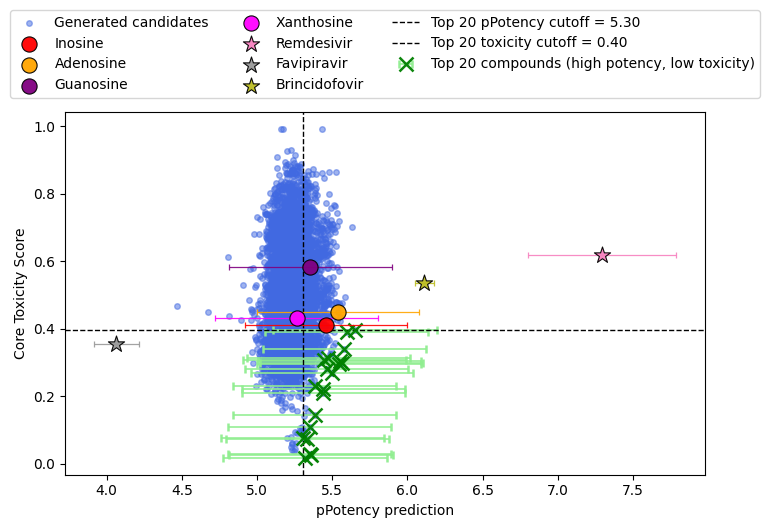

In [87]:
# ------------------------------------------------------------
# 8. Plot generated candidates + query candidates
# ------------------------------------------------------------
xDisplay = top20_2D_DF["pPotency_prediction"].min() if len(top20_2D_DF) else xCutoff2D
yDisplay = top20_2D_DF["coreToxicityScore"].max() if len(top20_2D_DF) else yCutoff2D

fig, ax = plt.subplots(figsize=(8, 6))

# ------------------------------------------------------------
# Display-only thinning for generated candidates
# This does NOT affect scoring, cutoffs, or top-20 selection.
# It only reduces overplotting in dense local neighborhoods.
# ------------------------------------------------------------
def thinForDisplay(DF, xCol, yCol, nXBins=70, nYBins=70, denseThreshold=8, keepFraction=0.5, randomState=42):
    plotDF = DF[[xCol, yCol]].dropna().copy()

    xMin, xMax = plotDF[xCol].min(), plotDF[xCol].max()
    yMin, yMax = plotDF[yCol].min(), plotDF[yCol].max()

    if xMin == xMax:
        xMax = xMin + 1e-9
    if yMin == yMax:
        yMax = yMin + 1e-9

    xEdges = np.linspace(xMin, xMax, nXBins + 1)
    yEdges = np.linspace(yMin, yMax, nYBins + 1)

    plotDF["xBin"] = pd.cut(plotDF[xCol], bins=xEdges, labels=False, include_lowest=True)
    plotDF["yBin"] = pd.cut(plotDF[yCol], bins=yEdges, labels=False, include_lowest=True)

    rng = np.random.default_rng(randomState)
    keptIndex = []

    for _, groupDF in plotDF.groupby(["xBin", "yBin"], dropna=False):
        nGroup = len(groupDF)

        if nGroup <= denseThreshold:
            keptIndex.extend(groupDF.index.tolist())
        else:
            nKeep = max(1, int(np.ceil(nGroup * keepFraction)))
            chosen = rng.choice(groupDF.index.to_numpy(), size=nKeep, replace=False)
            keptIndex.extend(chosen.tolist())

    return DF.loc[sorted(set(keptIndex))].copy()

# Use full cand2DDF for all calculations, but a thinned copy for display only
candPlotDF = thinForDisplay(
    cand2DDF,
    xCol="pPotency_prediction",
    yCol="coreToxicityScore",
    nXBins=70,
    nYBins=70,
    denseThreshold=8,
    keepFraction=0.5,
    randomState=42
)

print(f"Generated candidates used for analysis: {len(cand2DDF)}")
print(f"Generated candidates shown in blue cloud: {len(candPlotDF)}")

# Generated candidates: same style, but plotted from thinned display copy
ax.scatter(
    candPlotDF["pPotency_prediction"],
    candPlotDF["coreToxicityScore"],
    s=16,
    alpha=0.5,
    color="royalblue",
    label="Generated candidates"
)

# ------------------------------------------------------------
# Query compounds:
#   first compound  -> red circle
#   second compound -> yellow circle
#   remaining       -> star markers with distinct colors
# ------------------------------------------------------------
queryPlotDF = queryScoreDF.dropna(
    subset=["drugName", "pPotency_prediction", "coreToxicityScore"]
).drop_duplicates(subset=["drugName", "SMILES"]).copy()

print("\nQuery compounds that will be plotted:")
print(queryPlotDF[["drugName", "pPotency_prediction", "coreToxicityScore"]])

remainingColors = [
    "#A65628",  # brown
    "#66C2A5",  # teal
    "#F781BF",  # pink
    "#999999",  # gray
    "#BCBD22",  # olive
    "#8C564B",  # dark brown
    "#1F77B4",  # muted blue
    "#2CA02C",  # muted green
    "#D62728",  # muted red
    "#9467BD",  # muted purple
]

for i, (_, rowDF) in enumerate(queryPlotDF.iterrows()):
    if i == 0:
        marker = "o"
        color = "red"
        markerSize = 120
    elif i == 1:
        marker = "o"
        color = "orange"
        markerSize = 120
    elif i == 2:
        marker = "o"
        color = "purple"
        markerSize = 120
    elif i == 3:
        marker = "o"
        color = "magenta"
        markerSize = 120
    else:
        marker = "*"
        color = remainingColors[(i - 2) % len(remainingColors)]
        markerSize = 150

    ax.scatter(
        rowDF["pPotency_prediction"],
        rowDF["coreToxicityScore"],
        marker=marker,
        s=markerSize,
        color=color,
        edgecolors="black",
        linewidths=0.8,
        alpha=0.95,
        label=rowDF["drugName"],
        zorder=5
    )

    if pd.notna(rowDF["pPotency_std"]):
        ax.errorbar(
            rowDF["pPotency_prediction"],
            rowDF["coreToxicityScore"],
            xerr=float(rowDF["pPotency_std"]),
            fmt="none",
            ecolor=color,
            elinewidth=0.9,
            capsize=2,
            capthick=0.9,
            alpha=0.9,
            zorder=4
        )

# Top 20 generated compounds: keep same style
ax.errorbar(
    top20_2D_DF["pPotency_prediction"],
    top20_2D_DF["coreToxicityScore"],
    xerr=pd.to_numeric(top20_2D_DF["pPotency_std"], errors="coerce").fillna(0.0).values,
    fmt="x",
    color="green",
    ecolor="lightgreen",
    elinewidth=1.2,
    capsize=3,
    capthick=1.2,
    markersize=10,
    markeredgewidth=1.8,
    alpha=0.95,
    label="Top 20 compounds (high potency, low toxicity)"
)

# Same cutoff lines as your original style
ax.axvline(
    xDisplay,
    linestyle="--",
    linewidth=1.0,
    color="k",
    label=f"Top 20 pPotency cutoff = {xDisplay:.2f}"
)

ax.axhline(
    yDisplay,
    linestyle="--",
    linewidth=1.0,
    color="k",
    label=f"Top 20 toxicity cutoff = {yDisplay:.2f}"
)

ax.set_xlabel("pPotency prediction")
ax.set_ylabel("Core Toxicity Score")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=3, frameon=True)
plt.tight_layout(rect=[0, 0, 1, 0.90])

svg_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_queryCandidate.svg")
png_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_queryCandidate.png")

plt.savefig(svg_path, format="svg", dpi=600)
plt.savefig(png_path, format="png", dpi=600)
plt.show()

### Remove  `Adenosine+ Xanthosine + Guanosine` from plots

Generated candidates used for analysis: 7317
Generated candidates shown in blue cloud: 5018

Query compounds that will be plotted:
        drugName  pPotency_prediction  coreToxicityScore
0        Inosine             5.459329           0.409940
1      Adenosine             5.536453           0.449821
2      Guanosine             5.354144           0.583850
3     Xanthosine             5.262729           0.432503
4     Remdesivir             7.295000           0.619487
5    Favipiravir             4.065000           0.354732
6  Brincidofovir             6.113333           0.534243


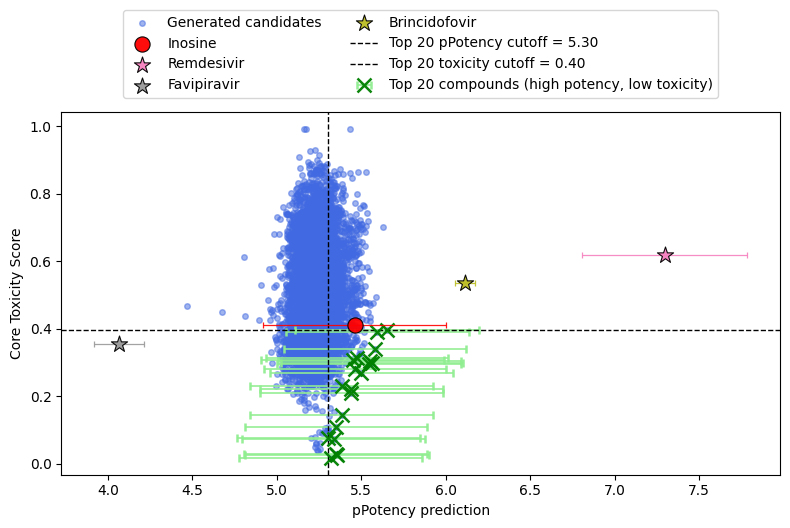

In [88]:
# ------------------------------------------------------------
# 8. Plot generated candidates + query candidates
# ------------------------------------------------------------
xDisplay = top20_2D_DF["pPotency_prediction"].min() if len(top20_2D_DF) else xCutoff2D
yDisplay = top20_2D_DF["coreToxicityScore"].max() if len(top20_2D_DF) else yCutoff2D

fig, ax = plt.subplots(figsize=(8, 6))

# ------------------------------------------------------------
# Display-only thinning for generated candidates
# This does NOT affect scoring, cutoffs, or top-20 selection.
# It only reduces overplotting in dense local neighborhoods.
# ------------------------------------------------------------
def thinForDisplay(DF, xCol, yCol, nXBins=70, nYBins=70, denseThreshold=8, keepFraction=0.5, randomState=42):
    plotDF = DF[[xCol, yCol]].dropna().copy()

    xMin, xMax = plotDF[xCol].min(), plotDF[xCol].max()
    yMin, yMax = plotDF[yCol].min(), plotDF[yCol].max()

    if xMin == xMax:
        xMax = xMin + 1e-9
    if yMin == yMax:
        yMax = yMin + 1e-9

    xEdges = np.linspace(xMin, xMax, nXBins + 1)
    yEdges = np.linspace(yMin, yMax, nYBins + 1)

    plotDF["xBin"] = pd.cut(plotDF[xCol], bins=xEdges, labels=False, include_lowest=True)
    plotDF["yBin"] = pd.cut(plotDF[yCol], bins=yEdges, labels=False, include_lowest=True)

    rng = np.random.default_rng(randomState)
    keptIndex = []

    for _, groupDF in plotDF.groupby(["xBin", "yBin"], dropna=False):
        nGroup = len(groupDF)

        if nGroup <= denseThreshold:
            keptIndex.extend(groupDF.index.tolist())
        else:
            nKeep = max(1, int(np.ceil(nGroup * keepFraction)))
            chosen = rng.choice(groupDF.index.to_numpy(), size=nKeep, replace=False)
            keptIndex.extend(chosen.tolist())

    return DF.loc[sorted(set(keptIndex))].copy()

# Use full cand2DDF for all calculations, but a thinned copy for display only
candPlotDF = thinForDisplay(
    cand2DDF,
    xCol="pPotency_prediction",
    yCol="coreToxicityScore",
    nXBins=70,
    nYBins=70,
    denseThreshold=8,
    keepFraction=0.5,
    randomState=42
)

print(f"Generated candidates used for analysis: {len(cand2DDF)}")
print(f"Generated candidates shown in blue cloud: {len(candPlotDF)}")

# Generated candidates: same style, but plotted from thinned display copy
ax.scatter(
    candPlotDF["pPotency_prediction"],
    candPlotDF["coreToxicityScore"],
    s=16,
    alpha=0.5,
    color="royalblue",
    label="Generated candidates"
)

# ------------------------------------------------------------
# Query compounds:
#   first compound  -> red circle
#   second compound -> yellow circle
#   remaining       -> star markers with distinct colors
# ------------------------------------------------------------
queryPlotDF = queryScoreDF.dropna(
    subset=["drugName", "pPotency_prediction", "coreToxicityScore"]
).drop_duplicates(subset=["drugName", "SMILES"]).copy()

print("\nQuery compounds that will be plotted:")
print(queryPlotDF[["drugName", "pPotency_prediction", "coreToxicityScore"]])

remainingColors = [
    "#A65628",  # brown
    "#66C2A5",  # teal
    "#F781BF",  # pink
    "#999999",  # gray
    "#BCBD22",  # olive
    "#8C564B",  # dark brown
    "#1F77B4",  # muted blue
    "#2CA02C",  # muted green
    "#D62728",  # muted red
    "#9467BD",  # muted purple
]

for i, (_, rowDF) in enumerate(queryPlotDF.iterrows()):
    if i in [1, 2, 3]:
        continue  # skip these indices

    if i == 0:
        marker = "o"
        color = "red"
        markerSize = 120
    else:
        marker = "*"
        color = remainingColors[(i - 2) % len(remainingColors)]
        markerSize = 150

    ax.scatter(
        rowDF["pPotency_prediction"],
        rowDF["coreToxicityScore"],
        marker=marker,
        s=markerSize,
        color=color,
        edgecolors="black",
        linewidths=0.8,
        alpha=0.95,
        label=rowDF["drugName"],
        zorder=5
    )

    if pd.notna(rowDF["pPotency_std"]):
        ax.errorbar(
            rowDF["pPotency_prediction"],
            rowDF["coreToxicityScore"],
            xerr=float(rowDF["pPotency_std"]),
            fmt="none",
            ecolor=color,
            elinewidth=0.9,
            capsize=2,
            capthick=0.9,
            alpha=0.9,
            zorder=4
        )


# Top 20 generated compounds: keep same style
ax.errorbar(
    top20_2D_DF["pPotency_prediction"],
    top20_2D_DF["coreToxicityScore"],
    xerr=pd.to_numeric(top20_2D_DF["pPotency_std"], errors="coerce").fillna(0.0).values,
    fmt="x",
    color="green",
    ecolor="lightgreen",
    elinewidth=1.2,
    capsize=3,
    capthick=1.2,
    markersize=10,
    markeredgewidth=1.8,
    alpha=0.95,
    label="Top 20 compounds (high potency, low toxicity)"
)

# Same cutoff lines as your original style
ax.axvline(
    xDisplay,
    linestyle="--",
    linewidth=1.0,
    color="k",
    label=f"Top 20 pPotency cutoff = {xDisplay:.2f}"
)

ax.axhline(
    yDisplay,
    linestyle="--",
    linewidth=1.0,
    color="k",
    label=f"Top 20 toxicity cutoff = {yDisplay:.2f}"
)

ax.set_xlabel("pPotency prediction")
ax.set_ylabel("Core Toxicity Score")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=True)
plt.tight_layout(rect=[0, 0, 1, 0.90])

svg_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_queryCandidate.svg")
png_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_queryCandidate.png")

plt.savefig(svg_path, format="svg", dpi=600)
plt.savefig(png_path, format="png", dpi=600)
plt.show()

# Check ADMET properties for `DORAnet` generated AntiVirals
- Starter - `Inosine substructures`

### 1. Read `ART` predicted `pPotency` of all the compounds

In [89]:
Ebola_InosineSimilarstructures_wART = pd.read_csv(saveDir + 'combinedEbolaVirusData_InosineSimilarstructures_DORAnetGenerated_ARTprediction.csv')
max_val = Ebola_InosineSimilarstructures_wART['pPotency_prediction'].max()
min_val = Ebola_InosineSimilarstructures_wART['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
Ebola_InosineSimilarstructures_wART

pPotency_prediction range: 4.398 → 6.025


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,5.336136,0.541734,4.274338,6.397935,0.000005,4.000046e-07,0.000053
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,5.260644,0.540668,4.200935,6.320352,0.000005,4.782418e-07,0.000063
2,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,5.447737,0.540431,4.388491,6.506983,0.000004,3.111842e-07,0.000041
3,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,5.460962,0.540024,4.402515,6.519408,0.000003,3.024068e-07,0.000040
4,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,5.315121,0.543254,4.250343,6.379898,0.000005,4.169669e-07,0.000056
...,...,...,...,...,...,...,...,...
1989628,CC#CC1(O)[C@H](n2c[n+](C)c3c(=O)[nH]c(N)nc32)O...,5.348185,0.542917,4.284069,6.412302,0.000004,3.869887e-07,0.000052
1989629,CC#CC1(O)C(O)[C@@H](C(C)O)O[C@H]1n1c[n+](C)c2c...,5.279424,0.541103,4.218862,6.339987,0.000005,4.571021e-07,0.000060
1989630,C#CC1(O)C(O)[C@@H](CO)O[C@H]1n1cnc2c(=O)[nH]c(...,5.294638,0.544153,4.228098,6.361178,0.000005,4.353336e-07,0.000059
1989631,CC#CC1(O)C(O)[C@@H](CO)O[C@]1(C)n1cnc2c(=O)[nH...,5.394842,0.541493,4.333515,6.456169,0.000004,3.498090e-07,0.000046


In [90]:
Ebola_InosineSimilarstructures_wART_wToxicity = pd.read_csv(saveDir + 'combinedEbolaVirusData_InosineSimilarstructures_DORAnetGenerated_ARTprediction_wToxicity.csv')
max_val = Ebola_InosineSimilarstructures_wART_wToxicity['pPotency_prediction'].max()
min_val = Ebola_InosineSimilarstructures_wART_wToxicity['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
Ebola_InosineSimilarstructures_wART_wToxicity

pPotency_prediction range: 4.653 → 5.985


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,molecular_weight,logP,...,Caco2_Wang_drugbank_approved_percentile,Clearance_Hepatocyte_AZ_drugbank_approved_percentile,Clearance_Microsome_AZ_drugbank_approved_percentile,Half_Life_Obach_drugbank_approved_percentile,HydrationFreeEnergy_FreeSolv_drugbank_approved_percentile,LD50_Zhu_drugbank_approved_percentile,Lipophilicity_AstraZeneca_drugbank_approved_percentile,PPBR_AZ_drugbank_approved_percentile,Solubility_AqSolDB_drugbank_approved_percentile,VDss_Lombardo_drugbank_approved_percentile
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,5.336136,0.541734,4.274338,6.397935,0.000005,4.000046e-07,0.000053,507.182,-1.62900,...,5.428461,23.381155,54.633579,87.398216,4.652966,9.112059,36.719659,28.887166,89.414502,9.732454
1,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,5.447737,0.540431,4.388491,6.506983,0.000004,3.111842e-07,0.000041,785.557,-2.42396,...,5.893757,12.563009,56.688639,69.910818,4.071345,53.392788,39.433889,46.219465,82.939124,2.326483
2,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,5.460962,0.540024,4.402515,6.519408,0.000003,3.024068e-07,0.000040,787.573,-1.75026,...,4.769290,15.936409,61.962001,83.365646,3.140752,61.186506,42.807290,44.784800,85.071733,7.134548
3,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,5.346715,0.540573,4.287192,6.406237,0.000005,3.924304e-07,0.000052,744.417,-2.89890,...,3.799922,19.542458,50.872431,92.904226,2.869329,13.803800,30.050407,24.505622,92.594029,16.401706
4,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,5.356202,0.540410,4.296998,6.415405,0.000004,3.842330e-07,0.000050,745.425,-2.56940,...,4.226444,29.701435,76.075998,88.096161,3.722373,29.352462,35.944164,27.142303,91.081815,2.791780
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345816,Nc1nc2c(ncn2C2O[C@]34O[C@@]3(C4O)[C@H]2OCO)c(=...,5.248396,0.540298,4.189412,6.307380,0.000006,4.927419e-07,0.000065,309.238,-2.59460,...,9.189608,31.446297,7.328422,43.117487,0.814269,75.765801,14.191547,13.571152,69.794494,31.562621
345817,Nc1nc2c(ncn2C2O[C@@]34OC3[C@]4(O)[C@H]2OCO)c(=...,5.271365,0.540410,4.212162,6.330569,0.000005,4.671231e-07,0.000061,309.238,-2.59460,...,9.461031,30.515704,9.344707,40.248158,0.891819,80.341218,15.277239,14.075223,68.243505,28.421869
345818,Nc1nc2c(nc3n2C2O[C@@H]4C(O)[C@]4(O3)[C@H]2OCO)...,5.249456,0.539813,4.191422,6.307490,0.000006,4.926175e-07,0.000064,309.238,-2.56010,...,13.028306,19.852656,2.365258,22.373013,1.318340,61.729352,14.540520,21.132222,61.108957,25.126018
345819,Nc1nc2c(nc3n2C2O[C@@H]4C(O3)[C@]4(O)[C@H]2OCO)...,5.291177,0.539717,4.233332,6.349023,0.000005,4.476895e-07,0.000058,309.238,-2.56010,...,13.260954,20.162854,2.481582,21.170997,1.240791,63.861962,14.501745,21.519969,59.984490,26.211710


### choose top 5000 compounds

### Combine `Inosie+Guanosine+Adenosine+Xanthosine & Inosine similar structures`

In [91]:
Ebola_InosineSimilarstructures_wART_wADMET = Ebola_InosineSimilarstructures_wART_wToxicity.copy()

In [92]:
# Common columns, but ordered as in Ebola_wART_DORAnetGenerated_AntiviralsDataset_predicted_all_wToxicity
common_cols = [
    c for c in Ebola_wART_DORAnetGenerated_AntiviralsDataset_predicted_all_wToxicity.columns
    if c in Ebola_InosineSimilarstructures_wART_wADMET.columns
]

# Ensure SMILES is present and first
if "SMILES" in common_cols:
    common_cols = ["SMILES"] + [c for c in common_cols if c != "SMILES"]

combinedDF = pd.concat(
    [
        Ebola_InosineSimilarstructures_wART_wADMET[common_cols],
        Ebola_wART_DORAnetGenerated_AntiviralsDataset_predicted_all_wToxicity[common_cols]
    ],
    ignore_index=True
).drop_duplicates(subset=["SMILES"]).reset_index(drop=True)

combinedDF

,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,molecular_weight,logP,...,Caco2_Wang,Clearance_Hepatocyte_AZ,Clearance_Microsome_AZ,Half_Life_Obach,HydrationFreeEnergy_FreeSolv,LD50_Zhu,Lipophilicity_AstraZeneca,PPBR_AZ,Solubility_AqSolDB,VDss_Lombardo
0,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,5.336136,0.541734,4.274338,6.397935,0.000005,4.000046e-07,0.000053,507.182,-1.62900,...,-6.532908,10.607536,21.695647,50.300162,-17.205968,1.654107,0.655960,57.025779,-0.437743,-4.687410
1,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,5.447737,0.540431,4.388491,6.506983,0.000004,3.111842e-07,0.000041,785.557,-2.42396,...,-6.475772,-3.364867,23.998967,23.188328,-17.767413,2.572223,0.824762,72.098404,-1.021829,-8.492948
2,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,5.460962,0.540024,4.402515,6.519408,0.000003,3.024068e-07,0.000040,787.573,-1.75026,...,-6.679487,1.394358,30.020669,41.759685,-18.648854,2.694055,1.037456,70.919499,-0.882326,-5.521714
3,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,5.346715,0.540573,4.287192,6.406237,0.000005,3.924304e-07,0.000052,744.417,-2.89890,...,-6.818474,5.750305,18.362396,75.728975,-19.110544,1.835266,0.205004,52.787176,0.022007,-3.040320
4,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,5.356202,0.540410,4.296998,6.415405,0.000004,3.842330e-07,0.000050,745.425,-2.56940,...,-6.744336,16.908523,47.892034,53.422075,-18.034575,2.189310,0.593944,55.243972,-0.186449,-8.067867
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
352068,N#CC(O)(O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[n...,5.311236,0.542423,4.248086,6.374385,0.000005,4.222944e-07,0.000056,350.247,-3.86964,...,-5.955260,-8.761916,-26.770016,14.103317,-22.354659,3.105875,-1.044692,56.499127,-1.956776,2.486373
352069,N#CC(O)(O)[C@H]1O[C@](C#N)(n2cnc3c(=O)[nH]c(=O...,5.157317,0.542338,4.094336,6.220299,0.000007,6.021448e-07,0.000080,350.247,-4.08564,...,-5.818521,-13.439529,-30.363843,23.556845,-21.883500,3.207771,-1.054912,57.989126,-2.152616,-1.152304
352070,N#Cc1nc2c(=O)[nH]c(=O)[nH]c2n1[C@@H]1O[C@H](C(...,5.297589,0.541998,4.235274,6.359904,0.000005,4.366119e-07,0.000058,350.247,-3.89174,...,-5.849040,-4.257238,-21.835345,18.294608,-21.778549,3.044578,-0.985986,57.468950,-2.193930,-0.049402
352071,O=C1NC2=NC(=O)[C@H]3O[C@H]([C@H](O)[C@@H]3O)n3...,5.303743,0.541890,4.241639,6.365846,0.000005,4.306792e-07,0.000057,279.212,-2.07580,...,-5.684864,-9.842546,-16.313448,76.343168,-23.489791,2.280219,-1.492284,34.876469,-2.238372,-4.511073


In [93]:
# ------------------------------------------------------------
# 1. Input data
# ------------------------------------------------------------
refDrugbankDF = drugBankDrug_FDAapproved_AntiViral_wART_wADMET.copy()
generatedCandidateDF = combinedDF.copy()
#generatedCandidateDF = Ebola_InosineSimilarstructures_wART_wADMET.copy()
queryCandidateDF = combinedQueryDF_wADMET.copy()

print("Drugbank reference dataframe shape:", refDrugbankDF.shape)
print("Generated candidate dataframe shape:", generatedCandidateDF.shape)
print("Combined query dataframe shape:", queryCandidateDF.shape)

# ------------------------------------------------------------
# 2. Basic harmonization
# ------------------------------------------------------------
def prepareDF(DF, datasetLabel):
    DF = DF.copy()

    if "smiles" in DF.columns and "SMILES" not in DF.columns:
        DF = DF.rename(columns={"smiles": "SMILES"})

    if "drugName" not in DF.columns:
        DF["drugName"] = DF["SMILES"]

    DF["datasetLabel"] = datasetLabel
    return DF

refDrugbankDF = prepareDF(refDrugbankDF, "Reference")
generatedCandidateDF = prepareDF(generatedCandidateDF, "Generated")
queryCandidateDF = prepareDF(queryCandidateDF, "Query")

# ------------------------------------------------------------
# 3. Keep only the columns needed for pPotency–toxicity scoring
# ------------------------------------------------------------
potencyCols = [
    "pPotency_prediction",
    "pPotency_std",
    "pPotency_lower_95CI",
    "pPotency_upper_95CI",
]

toxicityMeta = [
    ("AMES", "lowerBetter"),
    ("Carcinogens_Lagunin", "lowerBetter"),
    ("ClinTox", "lowerBetter"),
    ("DILI", "lowerBetter"),
    ("Skin_Reaction", "lowerBetter"),
    ("hERG", "lowerBetter"),
    ("LD50_Zhu", "higherBetter"),
    ("NR-AR-LBD", "lowerBetter"),
    ("NR-AR", "lowerBetter"),
    ("NR-AhR", "lowerBetter"),
    ("NR-Aromatase", "lowerBetter"),
    ("NR-ER-LBD", "lowerBetter"),
    ("NR-ER", "lowerBetter"),
    ("NR-PPAR-gamma", "lowerBetter"),
    ("SR-ARE", "lowerBetter"),
    ("SR-ATAD5", "lowerBetter"),
    ("SR-HSE", "lowerBetter"),
    ("SR-MMP", "lowerBetter"),
    ("SR-p53", "lowerBetter"),
]

toxicityCols = [endpoint for endpoint, _ in toxicityMeta]
keepCols = ["drugName", "SMILES"] + potencyCols + toxicityCols

def ensureCols(DF, colList):
    DF = DF.copy()
    for colName in colList:
        if colName not in DF.columns:
            DF[colName] = np.nan
    return DF[colList].copy()

refScoreDF = ensureCols(refDrugbankDF, keepCols)
candScoreDF = ensureCols(generatedCandidateDF, keepCols)
queryScoreDF = ensureCols(queryCandidateDF, keepCols)

for colName in potencyCols + toxicityCols:
    refScoreDF[colName] = pd.to_numeric(refScoreDF[colName], errors="coerce")
    candScoreDF[colName] = pd.to_numeric(candScoreDF[colName], errors="coerce")
    queryScoreDF[colName] = pd.to_numeric(queryScoreDF[colName], errors="coerce")

# ------------------------------------------------------------
# 4. Build endpoint weights from refDrugbankDF only
# ------------------------------------------------------------
def robustIQR(series):
    cleanSeries = pd.to_numeric(series, errors="coerce").dropna()
    if len(cleanSeries) < 5:
        return np.nan
    q25, q75 = np.percentile(cleanSeries, [25, 75])
    return q75 - q25

refToxDF = refScoreDF[toxicityCols].apply(pd.to_numeric, errors="coerce")
toxCorrDF = refToxDF.corr().abs()

weightRows = []
for endpointName, directionName in toxicityMeta:
    iqrValue = robustIQR(refToxDF[endpointName])
    informativeness = 1.0 / (iqrValue + 1e-6) if pd.notna(iqrValue) else 1.0

    otherEndpoints = [x for x in toxicityCols if x != endpointName]
    if endpointName in toxCorrDF.index and len(otherEndpoints) > 0:
        meanAbsCorr = toxCorrDF.loc[endpointName, otherEndpoints].dropna().mean()
    else:
        meanAbsCorr = np.nan

    uniqueness = max(1.0 - meanAbsCorr, 1e-3) if pd.notna(meanAbsCorr) else 1.0

    weightRows.append({
        "endpoint": endpointName,
        "direction": directionName,
        "rawWeight": informativeness * uniqueness,
    })

toxWeightDF = pd.DataFrame(weightRows)
toxWeightDF["finalWeight"] = toxWeightDF["rawWeight"] / toxWeightDF["rawWeight"].sum()

# ------------------------------------------------------------
# 5. Reference-based desirability functions
# ------------------------------------------------------------
def getSortedRefArray(series):
    refArray = pd.to_numeric(series, errors="coerce").dropna().to_numpy(dtype=float)
    refArray = refArray[np.isfinite(refArray)]
    return np.sort(refArray)

def higherBetterDes(refSeries, valueSeries):
    refArray = getSortedRefArray(refSeries)
    valueArray = pd.to_numeric(valueSeries, errors="coerce").to_numpy(dtype=float)
    outArray = np.full(len(valueArray), np.nan)

    if len(refArray) == 0:
        return pd.Series(outArray, index=valueSeries.index)

    finiteMask = np.isfinite(valueArray)
    percentileArray = np.searchsorted(refArray, valueArray[finiteMask], side="right") / len(refArray)
    outArray[finiteMask] = np.clip(percentileArray, 0.0, 1.0)
    return pd.Series(outArray, index=valueSeries.index)

def lowerBetterDes(refSeries, valueSeries):
    refArray = getSortedRefArray(refSeries)
    valueArray = pd.to_numeric(valueSeries, errors="coerce").to_numpy(dtype=float)
    outArray = np.full(len(valueArray), np.nan)

    if len(refArray) == 0:
        return pd.Series(outArray, index=valueSeries.index)

    finiteMask = np.isfinite(valueArray)
    percentileArray = np.searchsorted(refArray, valueArray[finiteMask], side="right") / len(refArray)
    outArray[finiteMask] = np.clip(1.0 - percentileArray, 0.0, 1.0)
    return pd.Series(outArray, index=valueSeries.index)

def weightedGeoMeanSeries(DF, valueColList, weightSeries):
    valueMatrix = DF[valueColList].to_numpy(dtype=float)
    weightArray = np.asarray(weightSeries, dtype=float)
    outArray = np.full(valueMatrix.shape[0], np.nan)

    for rowIdx in range(valueMatrix.shape[0]):
        rowArray = valueMatrix[rowIdx]
        finiteMask = np.isfinite(rowArray)

        if finiteMask.sum() == 0:
            continue

        rowValues = np.clip(rowArray[finiteMask], 1e-6, 1.0)
        rowWeights = weightArray[finiteMask]
        outArray[rowIdx] = np.exp(np.sum(rowWeights * np.log(rowValues)) / np.sum(rowWeights))

    return pd.Series(outArray, index=DF.index)

# ------------------------------------------------------------
# 6. Score generatedCandidateDF and queryCandidateDF
#    relative to refDrugbankDF
# ------------------------------------------------------------
for endpointName, directionName in toxicityMeta:
    desCol = f"{endpointName}_des"

    if directionName == "higherBetter":
        candScoreDF[desCol] = higherBetterDes(refScoreDF[endpointName], candScoreDF[endpointName])
        queryScoreDF[desCol] = higherBetterDes(refScoreDF[endpointName], queryScoreDF[endpointName])
    else:
        candScoreDF[desCol] = lowerBetterDes(refScoreDF[endpointName], candScoreDF[endpointName])
        queryScoreDF[desCol] = lowerBetterDes(refScoreDF[endpointName], queryScoreDF[endpointName])

candScoreDF["PotencyDesRaw"] = higherBetterDes(refScoreDF["pPotency_prediction"], candScoreDF["pPotency_prediction"])
queryScoreDF["PotencyDesRaw"] = higherBetterDes(refScoreDF["pPotency_prediction"], queryScoreDF["pPotency_prediction"])

toxDesCols = [f"{endpointName}_des" for endpointName, _ in toxicityMeta]

candScoreDF["ToxicitySafety"] = weightedGeoMeanSeries(
    candScoreDF, toxDesCols, toxWeightDF["finalWeight"]
)
queryScoreDF["ToxicitySafety"] = weightedGeoMeanSeries(
    queryScoreDF, toxDesCols, toxWeightDF["finalWeight"]
)

candScoreDF["coreToxicityScore"] = 1.0 - candScoreDF["ToxicitySafety"]
queryScoreDF["coreToxicityScore"] = 1.0 - queryScoreDF["ToxicitySafety"]

# ------------------------------------------------------------
# 7. Keep your original top-20 selection on generated candidates
# ------------------------------------------------------------
cand2DDF = candScoreDF.dropna(
    subset=["pPotency_prediction", "coreToxicityScore", "ToxicitySafety", "PotencyDesRaw"]
).copy()

xCutoff2D = cand2DDF["pPotency_prediction"].quantile(0.75)
yCutoff2D = cand2DDF["coreToxicityScore"].quantile(0.25)

optimal2DDF = cand2DDF[
    (cand2DDF["pPotency_prediction"] >= xCutoff2D) &
    (cand2DDF["coreToxicityScore"] <= yCutoff2D)
].copy()

optimal2DDF["OverallPriority2D"] = np.sqrt(
    optimal2DDF["PotencyDesRaw"] * optimal2DDF["ToxicitySafety"]
)

top20_2D_DF = optimal2DDF.sort_values(
    by=["OverallPriority2D", "pPotency_prediction", "coreToxicityScore"],
    ascending=[False, False, True]
).head(20).copy()

top20_2D_DF

Drugbank reference dataframe shape: (75, 44)
Generated candidate dataframe shape: (352073, 57)
Combined query dataframe shape: (7, 107)


,drugName,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,AMES,Carcinogens_Lagunin,ClinTox,DILI,...,NR-PPAR-gamma_des,SR-ARE_des,SR-ATAD5_des,SR-HSE_des,SR-MMP_des,SR-p53_des,PotencyDesRaw,ToxicitySafety,coreToxicityScore,OverallPriority2D
268439,CC(O)C(O)C(O)n1cnc2c(=O)[nH]cnc21,CC(O)C(O)C(O)n1cnc2c(=O)[nH]cnc21,5.818200,0.543468,4.753002,6.883398,0.175243,0.197206,0.069258,0.879021,...,0.880000,0.960000,0.946667,0.800000,0.920000,0.920000,0.986667,0.832210,0.167790,0.906153
63861,O=C(O)C(O)C(O)n1cnc2c(=O)[nH]cnc21,O=C(O)C(O)C(O)n1cnc2c(=O)[nH]cnc21,5.730182,0.542618,4.666651,6.793714,0.058496,0.087399,0.185211,0.936062,...,0.866667,0.920000,0.933333,0.906667,0.973333,0.920000,0.960000,0.852926,0.147074,0.904880
109690,[2H]C1([2H])[C@]([2H])(n2cnc3c(=O)[nH]c(NC(C)(...,[2H]C1([2H])[C@]([2H])(n2cnc3c(=O)[nH]c(NC(C)(...,5.710136,0.540489,4.650777,6.769494,0.186918,0.146723,0.228650,0.912082,...,0.853333,0.760000,0.906667,0.906667,0.960000,0.600000,0.960000,0.835732,0.164268,0.895714
177235,CC1(O)C(O)CC(n2cnc3c(=O)[nH]cnc32)C1O,CC1(O)C(O)CC(n2cnc3c(=O)[nH]cnc32)C1O,5.629241,0.541188,4.568513,6.689969,0.184167,0.069305,0.130317,0.917736,...,0.840000,0.933333,0.906667,0.626667,0.840000,0.813333,0.880000,0.850853,0.149147,0.865304
63911,O=c1[nH]cnc2c1ncn2C(O)C(O)O,O=c1[nH]cnc2c1ncn2C(O)C(O)O,5.722119,0.548050,4.647941,6.796297,0.311643,0.204605,0.139716,0.914741,...,0.853333,0.800000,0.906667,0.586667,0.866667,0.693333,0.960000,0.762086,0.237914,0.855338
177140,CC1(O)CC(n2cnc3c(=O)[nH]cnc32)C(O)C1O,CC1(O)CC(n2cnc3c(=O)[nH]cnc32)C(O)C1O,5.619224,0.541383,4.558113,6.680334,0.184487,0.071884,0.131921,0.923166,...,0.853333,0.933333,0.906667,0.613333,0.826667,0.826667,0.853333,0.855479,0.144521,0.854405
177440,O=C1C(O)CC(n2cnc3c(=O)[nH]cnc32)C1O,O=C1C(O)CC(n2cnc3c(=O)[nH]cnc32)C1O,5.815827,0.543350,4.750860,6.880793,0.352583,0.094719,0.112231,0.955107,...,0.733333,0.813333,0.720000,0.533333,0.760000,0.480000,0.986667,0.736953,0.263047,0.852717
63490,O=c1[nH]cnc2c1ncn2C(O)C(O)CO,O=c1[nH]cnc2c1ncn2C(O)C(O)CO,5.643460,0.545694,4.573899,6.713021,0.251242,0.211235,0.069667,0.870485,...,0.906667,0.920000,0.946667,0.813333,0.960000,0.920000,0.880000,0.826064,0.173936,0.852605
266722,CC([C@H](O)[C@H](O)CO)n1cnc2c(=O)[nH]cnc21,CC([C@H](O)[C@H](O)CO)n1cnc2c(=O)[nH]cnc21,5.626881,0.541809,4.564935,6.688827,0.290926,0.151917,0.115176,0.854517,...,0.866667,0.960000,0.920000,0.800000,0.893333,0.826667,0.880000,0.825100,0.174900,0.852108
283185,O=c1[nH]c(CO)nc2c1ncn2C(O)C1C[C@@H](O)C1O,O=c1[nH]c(CO)nc2c1ncn2C(O)C1C[C@@H](O)C1O,5.637943,0.543702,4.572287,6.703600,0.359772,0.088973,0.147790,0.856442,...,0.826667,0.920000,0.840000,0.680000,0.866667,0.813333,0.880000,0.811994,0.188006,0.845313


Generated candidates used for analysis: 352073
Generated candidates shown in blue cloud: 177509

Query compounds that will be plotted:
        drugName  pPotency_prediction  coreToxicityScore
0        Inosine             5.459329           0.409940
1      Adenosine             5.536453           0.449821
2      Guanosine             5.354144           0.583850
3     Xanthosine             5.262729           0.432503
4     Remdesivir             7.295000           0.619487
5    Favipiravir             4.065000           0.354732
6  Brincidofovir             6.113333           0.534243


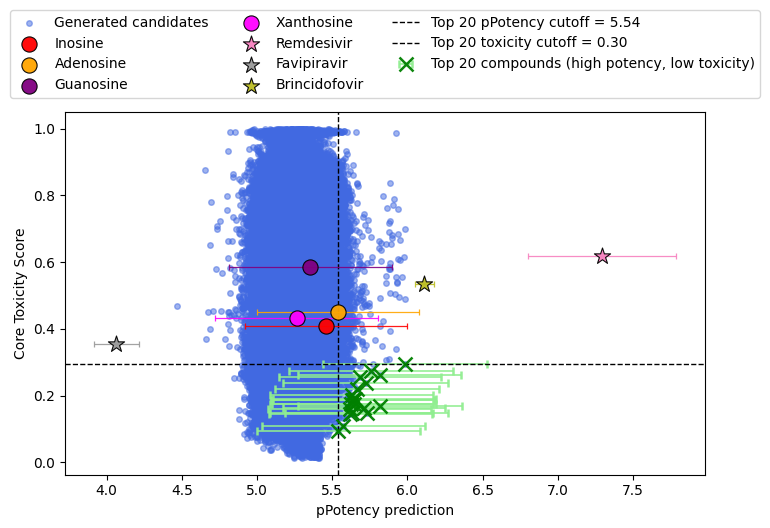

In [94]:
# ------------------------------------------------------------
# 8. Plot generated candidates + query candidates
# ------------------------------------------------------------
xDisplay = top20_2D_DF["pPotency_prediction"].min() if len(top20_2D_DF) else xCutoff2D
yDisplay = top20_2D_DF["coreToxicityScore"].max() if len(top20_2D_DF) else yCutoff2D

fig, ax = plt.subplots(figsize=(8, 6))

# ------------------------------------------------------------
# Display-only thinning for generated candidates
# This does NOT affect scoring, cutoffs, or top-20 selection.
# It only reduces overplotting in dense local neighborhoods.
# ------------------------------------------------------------
def thinForDisplay(DF, xCol, yCol, nXBins=70, nYBins=70, denseThreshold=8, keepFraction=0.5, randomState=42):
    plotDF = DF[[xCol, yCol]].dropna().copy()

    xMin, xMax = plotDF[xCol].min(), plotDF[xCol].max()
    yMin, yMax = plotDF[yCol].min(), plotDF[yCol].max()

    if xMin == xMax:
        xMax = xMin + 1e-9
    if yMin == yMax:
        yMax = yMin + 1e-9

    xEdges = np.linspace(xMin, xMax, nXBins + 1)
    yEdges = np.linspace(yMin, yMax, nYBins + 1)

    plotDF["xBin"] = pd.cut(plotDF[xCol], bins=xEdges, labels=False, include_lowest=True)
    plotDF["yBin"] = pd.cut(plotDF[yCol], bins=yEdges, labels=False, include_lowest=True)

    rng = np.random.default_rng(randomState)
    keptIndex = []

    for _, groupDF in plotDF.groupby(["xBin", "yBin"], dropna=False):
        nGroup = len(groupDF)

        if nGroup <= denseThreshold:
            keptIndex.extend(groupDF.index.tolist())
        else:
            nKeep = max(1, int(np.ceil(nGroup * keepFraction)))
            chosen = rng.choice(groupDF.index.to_numpy(), size=nKeep, replace=False)
            keptIndex.extend(chosen.tolist())

    return DF.loc[sorted(set(keptIndex))].copy()

# Use full cand2DDF for all calculations, but a thinned copy for display only
candPlotDF = thinForDisplay(
    cand2DDF,
    xCol="pPotency_prediction",
    yCol="coreToxicityScore",
    nXBins=70,
    nYBins=70,
    denseThreshold=8,
    keepFraction=0.5,
    randomState=42
)

print(f"Generated candidates used for analysis: {len(cand2DDF)}")
print(f"Generated candidates shown in blue cloud: {len(candPlotDF)}")

# Generated candidates: same style, but plotted from thinned display copy
ax.scatter(
    candPlotDF["pPotency_prediction"],
    candPlotDF["coreToxicityScore"],
    s=16,
    alpha=0.5,
    color="royalblue",
    label="Generated candidates"
)

# ------------------------------------------------------------
# Query compounds:
#   first compound  -> red circle
#   second compound -> yellow circle
#   remaining       -> star markers with distinct colors
# ------------------------------------------------------------
queryPlotDF = queryScoreDF.dropna(
    subset=["drugName", "pPotency_prediction", "coreToxicityScore"]
).drop_duplicates(subset=["drugName", "SMILES"]).copy()

print("\nQuery compounds that will be plotted:")
print(queryPlotDF[["drugName", "pPotency_prediction", "coreToxicityScore"]])

remainingColors = [
    "#A65628",  # brown
    "#66C2A5",  # teal
    "#F781BF",  # pink
    "#999999",  # gray
    "#BCBD22",  # olive
    "#8C564B",  # dark brown
    "#1F77B4",  # muted blue
    "#2CA02C",  # muted green
    "#D62728",  # muted red
    "#9467BD",  # muted purple
]

for i, (_, rowDF) in enumerate(queryPlotDF.iterrows()):
    if i == 0:
        marker = "o"
        color = "red"
        markerSize = 120
    elif i == 1:
        marker = "o"
        color = "orange"
        markerSize = 120
    elif i == 2:
        marker = "o"
        color = "purple"
        markerSize = 120
    elif i == 3:
        marker = "o"
        color = "magenta"
        markerSize = 120
    else:
        marker = "*"
        color = remainingColors[(i - 2) % len(remainingColors)]
        markerSize = 150

    ax.scatter(
        rowDF["pPotency_prediction"],
        rowDF["coreToxicityScore"],
        marker=marker,
        s=markerSize,
        color=color,
        edgecolors="black",
        linewidths=0.8,
        alpha=0.95,
        label=rowDF["drugName"],
        zorder=5
    )

    if pd.notna(rowDF["pPotency_std"]):
        ax.errorbar(
            rowDF["pPotency_prediction"],
            rowDF["coreToxicityScore"],
            xerr=float(rowDF["pPotency_std"]),
            fmt="none",
            ecolor=color,
            elinewidth=0.9,
            capsize=2,
            capthick=0.9,
            alpha=0.9,
            zorder=4
        )

# Top 20 generated compounds: keep same style
ax.errorbar(
    top20_2D_DF["pPotency_prediction"],
    top20_2D_DF["coreToxicityScore"],
    xerr=pd.to_numeric(top20_2D_DF["pPotency_std"], errors="coerce").fillna(0.0).values,
    fmt="x",
    color="green",
    ecolor="lightgreen",
    elinewidth=1.2,
    capsize=3,
    capthick=1.2,
    markersize=10,
    markeredgewidth=1.8,
    alpha=0.95,
    label="Top 20 compounds (high potency, low toxicity)"
)

# Same cutoff lines as your original style
ax.axvline(
    xDisplay,
    linestyle="--",
    linewidth=1.0,
    color="k",
    label=f"Top 20 pPotency cutoff = {xDisplay:.2f}"
)

ax.axhline(
    yDisplay,
    linestyle="--",
    linewidth=1.0,
    color="k",
    label=f"Top 20 toxicity cutoff = {yDisplay:.2f}"
)

ax.set_xlabel("pPotency prediction")
ax.set_ylabel("Core Toxicity Score")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=3, frameon=True)
plt.tight_layout(rect=[0, 0, 1, 0.90])

svg_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_InosineCandidates.svg")
png_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_InosineCandidates.png")

plt.savefig(svg_path, format="svg", dpi=600)
plt.savefig(png_path, format="png", dpi=600)
plt.show()

# Check ADMET properties for `DORAnet + DORA-XGB` generated AntiVirals
- Starter - `Inosine + Adenosine + Guanosine + Xanthosine`

### 1. Read `ART` predicted `pPotency` of all the compounds

In [95]:
Ebola_wART_DORAnetGenerated_Antivirals_predicted_all = pd.read_csv(saveDir + 'Ebola_allDORAnetGenerated_Antivirals_ARTprediction.csv')
max_val = Ebola_wART_DORAnetGenerated_Antivirals_predicted_all['pPotency_prediction'].max()
min_val = Ebola_wART_DORAnetGenerated_Antivirals_predicted_all['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
Ebola_wART_DORAnetGenerated_Antivirals_predicted_all

pPotency_prediction range: 4.470 → 5.649


,SMILES,Is_Starter,SourceDirectories,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,True,InosineOnly_gen3,5.459329,0.540618,4.399719,6.518939,0.000003,3.027338e-07,0.000040
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,False,InosineOnly_gen3,5.336136,0.541734,4.274338,6.397935,0.000005,4.000046e-07,0.000053
2,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,False,InosineOnly_gen3,5.260644,0.540668,4.200935,6.320352,0.000005,4.782418e-07,0.000063
3,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,False,InosineOnly_gen3,5.447737,0.540431,4.388491,6.506983,0.000004,3.111842e-07,0.000041
4,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,False,InosineOnly_gen3,5.460962,0.540024,4.402515,6.519408,0.000003,3.024068e-07,0.000040
...,...,...,...,...,...,...,...,...,...,...
20367,NC(O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c32...,False,XanthosineOnly_gen3,5.255267,0.543298,4.190404,6.320131,0.000006,4.784854e-07,0.000065
20368,NC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c3...,False,XanthosineOnly_gen3,5.260999,0.542954,4.196810,6.325188,0.000005,4.729461e-07,0.000064
20369,NC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c3...,False,XanthosineOnly_gen3,5.269796,0.541144,4.209154,6.330439,0.000005,4.672626e-07,0.000062
20370,CNC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[nH]c...,False,XanthosineOnly_gen3,5.209218,0.543006,4.144925,6.273511,0.000006,5.327083e-07,0.000072


### Retain only the molecules produced through high-feasibility reactions, as validated by the DPRA-XGB classifier.

In [96]:
doraxgbDir='/users/sghosh6/DTRA_project/MACAW/doranet/scripts'
highFeasibility_molecules_fromInosine = pd.read_csv(doraxgbDir + '/Inosine_Pubchem/InosineOnly_gen3/InosineOnly_gen3_uniqueMolecules.csv')
highFeasibility_molecules_fromGuanosine = pd.read_csv(doraxgbDir + '/Guanosine_Pubchem/GuanosineOnly_gen3/GuanosineOnly_gen3_uniqueMolecules.csv')
highFeasibility_molecules_fromAdenosine = pd.read_csv(doraxgbDir + '/Adenosine_Pubchem/AdenosineOnly_gen3/AdenosineOnly_uniqueMolecules.csv')
highFeasibility_molecules_fromXanthosine = pd.read_csv(doraxgbDir + '/Xanthosine_Pubchem/XanthosineOnly_gen3/XanthosineOnly_gen3_uniqueMolecules.csv')

allDORAnetGenerated_highFeasibility_molecules = pd.concat([
    highFeasibility_molecules_fromInosine,
    highFeasibility_molecules_fromGuanosine,
    highFeasibility_molecules_fromAdenosine,
    highFeasibility_molecules_fromXanthosine
], ignore_index=True)

print(f"Inosine shape    : {highFeasibility_molecules_fromInosine.shape}")
print(f"Guanosine shape  : {highFeasibility_molecules_fromGuanosine.shape}")
print(f"Adenosine shape  : {highFeasibility_molecules_fromAdenosine.shape}")
print(f"Xanthosine shape : {highFeasibility_molecules_fromXanthosine.shape}")
print(f"Combined shape   : {allDORAnetGenerated_highFeasibility_molecules.shape}")

Inosine shape    : (782, 5)
Guanosine shape  : (1828, 5)
Adenosine shape  : (1343, 5)
Xanthosine shape : (1005, 5)
Combined shape   : (4958, 5)


In [97]:
def canonicalize(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        return Chem.MolToSmiles(mol) if mol else None
    except:
        return None

# Canonicalize SMILES in both DataFrames
Ebola_wART_DORAnetGenerated_Antivirals_predicted_all["canon_SMILES"] = \
    Ebola_wART_DORAnetGenerated_Antivirals_predicted_all["SMILES"].apply(canonicalize)

allDORAnetGenerated_highFeasibility_molecules["canon_SMILES"] = \
    allDORAnetGenerated_highFeasibility_molecules["SMILES"].apply(canonicalize)

# Get valid canonical SMILES set from highFeasibility
highFeasibility_set = set(allDORAnetGenerated_highFeasibility_molecules["canon_SMILES"].dropna())

# Filter: keep only SMILES present in highFeasibility
Ebola_wART_DORAnetGenerated_Antivirals_predicted_all = \
    Ebola_wART_DORAnetGenerated_Antivirals_predicted_all[
        Ebola_wART_DORAnetGenerated_Antivirals_predicted_all["canon_SMILES"].isin(highFeasibility_set)
    ].drop(columns="canon_SMILES").reset_index(drop=True)

print(f"Filtered shape: {Ebola_wART_DORAnetGenerated_Antivirals_predicted_all.shape}")

Filtered shape: (4845, 10)


### plot `pPotency` distribution with error bars

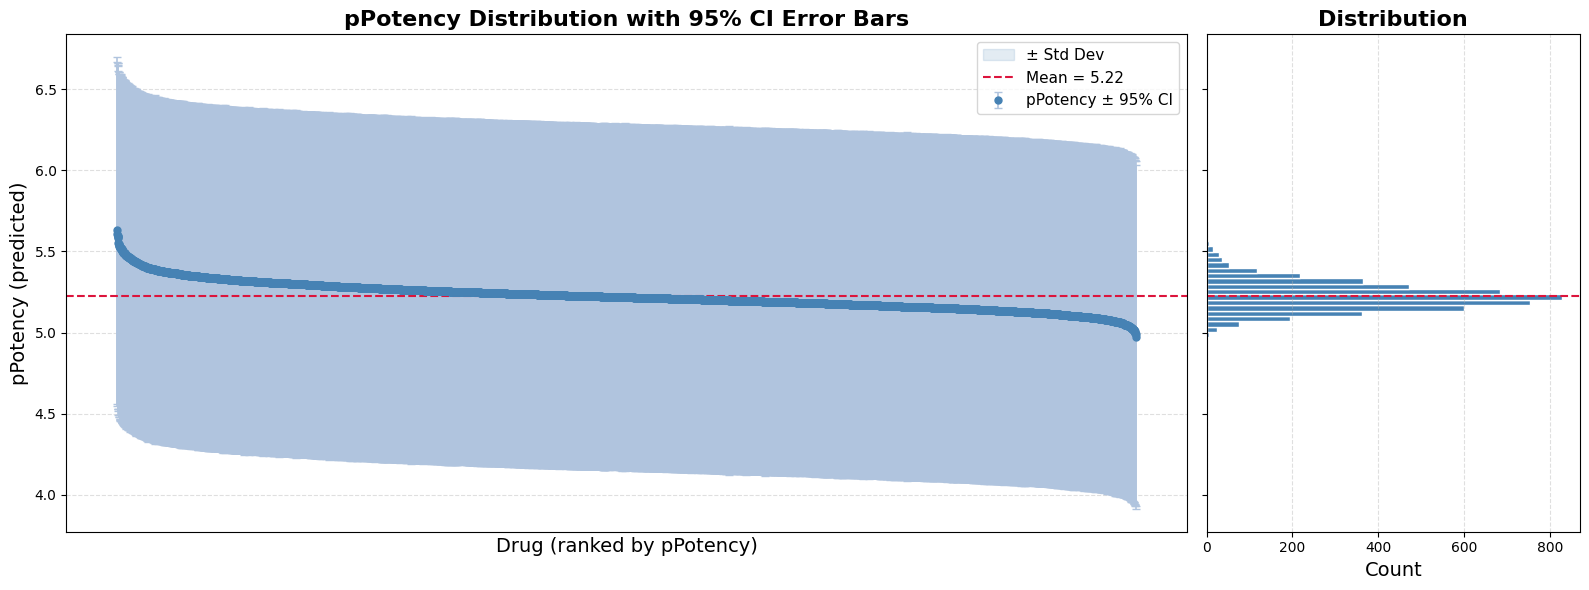

In [98]:
ppotencyDF = Ebola_wART_DORAnetGenerated_Antivirals_predicted_all.sort_values(
    "pPotency_prediction", ascending=False).reset_index(drop=True)

x = np.arange(len(ppotencyDF))
pred = ppotencyDF["pPotency_prediction"]
yerr = np.array([pred - ppotencyDF["pPotency_lower_95CI"],
                 ppotencyDF["pPotency_upper_95CI"] - pred])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6),
                                gridspec_kw={"width_ratios": [3, 1]}, sharey=True)

# ── Scatter + error bars ──────────────────────────────────────────────────────
ax1.errorbar(x, pred, yerr=yerr, fmt='o', color='steelblue', ecolor='lightsteelblue',
             elinewidth=1.2, capsize=3, markersize=5, alpha=1, label="pPotency ± 95% CI")
ax1.fill_between(x, pred - ppotencyDF["pPotency_std"], pred + ppotencyDF["pPotency_std"],
                 alpha=0.15, color='steelblue', label="± Std Dev")
ax1.axhline(pred.mean(),   color='crimson',    linestyle='--', linewidth=1.5, label=f'Mean = {pred.mean():.2f}')
#ax1.axhline(pred.median(), color='darkorange', linestyle=':',  linewidth=1.5, label=f'Median = {pred.median():.2f}')
ax1.set_xlabel("Drug (ranked by pPotency)", fontsize=14)  
ax1.set_ylabel("pPotency (predicted)",      fontsize=14) 
ax1.set_title("pPotency Distribution with 95% CI Error Bars", fontsize=16, fontweight='bold')  
ax1.set_xticks([])
ax1.legend(fontsize=11); ax1.grid(axis='y', linestyle='--', alpha=0.4)

# ── Histogram ─────────────────────────────────────────────────────────────────
ax2.hist(pred, bins=20, orientation='horizontal', color='steelblue', edgecolor='white', alpha=1)
ax2.axhline(pred.mean(),   color='crimson',    linestyle='--', linewidth=1.5)
#ax2.axhline(pred.median(), color='darkorange', linestyle=':',  linewidth=1.5)
ax2.set_xlabel("Count", fontsize=14)        
ax2.set_title("Distribution", fontsize=16, fontweight='bold') 
ax2.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
svg_path = os.path.join(saveDir, f"{target_organism}_pPotency_distribution_DORAnetGenerated_Antivirals.svg")
png_path = os.path.join(saveDir, f"{target_organism}_pPotency_distribution_DORAnetGenerated_Antivirals.png")
plt.savefig(svg_path, format="svg", dpi=600)
plt.savefig(png_path, format="png", dpi=600)
plt.show()

### Read predicted `ADMET` properties for all candidate SMILES

In [99]:
Ebola_wART_DORAnetGenerated_AntiviralsDataset_predicted_all_wToxicity = pd.read_csv(saveDir + 'Ebola_allDORAnetGenerated_Antivirals_ARTprediction_wToxicity.csv')
# Identify columns that match the string
matched_cols = Ebola_wART_DORAnetGenerated_AntiviralsDataset_predicted_all_wToxicity.filter(like='drugbank_approved_percentile').columns
# Keep everything EXCEPT those columns
Ebola_wART_DORAnetGenerated_AntiviralsDataset_predicted_all_wToxicity = Ebola_wART_DORAnetGenerated_AntiviralsDataset_predicted_all_wToxicity.drop(columns=matched_cols)
max_val = Ebola_wART_DORAnetGenerated_AntiviralsDataset_predicted_all_wToxicity['pPotency_prediction'].max()
min_val = Ebola_wART_DORAnetGenerated_AntiviralsDataset_predicted_all_wToxicity['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
Ebola_wART_DORAnetGenerated_AntiviralsDataset_predicted_all_wToxicity

pPotency_prediction range: 4.470 → 5.649


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,molecular_weight,logP,...,Caco2_Wang,Clearance_Hepatocyte_AZ,Clearance_Microsome_AZ,Half_Life_Obach,HydrationFreeEnergy_FreeSolv,LD50_Zhu,Lipophilicity_AstraZeneca,PPBR_AZ,Solubility_AqSolDB,VDss_Lombardo
0,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,5.459329,0.540618,4.399719,6.518939,0.000003,3.027338e-07,0.000040,268.229,-2.26890,...,-5.835234,28.025204,-17.188645,4.934540,-24.011630,2.159634,-1.774638,31.001650,-1.080324,-1.642514
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,5.336136,0.541734,4.274338,6.397935,0.000005,4.000046e-07,0.000053,507.182,-1.62900,...,-6.532908,10.607536,21.695647,50.300162,-17.205968,1.654107,0.655960,57.025779,-0.437743,-4.687410
2,Cc1cc2nc3c(=O)[nH]c(=O)nc-3n(C[C@H](O)[C@H](O)...,5.447737,0.540431,4.388491,6.506983,0.000004,3.111842e-07,0.000041,785.557,-2.42396,...,-6.475772,-3.364867,23.998967,23.188328,-17.767413,2.572223,0.824762,72.098404,-1.021829,-8.492948
3,Cc1cc2c(cc1C)N(C[C@H](O)[C@H](O)[C@H](O)COP(=O...,5.460962,0.540024,4.402515,6.519408,0.000003,3.024068e-07,0.000040,787.573,-1.75026,...,-6.679487,1.394358,30.020669,41.759685,-18.648854,2.694055,1.037456,70.919499,-0.882326,-5.521714
4,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,5.346715,0.540573,4.287192,6.406237,0.000005,3.924304e-07,0.000052,744.417,-2.89890,...,-6.818474,5.750305,18.362396,75.728975,-19.110544,1.835266,0.205004,52.787176,0.022007,-3.040320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7312,N#CC(O)(O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(=O)[n...,5.311236,0.542423,4.248086,6.374385,0.000005,4.222944e-07,0.000056,350.247,-3.86964,...,-5.955260,-8.761916,-26.770016,14.103317,-22.354659,3.105875,-1.044692,56.499127,-1.956776,2.486373
7313,N#CC(O)(O)[C@H]1O[C@](C#N)(n2cnc3c(=O)[nH]c(=O...,5.157317,0.542338,4.094336,6.220299,0.000007,6.021448e-07,0.000080,350.247,-4.08564,...,-5.818521,-13.439529,-30.363843,23.556845,-21.883500,3.207771,-1.054912,57.989126,-2.152616,-1.152304
7314,N#Cc1nc2c(=O)[nH]c(=O)[nH]c2n1[C@@H]1O[C@H](C(...,5.297589,0.541998,4.235274,6.359904,0.000005,4.366119e-07,0.000058,350.247,-3.89174,...,-5.849040,-4.257238,-21.835345,18.294608,-21.778549,3.044578,-0.985986,57.468950,-2.193930,-0.049402
7315,O=C1NC2=NC(=O)[C@H]3O[C@H]([C@H](O)[C@@H]3O)n3...,5.303743,0.541890,4.241639,6.365846,0.000005,4.306792e-07,0.000057,279.212,-2.07580,...,-5.684864,-9.842546,-16.313448,76.343168,-23.489791,2.280219,-1.492284,34.876469,-2.238372,-4.511073


In [100]:
def canonicalize(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        return Chem.MolToSmiles(mol) if mol else None
    except:
        return None

# Canonicalize SMILES in both DataFrames
Ebola_wART_DORAnetGenerated_AntiviralsDataset_predicted_all_wToxicity["canon_SMILES"] = \
    Ebola_wART_DORAnetGenerated_AntiviralsDataset_predicted_all_wToxicity["SMILES"].apply(canonicalize)

allDORAnetGenerated_highFeasibility_molecules["canon_SMILES"] = \
    allDORAnetGenerated_highFeasibility_molecules["SMILES"].apply(canonicalize)

# Get valid canonical SMILES set from highFeasibility
highFeasibility_set = set(allDORAnetGenerated_highFeasibility_molecules["canon_SMILES"].dropna())

# Filter: keep only SMILES present in highFeasibility
Ebola_wART_DORAnetGenerated_AntiviralsDataset_predicted_all_wToxicity = \
    Ebola_wART_DORAnetGenerated_AntiviralsDataset_predicted_all_wToxicity[
        Ebola_wART_DORAnetGenerated_AntiviralsDataset_predicted_all_wToxicity["canon_SMILES"].isin(highFeasibility_set)
    ].drop(columns="canon_SMILES").reset_index(drop=True)

print(f"Filtered shape: {Ebola_wART_DORAnetGenerated_AntiviralsDataset_predicted_all_wToxicity.shape}")

Filtered shape: (1474, 57)


### 2. AntiViral candidate prioritization by comparing with `Drugbank`

In [101]:
refDrugbankDF = drugBankDrug_FDAapproved_AntiViral_wART_wADMET.copy()
generatedCandidateDF = Ebola_wART_DORAnetGenerated_AntiviralsDataset_predicted_all_wToxicity.copy()

print("Drugbank reference dataframe shape:", refDrugbankDF.shape)
print("Generated candidate dataframe shape:", generatedCandidateDF.shape)

Drugbank reference dataframe shape: (75, 44)
Generated candidate dataframe shape: (1474, 57)


### 3. Harmonize metadata and the SMILES column

The candidate dataframe may use `SMILES` instead of `smiles`.  
This cell standardizes that and fills a few metadata fields if they are missing.

In [102]:
if "SMILES" in generatedCandidateDF.columns:
    generatedCandidateDF = generatedCandidateDF.rename(columns={"SMILES": "SMILES"})

if "ATC_code" not in generatedCandidateDF.columns:
    generatedCandidateDF["ATC_code"] = pd.NA

if "Drug_Type" not in generatedCandidateDF.columns:
    generatedCandidateDF["Drug_Type"] = "Predicted_candidate"

if "source_DataBase" not in generatedCandidateDF.columns:
    generatedCandidateDF["source_DataBase"] = "Generated"

refDrugbankDF["datasetLabel"] = "FDA-approved AntiVirals"
generatedCandidateDF["datasetLabel"] = "Generated candidates"

print("smiles in refDrugbankDF:", "SMILES" in refDrugbankDF.columns)
print("smiles in generatedCandidateDF:", "SMILES" in generatedCandidateDF.columns)

smiles in refDrugbankDF: True
smiles in generatedCandidateDF: True


### 4. Define `ADMET` column groups

We keep:
- metadata
- potency-related columns
- toxicity-related columns
- ADME-related columns
- a few physicochemical property columns such as `QED`, `logP` and `molecular_weight`

In [103]:
metadataCols = [
    "SMILES",
    "ATC_code",
    "Drug_Type",
    "source_DataBase",
    "datasetLabel",
]

potencyCols = [
    "pPotency_prediction",
    "pPotency_std",
    "pPotency_lower_95CI",
    "pPotency_upper_95CI",
    "IC50(M)_prediction",
    "IC50(M)_lower_95CI",
    "IC50(M)_upper_95CI",
]

toxicityCols = [
    "AMES",
    "Carcinogens_Lagunin",
    "ClinTox",
    "DILI",
    "Skin_Reaction",
    "hERG",
    "LD50_Zhu",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma",
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
]

admeCols = [
    "Bioavailability_Ma",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Caco2_Wang",
    "Solubility_AqSolDB",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith",
    "Pgp_Broccatelli",
    "Clearance_Hepatocyte_AZ",
    "Clearance_Microsome_AZ",
    "Half_Life_Obach",
    "PPBR_AZ",
    "VDss_Lombardo",
]

optionalCols = ["BBB_Martins"]

physicochemCols = [
    "molecular_weight",
    "logP",
    "hydrogen_bond_acceptors",
    "hydrogen_bond_donors",
    "Lipinski",
    "QED",
    "stereo_centers",
    "tpsa",
    "HydrationFreeEnergy_FreeSolv",
    "Lipophilicity_AstraZeneca",
]

keepCols = list(dict.fromkeys(metadataCols + potencyCols + toxicityCols + admeCols + optionalCols + physicochemCols))
print("Total kept columns:", len(keepCols))

Total kept columns: 61


### 5. Build aligned reference and candidate dataframes

This cell keeps the same columns in both dataframes and creates any missing columns as `NaN`

In [104]:
def ensureCols(DF, colList):
    outDF = DF.copy()
    for colName in colList:
        if colName not in outDF.columns:
            outDF[colName] = np.nan
    return outDF[colList].copy()

refScoreDF = ensureCols(refDrugbankDF, keepCols)
candScoreDF = ensureCols(generatedCandidateDF, keepCols)

print("Reference aligned shape:", refScoreDF.shape)
print("Candidate aligned shape:", candScoreDF.shape)

Reference aligned shape: (75, 61)
Candidate aligned shape: (1474, 61)


### 6. Convert relevant columns to numeric

All scoring-related columns are converted to numeric.  

In [105]:
numericCols = list(dict.fromkeys(potencyCols + toxicityCols + admeCols + optionalCols + physicochemCols))

for colName in numericCols:
    if colName in refScoreDF.columns:
        refScoreDF[colName] = pd.to_numeric(refScoreDF[colName], errors="coerce")
    if colName in candScoreDF.columns:
        candScoreDF[colName] = pd.to_numeric(candScoreDF[colName], errors="coerce")

refScoreDF["potencyConservative"] = refScoreDF["pPotency_lower_95CI"].fillna(refScoreDF["pPotency_prediction"])
candScoreDF["potencyConservative"] = candScoreDF["pPotency_lower_95CI"].fillna(candScoreDF["pPotency_prediction"])

### 7. Define endpoint metadata

This table contains:
- endpoint name
- whether it belongs to the **toxicity** or **adme** group
- the direction of desirability:
  - `lowerBetter`
  - `higherBetter`
  - `referenceMatch`


In [106]:
endpointMetaDF = pd.DataFrame([
    # Toxicity
    {"endpoint": "AMES",                "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "Carcinogens_Lagunin", "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "ClinTox",             "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "DILI",                "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "Skin_Reaction",       "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "hERG",                "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "LD50_Zhu",            "majorGroup": "toxicity", "direction": "higherBetter"},
    {"endpoint": "NR-AR-LBD",           "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-AR",               "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-AhR",              "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-Aromatase",        "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-ER-LBD",           "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-ER",               "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "NR-PPAR-gamma",       "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "SR-ARE",              "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "SR-ATAD5",            "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "SR-HSE",              "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "SR-MMP",              "majorGroup": "toxicity", "direction": "lowerBetter"},
    {"endpoint": "SR-p53",              "majorGroup": "toxicity", "direction": "lowerBetter"},

    # ADME
    {"endpoint": "Bioavailability_Ma",             "majorGroup": "adme", "direction": "higherBetter"},
    {"endpoint": "HIA_Hou",                        "majorGroup": "adme", "direction": "higherBetter"},
    {"endpoint": "PAMPA_NCATS",                    "majorGroup": "adme", "direction": "higherBetter"},
    {"endpoint": "Caco2_Wang",                     "majorGroup": "adme", "direction": "higherBetter"},
    {"endpoint": "Solubility_AqSolDB",             "majorGroup": "adme", "direction": "higherBetter"},
    {"endpoint": "CYP1A2_Veith",                   "majorGroup": "adme", "direction": "lowerBetter"},
    {"endpoint": "CYP2C19_Veith",                  "majorGroup": "adme", "direction": "lowerBetter"},
    {"endpoint": "CYP2C9_Substrate_CarbonMangels", "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "CYP2C9_Veith",                   "majorGroup": "adme", "direction": "lowerBetter"},
    {"endpoint": "CYP2D6_Substrate_CarbonMangels", "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "CYP2D6_Veith",                   "majorGroup": "adme", "direction": "lowerBetter"},
    {"endpoint": "CYP3A4_Substrate_CarbonMangels", "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "CYP3A4_Veith",                   "majorGroup": "adme", "direction": "lowerBetter"},
    {"endpoint": "Pgp_Broccatelli",                "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "Clearance_Hepatocyte_AZ",        "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "Clearance_Microsome_AZ",         "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "Half_Life_Obach",                "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "PPBR_AZ",                        "majorGroup": "adme", "direction": "referenceMatch"},
    {"endpoint": "VDss_Lombardo",                  "majorGroup": "adme", "direction": "referenceMatch"},
])

endpointMetaDF

,endpoint,majorGroup,direction
0,AMES,toxicity,lowerBetter
1,Carcinogens_Lagunin,toxicity,lowerBetter
2,ClinTox,toxicity,lowerBetter
3,DILI,toxicity,lowerBetter
4,Skin_Reaction,toxicity,lowerBetter
5,hERG,toxicity,lowerBetter
6,LD50_Zhu,toxicity,higherBetter
7,NR-AR-LBD,toxicity,lowerBetter
8,NR-AR,toxicity,lowerBetter
9,NR-AhR,toxicity,lowerBetter


### 8. Derive fully statistical endpoint weights from FDA-approved AntiVirals from `Drugbank`

For each endpoint we compute:

- **informativeness** = inverse of the reference IQR  
  A tighter approved-AntiViral distribution means the endpoint is more constrained and therefore more informative.

- **uniqueness** = inverse redundancy penalty  
  Endpoints that are highly correlated with other endpoints in the same group get reduced weight.

The final endpoint weights are normalized inside each major group:
- `toxicity`
- `adme`

In [107]:
def robustIQR(series):
    cleanSeries = pd.to_numeric(series, errors="coerce").dropna()
    if len(cleanSeries) < 5:
        return np.nan
    q25, q75 = np.percentile(cleanSeries, [25, 75])
    return q75 - q25

weightRows = []

for majorGroupName in endpointMetaDF["majorGroup"].unique():
    groupMetaDF = endpointMetaDF[endpointMetaDF["majorGroup"] == majorGroupName].copy()
    groupEndpoints = groupMetaDF["endpoint"].tolist()

    groupRefDF = refScoreDF[groupEndpoints].apply(pd.to_numeric, errors="coerce")
    groupCorrDF = groupRefDF.corr().abs()

    for endpointName in groupEndpoints:
        series = groupRefDF[endpointName]
        iqrValue = robustIQR(series)

        informativeness = 1.0 / (iqrValue + 1e-6) if pd.notna(iqrValue) else 1.0

        otherEndpoints = [x for x in groupEndpoints if x != endpointName]
        if len(otherEndpoints) > 0 and endpointName in groupCorrDF.index:
            meanAbsCorr = groupCorrDF.loc[endpointName, otherEndpoints].dropna().mean()
            uniqueness = max(1.0 - meanAbsCorr, 1e-3) if pd.notna(meanAbsCorr) else 1.0
        else:
            uniqueness = 1.0

        rawWeight = informativeness * uniqueness

        weightRows.append({
            "endpoint": endpointName,
            "majorGroup": majorGroupName,
            "direction": groupMetaDF.loc[groupMetaDF["endpoint"] == endpointName, "direction"].iloc[0],
            "iqrValue": iqrValue,
            "informativeness": informativeness,
            "uniqueness": uniqueness,
            "rawWeight": rawWeight,
        })

weightDF = pd.DataFrame(weightRows)
weightDF["finalWeight"] = (
    weightDF.groupby("majorGroup")["rawWeight"]
    .transform(lambda x: x / x.sum())
)

weightDF.sort_values(["majorGroup", "finalWeight"], ascending=[True, False])

,endpoint,majorGroup,direction,iqrValue,informativeness,uniqueness,rawWeight,finalWeight
20,HIA_Hou,adme,higherBetter,0.021880,45.702296,0.664728,30.379574,0.448401
24,CYP1A2_Veith,adme,lowerBetter,0.093155,10.734647,0.774213,8.310900,0.122669
28,CYP2D6_Substrate_CarbonMangels,adme,referenceMatch,0.116814,8.560575,0.669611,5.732252,0.084608
29,CYP2D6_Veith,adme,lowerBetter,0.117351,8.521400,0.626252,5.336541,0.078767
19,Bioavailability_Ma,adme,higherBetter,0.212015,4.716615,0.757873,3.574597,0.052761
26,CYP2C9_Substrate_CarbonMangels,adme,referenceMatch,0.225672,4.431191,0.593906,2.631713,0.038844
22,Caco2_Wang,adme,higherBetter,0.556913,1.795609,0.664372,1.192952,0.017608
23,Solubility_AqSolDB,adme,higherBetter,NaN,1.000000,1.000000,1.000000,0.014760
33,Clearance_Hepatocyte_AZ,adme,referenceMatch,NaN,1.000000,1.000000,1.000000,0.014760
34,Clearance_Microsome_AZ,adme,referenceMatch,NaN,1.000000,1.000000,1.000000,0.014760


### 9. Helper functions for desirability scoring and weighted aggregation

This section defines:

- percentile-based desirability functions
- a reference-matching desirability function
- weighted geometric mean aggregation

In [108]:
def getSortedRefArray(refSeries):
    refArray = pd.to_numeric(refSeries, errors="coerce").dropna().to_numpy(dtype=float)
    refArray = refArray[np.isfinite(refArray)]
    refArray = np.sort(refArray)
    return refArray

def higherBetterDes(refSeries, valueSeries):
    refArray = getSortedRefArray(refSeries)
    valueArray = pd.to_numeric(valueSeries, errors="coerce").to_numpy(dtype=float)
    outArray = np.full(len(valueArray), np.nan, dtype=float)

    if len(refArray) == 0:
        return pd.Series(outArray, index=valueSeries.index)

    finiteMask = np.isfinite(valueArray)
    percentArray = np.searchsorted(refArray, valueArray[finiteMask], side="right") / len(refArray)
    outArray[finiteMask] = np.clip(percentArray, 0.0, 1.0)
    return pd.Series(outArray, index=valueSeries.index)

def lowerBetterDes(refSeries, valueSeries):
    refArray = getSortedRefArray(refSeries)
    valueArray = pd.to_numeric(valueSeries, errors="coerce").to_numpy(dtype=float)
    outArray = np.full(len(valueArray), np.nan, dtype=float)

    if len(refArray) == 0:
        return pd.Series(outArray, index=valueSeries.index)

    finiteMask = np.isfinite(valueArray)
    percentArray = np.searchsorted(refArray, valueArray[finiteMask], side="right") / len(refArray)
    outArray[finiteMask] = np.clip(1.0 - percentArray, 0.0, 1.0)
    return pd.Series(outArray, index=valueSeries.index)

def referenceMatchDes(refSeries, valueSeries):
    refArray = getSortedRefArray(refSeries)
    valueArray = pd.to_numeric(valueSeries, errors="coerce").to_numpy(dtype=float)
    outArray = np.full(len(valueArray), np.nan, dtype=float)

    if len(refArray) == 0:
        return pd.Series(outArray, index=valueSeries.index)

    refMedian = np.nanmedian(refArray)
    q25, q75 = np.nanpercentile(refArray, [25, 75])
    robustSigma = (q75 - q25) / 1.349 if q75 > q25 else np.nanstd(refArray)

    if not np.isfinite(robustSigma) or robustSigma <= 0:
        robustSigma = 1e-6

    finiteMask = np.isfinite(valueArray)
    zArray = (valueArray[finiteMask] - refMedian) / robustSigma
    outArray[finiteMask] = np.exp(-0.5 * (zArray ** 2))
    outArray = np.clip(outArray, 0.0, 1.0)

    return pd.Series(outArray, index=valueSeries.index)

def weightedGeoMeanSeries(DF, valueColList, weightSeries):
    valueMatrix = DF[valueColList].to_numpy(dtype=float)
    weightArray = np.asarray(weightSeries, dtype=float)
    outArray = np.full(valueMatrix.shape[0], np.nan, dtype=float)

    for rowIdx in range(valueMatrix.shape[0]):
        rowArray = valueMatrix[rowIdx]
        finiteMask = np.isfinite(rowArray)

        if finiteMask.sum() == 0:
            continue

        rowValues = np.clip(rowArray[finiteMask], 1e-6, 1.0)
        rowWeights = weightArray[finiteMask]
        outArray[rowIdx] = np.exp(np.sum(rowWeights * np.log(rowValues)) / np.sum(rowWeights))

    return pd.Series(outArray, index=DF.index)

### 10. Convert endpoints into 0–1 desirability scores

Every endpoint becomes a new `*_des` column.
We also compute `PotencyDesRaw` from the reference AntiViral potency distribution.

In [109]:
for _, rowDF in weightDF.iterrows():
    endpointName = rowDF["endpoint"]
    directionName = rowDF["direction"]
    desCol = f"{endpointName}_des"

    if directionName == "higherBetter":
        refScoreDF[desCol] = higherBetterDes(refScoreDF[endpointName], refScoreDF[endpointName])
        candScoreDF[desCol] = higherBetterDes(refScoreDF[endpointName], candScoreDF[endpointName])

    elif directionName == "lowerBetter":
        refScoreDF[desCol] = lowerBetterDes(refScoreDF[endpointName], refScoreDF[endpointName])
        candScoreDF[desCol] = lowerBetterDes(refScoreDF[endpointName], candScoreDF[endpointName])

    elif directionName == "referenceMatch":
        refScoreDF[desCol] = referenceMatchDes(refScoreDF[endpointName], refScoreDF[endpointName])
        candScoreDF[desCol] = referenceMatchDes(refScoreDF[endpointName], candScoreDF[endpointName])

refScoreDF["PotencyDesRaw"] = higherBetterDes(
    refScoreDF["pPotency_prediction"],
    refScoreDF["pPotency_prediction"]
)

candScoreDF["PotencyDesRaw"] = higherBetterDes(
    refScoreDF["pPotency_prediction"],
    candScoreDF["pPotency_prediction"]
)
refScoreDF

,SMILES,ATC_code,Drug_Type,source_DataBase,datasetLabel,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,...,CYP2D6_Veith_des,CYP3A4_Substrate_CarbonMangels_des,CYP3A4_Veith_des,Pgp_Broccatelli_des,Clearance_Hepatocyte_AZ_des,Clearance_Microsome_AZ_des,Half_Life_Obach_des,PPBR_AZ_des,VDss_Lombardo_des,PotencyDesRaw
0,Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1,J05AF;J05AR,antiviral,FDA_Antivirals,FDA-approved AntiVirals,5.237696,0.541353,4.176643,6.298748,0.000006,...,0.680000,0.749483,0.546667,0.837055,NaN,NaN,NaN,NaN,NaN,0.386667
1,Nc1nc(=O)c2ncn(COCCO)c2[nH]1,J05AB,antiviral,FDA_Antivirals,FDA-approved AntiVirals,5.037581,0.543129,3.973048,6.102114,0.000009,...,0.866667,0.468450,0.893333,0.829210,NaN,NaN,NaN,NaN,NaN,0.093333
2,CC(C)(C)C(=O)OCOP(=O)(COCCn1cnc2c(N)ncnc21)OCO...,J05AF,antiviral,FDA_Antivirals,FDA-approved AntiVirals,5.233644,0.545209,4.165035,6.302253,0.000006,...,0.626667,0.892440,0.386667,0.998700,NaN,NaN,NaN,NaN,NaN,0.373333
3,CC(C)CN(C[C@@H](O)[C@H](Cc1ccccc1)NC(=O)O[C@H]...,J05AE,antiviral,FDA_Antivirals,FDA-approved AntiVirals,5.175844,0.542325,4.112886,6.238802,0.000007,...,0.080000,0.989583,0.053333,0.978069,NaN,NaN,NaN,NaN,NaN,0.293333
4,C=C[C@@H]1C[C@]1(NC(=O)[C@@H]1C[C@@H](Oc2ncc(O...,J05AP,antiviral,FDA_Antivirals,FDA-approved AntiVirals,5.626048,0.541898,4.563928,6.688167,0.000002,...,0.253333,0.865070,0.026667,0.978080,NaN,NaN,NaN,NaN,NaN,0.880000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@@H]1O,J05AB,antiviral,FDA_Antivirals,FDA-approved AntiVirals,5.536453,0.540180,4.477700,6.595206,0.000003,...,0.826667,0.500345,0.826667,0.825648,NaN,NaN,NaN,NaN,NaN,0.760000
71,CC[C@@H]1[C@@H]2CN(C(=O)[C@H](C(C)(C)C)NC(=O)O...,J05AP,antiviral,FDA_Antivirals,FDA-approved AntiVirals,5.878781,0.543114,4.814277,6.943285,0.000001,...,0.586667,0.944027,0.266667,0.969470,NaN,NaN,NaN,NaN,NaN,1.000000
72,Nc1ccn([C@H]2CC[C@@H](CO)O2)c(=O)n1,J05AF,antiviral,FDA_Antivirals,FDA-approved AntiVirals,5.039875,0.540991,3.979532,6.100217,0.000009,...,0.933333,0.495126,0.853333,0.824738,NaN,NaN,NaN,NaN,NaN,0.106667
73,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)OC(C(=O)...,J05AH,antiviral,FDA_Antivirals,FDA-approved AntiVirals,5.297290,0.545680,4.227758,6.366822,0.000005,...,0.386667,0.465962,0.986667,0.825159,NaN,NaN,NaN,NaN,NaN,0.533333


### 11. Directly aggregate within the two separate ADMET groups

This notebook uses:
- one direct **toxicity** aggregate
- one direct **adme** aggregate

Then we define:
- `ToxicitySafety`
- `Toxicity Score = 1 - ToxicitySafety`
- `ADMEFeasibility`

In [110]:
toxWeightDF = weightDF[weightDF["majorGroup"] == "toxicity"].copy()
admeWeightDF = weightDF[weightDF["majorGroup"] == "adme"].copy()

toxDesCols = [f"{endpointName}_des" for endpointName in toxWeightDF["endpoint"]]
admeDesCols = [f"{endpointName}_des" for endpointName in admeWeightDF["endpoint"]]

refScoreDF["ToxicitySafety"] = weightedGeoMeanSeries(
    refScoreDF,
    toxDesCols,
    toxWeightDF["finalWeight"]
)
candScoreDF["ToxicitySafety"] = weightedGeoMeanSeries(
    candScoreDF,
    toxDesCols,
    toxWeightDF["finalWeight"]
)

refScoreDF["ADMEFeasibility"] = weightedGeoMeanSeries(
    refScoreDF,
    admeDesCols,
    admeWeightDF["finalWeight"]
)
candScoreDF["ADMEFeasibility"] = weightedGeoMeanSeries(
    candScoreDF,
    admeDesCols,
    admeWeightDF["finalWeight"]
)

refScoreDF["coreToxicityScore"] = 1.0 - refScoreDF["ToxicitySafety"]
candScoreDF["coreToxicityScore"] = 1.0 - candScoreDF["ToxicitySafety"]

refScoreDF["ToxicityBurden"] = refScoreDF["coreToxicityScore"]
candScoreDF["ToxicityBurden"] = candScoreDF["coreToxicityScore"]

refScoreDF[["pPotency_prediction", "coreToxicityScore", "ADMEFeasibility"]].describe().T

,count,mean,std,min,25%,50%,75%,max
pPotency_prediction,75.0,5.329120,0.235755,4.852256,5.173378,5.289192,5.533146,5.878781
coreToxicityScore,75.0,0.585980,0.199487,0.219589,0.421852,0.564323,0.705460,0.999424
ADMEFeasibility,75.0,0.429011,0.187771,0.080314,0.314571,0.432448,0.551611,0.837525


## 12. Inspect the statistically derived endpoint weights

In [111]:
weightDF.sort_values(["majorGroup", "finalWeight"], ascending=[True, False])

,endpoint,majorGroup,direction,iqrValue,informativeness,uniqueness,rawWeight,finalWeight
20,HIA_Hou,adme,higherBetter,0.021880,45.702296,0.664728,30.379574,0.448401
24,CYP1A2_Veith,adme,lowerBetter,0.093155,10.734647,0.774213,8.310900,0.122669
28,CYP2D6_Substrate_CarbonMangels,adme,referenceMatch,0.116814,8.560575,0.669611,5.732252,0.084608
29,CYP2D6_Veith,adme,lowerBetter,0.117351,8.521400,0.626252,5.336541,0.078767
19,Bioavailability_Ma,adme,higherBetter,0.212015,4.716615,0.757873,3.574597,0.052761
26,CYP2C9_Substrate_CarbonMangels,adme,referenceMatch,0.225672,4.431191,0.593906,2.631713,0.038844
22,Caco2_Wang,adme,higherBetter,0.556913,1.795609,0.664372,1.192952,0.017608
23,Solubility_AqSolDB,adme,higherBetter,NaN,1.000000,1.000000,1.000000,0.014760
33,Clearance_Hepatocyte_AZ,adme,referenceMatch,NaN,1.000000,1.000000,1.000000,0.014760
34,Clearance_Microsome_AZ,adme,referenceMatch,NaN,1.000000,1.000000,1.000000,0.014760


### 13. Plot: `high pPotency` and `low Toxicity Score`

Selection rule:
- pPotency in the top quartile of generated compounds
- Toxicity Score in the bottom quartile of generated compounds

Within that selected region, ranking uses the geometric mean of:
- `PotencyDesRaw`
- `ToxicitySafety`

In [112]:
cand2DDF = candScoreDF.copy()

cand2DDF = cand2DDF[
    cand2DDF[["pPotency_prediction", "coreToxicityScore", "ToxicitySafety", "PotencyDesRaw"]]
    .notna()
    .all(axis=1)
].copy()

xCutoff2D = cand2DDF["pPotency_prediction"].quantile(0.75)
yCutoff2D = cand2DDF["coreToxicityScore"].quantile(0.25)

optimal2DDF = cand2DDF[
    (cand2DDF["pPotency_prediction"] >= xCutoff2D) &
    (cand2DDF["coreToxicityScore"] <= yCutoff2D)
].copy()

optimal2DDF["OverallPriority2D"] = np.sqrt(
    optimal2DDF["PotencyDesRaw"] * optimal2DDF["ToxicitySafety"]
)

top20_2D_DF = optimal2DDF.sort_values(
    by=["OverallPriority2D", "pPotency_prediction", "coreToxicityScore"],
    ascending=[False, False, True]
).head(20).copy()

top20_2D_DF["Top20Rank_2D"] = np.arange(1, len(top20_2D_DF) + 1)

top20_2D_DF[
    [
        "Top20Rank_2D",
        "SMILES",
        "pPotency_prediction",
        "pPotency_std",
        "pPotency_lower_95CI",
        "coreToxicityScore",
        "ToxicitySafety",
        "OverallPriority2D",
        "QED",
    ]
]

,Top20Rank_2D,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,coreToxicityScore,ToxicitySafety,OverallPriority2D,QED
22,1,O=C(O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]cnc32)[C@H]...,5.439854,0.540909,4.379672,0.222625,0.777375,0.741178,0.485234
617,2,COC(=O)OP(=O)(O)O,5.348856,0.542413,4.285727,0.029607,0.970393,0.737170,0.405060
280,3,Nc1ncnc2c1ncn2[C@@H]1O[C@H](C(=O)O)[C@@H](O)[C...,5.548892,0.539839,4.490807,0.304550,0.695450,0.733359,0.493710
538,4,O=COP(=O)(O)O,5.317889,0.543077,4.253458,0.016644,0.983356,0.733190,0.375363
618,5,CC(O)OP(=O)(O)O,5.335041,0.543682,4.269424,0.072561,0.927439,0.720670,0.354812
401,6,OC1=Nc2ncnc3c2ncn3[C@@H]2O[C@H]1[C@@H](O)[C@H]2O,5.595065,0.543265,4.530266,0.390078,0.609922,0.704322,0.558802
228,7,COC(=O)O,5.303604,0.542347,4.240604,0.076156,0.923844,0.701938,0.422195
128,8,O=C(O)[C@H]1O[C@@H]2[C@H](O)[C@@H]1Oc1nc3c(ncn...,5.447498,0.540629,4.387865,0.306183,0.693817,0.700213,0.556867
400,9,Nc1ncnc2c1ncn2[C@@H]1OC[C@@H](O)[C@H]1O,5.490917,0.545010,4.422698,0.325715,0.674285,0.696768,0.561054
234,10,OCC(O)O,5.304038,0.543528,4.238723,0.103038,0.896962,0.691650,0.327154


### 14. plot: pPotency vs Toxicity Score

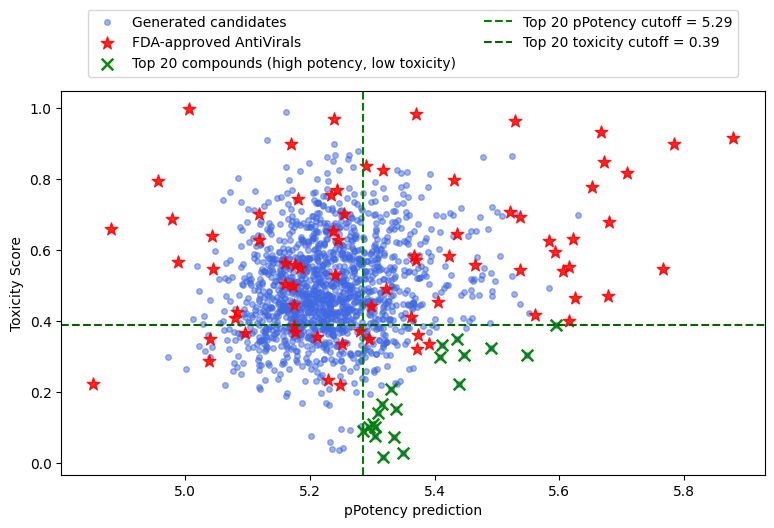

In [113]:
# Display cutoffs from the actual top 20 compounds
xDisplay = top20_2D_DF["pPotency_prediction"].min()
yDisplay = top20_2D_DF["coreToxicityScore"].max()

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    cand2DDF["pPotency_prediction"],
    cand2DDF["coreToxicityScore"],
    s=16, alpha=0.5, color="royalblue", label="Generated candidates"
)

ax.scatter(
    refScoreDF["pPotency_prediction"],
    refScoreDF["coreToxicityScore"],
    marker="*", s=90, alpha=0.85, color="red", label="FDA-approved AntiVirals"
)

ax.scatter(
    top20_2D_DF["pPotency_prediction"],
    top20_2D_DF["coreToxicityScore"],
    marker="x", s=70, linewidths=1.8, alpha=0.95, color="green",
    label="Top 20 compounds (high potency, low toxicity)"
)

ax.axvline(
    xDisplay,
    linestyle="--",
    linewidth=1.5,
    color="green",
    label=f"Top 20 pPotency cutoff = {xDisplay:.2f}"
)

ax.axhline(
    yDisplay,
    linestyle="--",
    linewidth=1.5,
    color="darkgreen",
    label=f"Top 20 toxicity cutoff = {yDisplay:.2f}"
)

ax.set_xlabel("pPotency prediction")
ax.set_ylabel("Toxicity Score")

ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=True)
plt.tight_layout(rect=[0, 0, 1, 0.90])

svg_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_DORAnetGenerated_Antivirals_wDoraxgb.svg")
png_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_DORAnetGenerated_Antivirals_wDoraxgb.png")

plt.savefig(svg_path, format="svg", dpi=600)
plt.savefig(png_path, format="png", dpi=600)
plt.show()

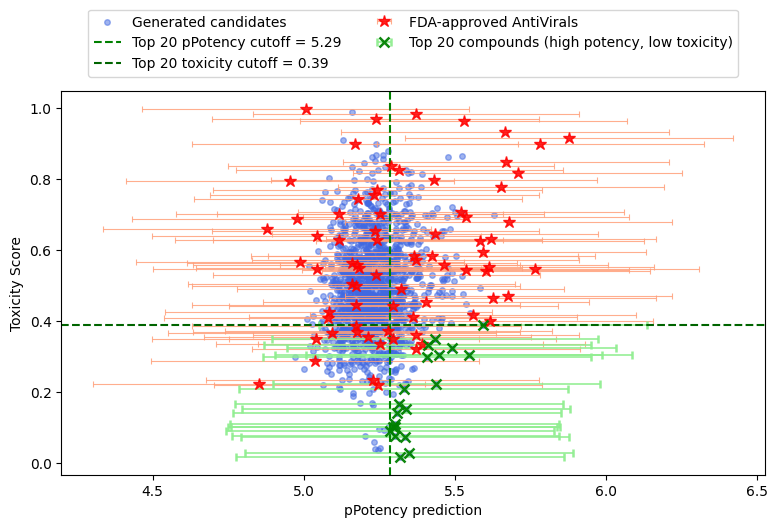

In [114]:
# Display cutoffs from the actual top 20 compounds
xDisplay = top20_2D_DF["pPotency_prediction"].min()
yDisplay = top20_2D_DF["coreToxicityScore"].max()

fig, ax = plt.subplots(figsize=(8, 6))

# ── Helper to compute asymmetric xerr ────────────────────────────────────────
'''
def get_xerr(df):
    return np.array([
        df["pPotency_prediction"] - df["pPotency_lower_95CI"],
        df["pPotency_upper_95CI"] - df["pPotency_prediction"],
    ])
'''

def get_xerr(df):
    return df["pPotency_std"].values  # symmetric → single array, not shape(2,N)


# ── Generated candidates ──────────────────────────────────────────────────────
ax.scatter(
    cand2DDF["pPotency_prediction"],
    cand2DDF["coreToxicityScore"],
    s=16, alpha=0.5, color="royalblue", label="Generated candidates"
)


# ── FDA-approved AntiVirals ───────────────────────────────────────────────────
ax.errorbar(
    refScoreDF["pPotency_prediction"],
    refScoreDF["coreToxicityScore"],
    xerr=get_xerr(refScoreDF),
    fmt="*", color="red", ecolor="lightsalmon",
    elinewidth=0.8, capsize=2, capthick=0.8,
    markersize=9, alpha=0.85, label="FDA-approved AntiVirals"
)

# ── Top 20 compounds ──────────────────────────────────────────────────────────
ax.errorbar(
    top20_2D_DF["pPotency_prediction"],
    top20_2D_DF["coreToxicityScore"],
    xerr=get_xerr(top20_2D_DF),
    fmt="x", color="green", ecolor="lightgreen",
    elinewidth=1.2, capsize=3, capthick=1.2,
    markersize=7, markeredgewidth=1.8,
    alpha=0.95, label="Top 20 compounds (high potency, low toxicity)"
)

ax.axvline(xDisplay, linestyle="--", linewidth=1.5, color="green",
           label=f"Top 20 pPotency cutoff = {xDisplay:.2f}")
ax.axhline(yDisplay, linestyle="--", linewidth=1.5, color="darkgreen",
           label=f"Top 20 toxicity cutoff = {yDisplay:.2f}")

ax.set_xlabel("pPotency prediction")
ax.set_ylabel("Toxicity Score")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=True)
plt.tight_layout(rect=[0, 0, 1, 0.90])

svg_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_DORAnetGenerated_Antivirals_wDoraxgb.svg")
png_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_DORAnetGenerated_Antivirals_wDoraxgb.png")
plt.savefig(svg_path, format="svg", dpi=600)
plt.savefig(png_path, format="png", dpi=600)
plt.show()

### 15. Plot: `high pPotency`, `low Toxicity Score`, `high ADME feasibility`

Selection rule:
- pPotency in the top quartile
- Toxicity Score in the bottom quartile
- ADMEFeasibility in the top quartile

Within that region, ranking uses the unweighted geometric mean of:
- `PotencyDesRaw`
- `ToxicitySafety`
- `ADMEFeasibility`

In [115]:
cand3DDF = candScoreDF.copy()

cand3DDF = cand3DDF[
    cand3DDF[["pPotency_prediction", "coreToxicityScore", "ADMEFeasibility", "ToxicitySafety", "PotencyDesRaw"]]
    .notna()
    .all(axis=1)
].copy()

xCutoff3D = cand3DDF["pPotency_prediction"].quantile(0.75)
yCutoff3D = cand3DDF["coreToxicityScore"].quantile(0.25)
zCutoff3D = cand3DDF["ADMEFeasibility"].quantile(0.75)

optimal3DDF = cand3DDF[
    (cand3DDF["pPotency_prediction"] >= xCutoff3D) &
    (cand3DDF["coreToxicityScore"] <= yCutoff3D) &
    (cand3DDF["ADMEFeasibility"] >= zCutoff3D)
].copy()

optimal3DDF["OverallPriority3D"] = (
    optimal3DDF["PotencyDesRaw"] *
    optimal3DDF["ToxicitySafety"] *
    optimal3DDF["ADMEFeasibility"]
) ** (1 / 3)

top20_3D_DF = optimal3DDF.sort_values(
    by=["OverallPriority3D", "pPotency_prediction", "coreToxicityScore", "ADMEFeasibility"],
    ascending=[False, False, True, False]
).head(20).copy()

top20_3D_DF["Top20Rank_3D"] = np.arange(1, len(top20_3D_DF) + 1)

top20_3D_DF[
    [
        "Top20Rank_3D",
        "SMILES",
        "pPotency_prediction",
        "pPotency_std",
        "pPotency_lower_95CI",
        "coreToxicityScore",
        "ADMEFeasibility",
        "ToxicitySafety",
        "OverallPriority3D",
        "QED",
    ]
]

,Top20Rank_3D,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,coreToxicityScore,ADMEFeasibility,ToxicitySafety,OverallPriority3D,QED
155,1,COC,5.294713,0.543597,4.229263,0.101738,0.821737,0.898262,0.720476,0.380040
213,2,CCO,5.338668,0.543588,4.273235,0.153545,0.744416,0.846455,0.706647,0.406808
157,3,COC(C)=O,5.285757,0.543428,4.220637,0.091076,0.706245,0.908924,0.681618,0.382967
703,4,CC1=Nc2ncnc3c2ncn3[C@@H]2O[C@@](C)(CO)[C@@H](O...,5.321167,0.541324,4.260172,0.360678,0.815168,0.639322,0.658006,0.756551
530,5,CO[C@H]1[C@H](n2cnc3c(N)ncnc32)O[C@@](C)(COC(C...,5.292663,0.541746,4.230841,0.356696,0.793536,0.643304,0.637140,0.716559
500,6,COC1=Nc2ncnc3c2ncn3[C@@H]2O[C@H]1[C@@H](O)[C@H]2O,5.316491,0.542356,4.253474,0.363411,0.736643,0.636589,0.630045,0.643138
508,7,CO[C@@]1(C)[C@@H](CO)O[C@@H](n2cnc3c(NC(C)=O)n...,5.352073,0.542649,4.288481,0.335740,0.667631,0.664260,0.628571,0.676381
400,8,Nc1ncnc2c1ncn2[C@@H]1OC[C@@H](O)[C@H]1O,5.490917,0.545010,4.422698,0.325715,0.508993,0.674285,0.627523,0.561054
507,9,CO[C@@H]1[C@@H](CO)O[C@@H](n2cnc3c(NC(C)=O)ncn...,5.306528,0.542217,4.243781,0.307385,0.558372,0.692615,0.590842,0.676381
545,10,C[C@@]1(CO)O[C@@H](n2cnc3c(N)ncnc32)[C@H](O)[C...,5.488559,0.541272,4.427666,0.395115,0.471342,0.604885,0.589903,0.516309


### 16. plot: pPotency vs Toxicity Score vs ADME feasibility

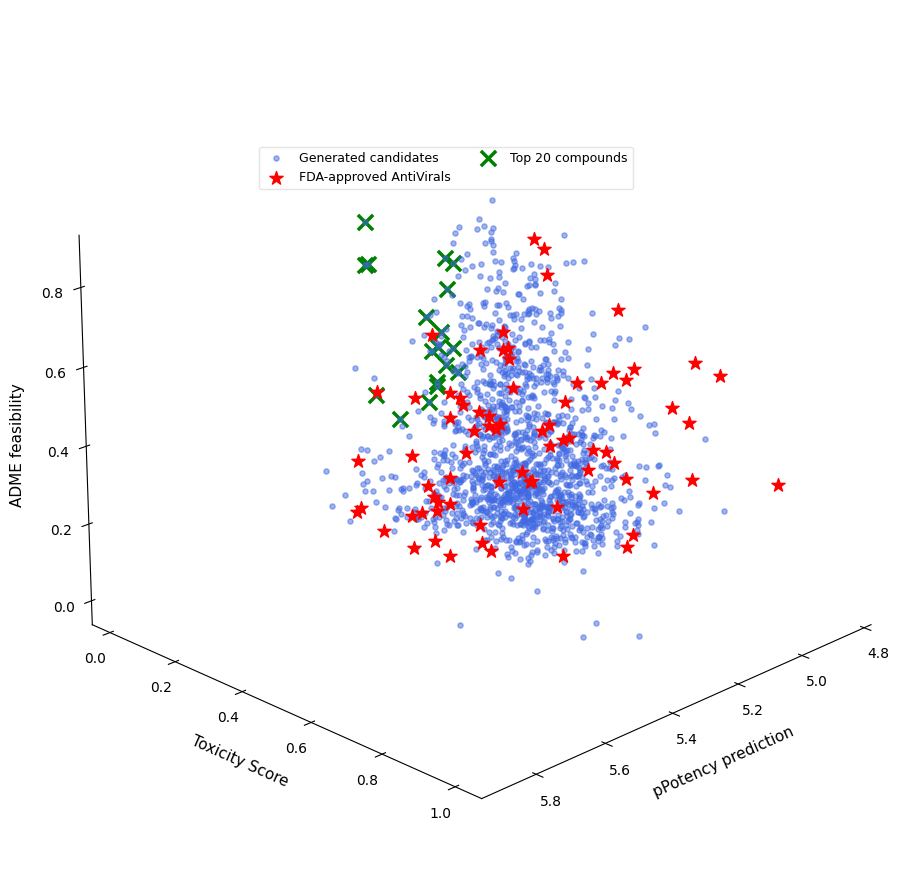

In [116]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(13, 10))
ax  = fig.add_subplot(111, projection="3d")

fig.patch.set_alpha(0.0)
ax.set_facecolor((0, 0, 0, 0))

for pane in [ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane]:
    pane.fill = False
    pane.set_edgecolor("lightgray")
    pane.set_alpha(0.0)

ax.grid(False)
for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis._axinfo["grid"]["linewidth"] = 0
    axis.label.set_color("k")
    axis.set_tick_params(colors="k")

ax.scatter(
    cand3DDF["pPotency_prediction"], cand3DDF["coreToxicityScore"], cand3DDF["ADMEFeasibility"],
    s=14, alpha=0.5, color="royalblue", label="Generated candidates", depthshade=False,
)
ax.scatter(
    refScoreDF["pPotency_prediction"], refScoreDF["coreToxicityScore"], refScoreDF["ADMEFeasibility"],
    marker="*", s=100, alpha=1.0, color="red", label="FDA-approved AntiVirals", depthshade=False,
)
ax.scatter(
    top20_3D_DF["pPotency_prediction"], top20_3D_DF["coreToxicityScore"], top20_3D_DF["ADMEFeasibility"],
    marker="x", s=120, linewidths=2.5, alpha=1.0, color="green", label="Top 20 compounds", depthshade=False,
)

xCutoff = top20_3D_DF["pPotency_prediction"].min()
yCutoff = top20_3D_DF["coreToxicityScore"].max()
zCutoff = top20_3D_DF["ADMEFeasibility"].min()

xMin, xMax = ax.get_xlim()
yMin, yMax = ax.get_ylim()
zMin, zMax = ax.get_zlim()

#cutoffStyle = dict(linewidth=1.8, linestyle="--", alpha=0.85)
#ax.plot([xMin,    xCutoff], [yCutoff, yCutoff], [zCutoff, zCutoff], color="green",     label=f"pPotency cutoff = {xCutoff:.2f}", **cutoffStyle)
#ax.plot([xCutoff, xCutoff], [yCutoff, yMax],    [zCutoff, zCutoff], color="darkolivegreen", label=f"Toxicity cutoff = {yCutoff:.2f}", **cutoffStyle)
#ax.plot([xCutoff, xCutoff], [yCutoff, yCutoff], [zMin,    zCutoff], color="seagreen",  label=f"ADME cutoff = {zCutoff:.2f}",    **cutoffStyle)
#ax.scatter([xCutoff], [yCutoff], [zCutoff], marker="D", s=180, color="gold", edgecolors="darkorange", linewidths=1.5, zorder=10, label="Optimal cutoff corner", depthshade=False)

ax.set_xlabel("pPotency prediction", labelpad=10, color="k", fontsize=11)
ax.set_ylabel("Toxicity Score", labelpad=10, color="k", fontsize=11)
ax.set_zlabel("ADME feasibility",    labelpad=10, color="k", fontsize=11)
ax.set_zlabel("")
ax.text2D(-0.02, 0.5, "ADME feasibility", transform=ax.transAxes, fontsize=11, color="k", rotation=90, va="center", ha="center")

for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis.set_tick_params(colors="k", labelsize=10)

ax.view_init(elev=22, azim=45)
ax.legend(loc="upper left", bbox_to_anchor=(0.25, 0.85), ncol=2, frameon=True, framealpha=0.3, facecolor="white", edgecolor="darkgray", labelcolor="black", fontsize=9)
fig.subplots_adjust(left=0.05, right=0.95, top=0.92, bottom=0.05)

svg_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_adme_3d_DORAnetGenerated_Antivirals_wDoraxgb.svg")
png_path = os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_adme_3d_DORAnetGenerated_Antivirals_wDoraxgb.png")
plt.savefig(svg_path, format="svg", dpi=600, transparent=True, pad_inches=0.5)
plt.savefig(png_path, format="png", dpi=600, transparent=True, pad_inches=0.5)
plt.show()

### 17. Custom projected 3D plot for presentation

This is a presentation-oriented 2D projection of 3 variables.

Projected axes:
- horizontal right = `pPotency`
- vertical up = `Toxicity Score`
- diagonal lower-left = `ADME feasibility`

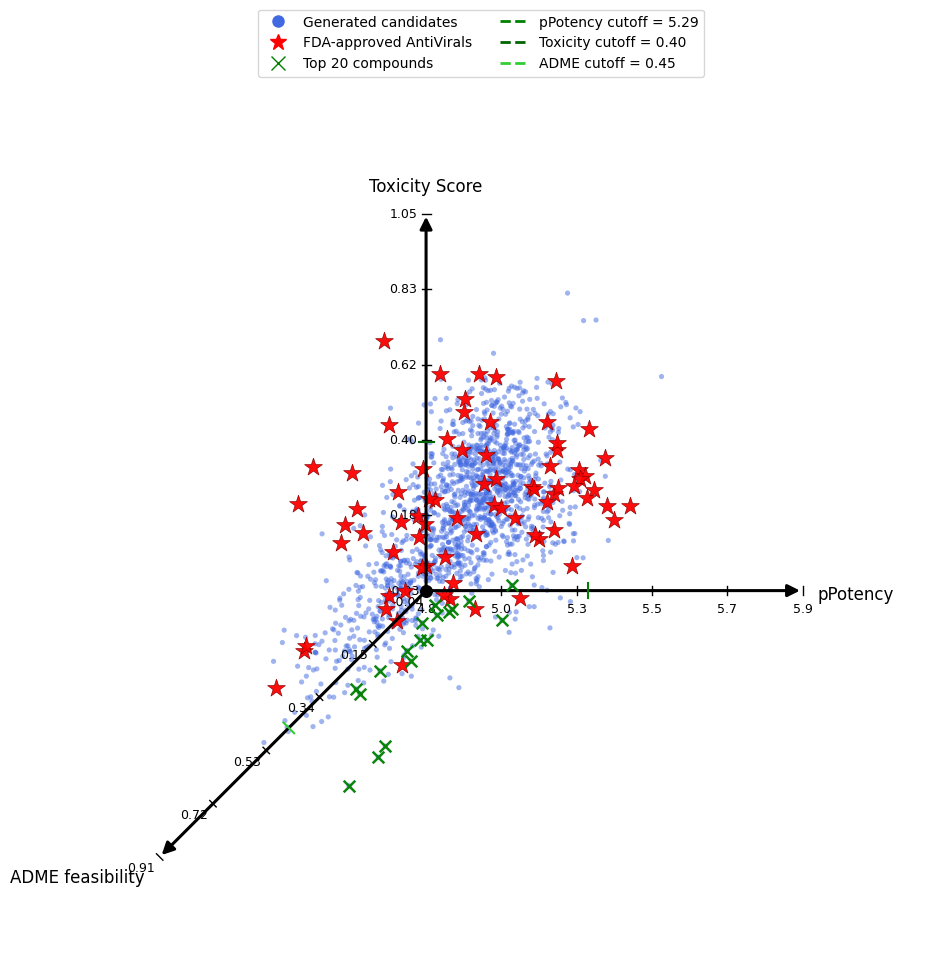

In [117]:
xCol, yCol, zCol = "pPotency_prediction", "coreToxicityScore", "ADMEFeasibility"
cols = [xCol, yCol, zCol]

allPlotDF = cand3DDF[cols][np.isfinite(cand3DDF[cols]).all(axis=1)].copy()
refPlotDF = refScoreDF[cols][np.isfinite(refScoreDF[cols]).all(axis=1)].copy()
topPlotDF = top20_3D_DF[cols][np.isfinite(top20_3D_DF[cols]).all(axis=1)].copy()

def paddedRange(arr, frac=0.05):
    lo, hi = np.nanmin(arr), np.nanmax(arr)
    pad = (hi - lo) * frac if (hi - lo) > 0 else 1.0
    return lo - pad, hi + pad

combined          = pd.concat([allPlotDF, refPlotDF, topPlotDF])
(X_MIN, X_MAX), (Y_MIN, Y_MAX), (Z_MIN, Z_MAX) = [paddedRange(combined[c]) for c in cols]

O  = np.zeros(2)
UX = np.array([1.0, 0.0])
UY = np.array([0.0, 1.0])
UZ = np.array([math.cos(math.radians(225)), math.sin(math.radians(225))])

def project(x, y, z):
    return O + ((x-X_MIN)/(X_MAX-X_MIN))*UX + ((y-Y_MIN)/(Y_MAX-Y_MIN))*UY + ((z-Z_MIN)/(Z_MAX-Z_MIN))*UZ

def projectDF(df):
    pts = np.array([project(r[xCol], r[yCol], r[zCol]) for _, r in df.iterrows()])
    return pts[:, 0], pts[:, 1]

allCX, allCY = projectDF(allPlotDF)
refCX, refCY = projectDF(refPlotDF)
topCX, topCY = projectDF(topPlotDF)

TIP_X, TIP_Y, TIP_Z = O + UX, O + UY, O + UZ

fig, ax = plt.subplots(figsize=(12, 11), facecolor="white")
ax.set(facecolor="white", aspect="equal")
ax.axis("off")

for tip in [TIP_X, TIP_Y, TIP_Z]:
    ax.annotate("", xy=tip, xytext=O, zorder=5,
                arrowprops=dict(arrowstyle="-|>", color="black", lw=2.2, mutation_scale=18))

ax.scatter(*O, s=70, c="black", zorder=6)

def drawTicks(unitVec, valMin, valMax, offset, nTicks=5, fmt="{:.2f}"):
    perp = np.array([unitVec[1], -unitVec[0]])
    perp /= np.linalg.norm(perp)
    for i in range(nTicks + 1):
        t, pos = i / nTicks, O + (i / nTicks) * unitVec
        ax.plot(*zip(pos - 0.012*perp, pos + 0.012*perp), color="black", lw=1.0, zorder=5)
        ax.text(*(pos + offset), fmt.format(valMin + t*(valMax-valMin)), fontsize=9, ha="center", va="center")

drawTicks(UX, X_MIN, X_MAX, np.array([ 0.00, -0.05]), fmt="{:.1f}")
drawTicks(UY, Y_MIN, Y_MAX, np.array([-0.06,  0.00]))
drawTicks(UZ, Z_MIN, Z_MAX, np.array([-0.05, -0.03]))

ax.scatter(allCX, allCY, color="royalblue", s=14,  alpha=0.5,  edgecolors="none", zorder=2)
ax.scatter(refCX, refCY, color="red",       s=180, alpha=0.95, marker="*", edgecolors="darkred", linewidths=0.5, zorder=4)
ax.scatter(topCX, topCY, color="green",     s=70,  alpha=0.95, marker="x", linewidths=1.8, zorder=5)

xCut, yCut, zCut = topPlotDF[xCol].min(), topPlotDF[yCol].max(), topPlotDF[zCol].min()
tickLen = 0.02

UZ_perp = np.array([-UZ[1], UZ[0]]) 
UZ_perp /= np.linalg.norm(UZ_perp)           
zPt = O + ((zCut-Z_MIN)/(Z_MAX-Z_MIN))*UZ 

for pt, color, dx, dy in [
    (O + ((xCut-X_MIN)/(X_MAX-X_MIN))*UX, "green", 0, tickLen),
    (O + ((yCut-Y_MIN)/(Y_MAX-Y_MIN))*UY, "darkgreen",  tickLen, 0),
]:
    ax.plot([pt[0]-dx, pt[0]+dx], [pt[1]-dy, pt[1]+dy], color=color, lw=1.5, zorder=5)

# Z cutoff tick perpendicular to UZ
ax.plot(
    [zPt[0] - tickLen*UZ_perp[0], zPt[0] + tickLen*UZ_perp[0]],
    [zPt[1] - tickLen*UZ_perp[1], zPt[1] + tickLen*UZ_perp[1]],
    color="limegreen", lw=1.5, zorder=5
)

ax.text(TIP_X[0]+0.04, TIP_X[1]-0.01, "pPotency",            fontsize=12, ha="left",   va="center")
ax.text(TIP_Y[0],      TIP_Y[1]+0.05, "Toxicity Score",  fontsize=12, ha="center", va="bottom")
ax.text(TIP_Z[0]-0.04, TIP_Z[1]-0.03, "ADME feasibility",    fontsize=12, ha="right",  va="top")

allPx = np.concatenate([allCX, refCX, topCX, [TIP_X[0], TIP_Y[0], TIP_Z[0]]])
allPy = np.concatenate([allCY, refCY, topCY, [TIP_X[1], TIP_Y[1], TIP_Z[1]]])
ax.set_xlim(allPx.min()-0.3, allPx.max()+0.3)
ax.set_ylim(allPy.min()-0.3, allPy.max()+0.3)

handles = [
    mlines.Line2D([], [], color="royalblue", marker="o", linestyle="None", markersize=8, label="Generated candidates"),
    mlines.Line2D([], [], color="red",       marker="*", linestyle="None", markersize=12, label="FDA-approved AntiVirals"),
    mlines.Line2D([], [], color="green",     marker="x", linestyle="None", markersize=10, label="Top 20 compounds"),
    mlines.Line2D([], [], color="green",     linestyle="--", lw=2, label=f"pPotency cutoff = {xCut:.2f}"),
    mlines.Line2D([], [], color="darkgreen", linestyle="--", lw=2, label=f"Toxicity cutoff = {yCut:.2f}"),
    mlines.Line2D([], [], color="limegreen", linestyle="--", lw=2, label=f"ADME cutoff = {zCut:.2f}"),
]
ax.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig(os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_adme_DORAnetGenerated_Antivirals_wDoraxgb.svg"), format="svg", dpi=600, bbox_inches="tight", facecolor="white")
plt.savefig(os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_adme_DORAnetGenerated_Antivirals_wDoraxgb.png"), format="png", dpi=600, bbox_inches="tight", facecolor="white")
plt.show()

### 18. Save the top 20 candidates

In [118]:
top20_2D_cols = ["Top20Rank_2D", "SMILES", "pPotency_prediction", "pPotency_std", "pPotency_lower_95CI", "pPotency_upper_95CI", "coreToxicityScore", "ToxicitySafety", "OverallPriority2D", "QED"]
top20_3D_cols = ["Top20Rank_3D", "SMILES", "pPotency_prediction", "pPotency_std", "pPotency_lower_95CI", "pPotency_upper_95CI", "coreToxicityScore", "ADMEFeasibility", "ToxicitySafety", "OverallPriority3D", "QED"]

toxicityTop20Path = os.path.join(saveDir, f"{target_organism}_potency_coreToxicity_top20_DORAnetGenerated_Antivirals.csv")
admetTop20Path    = os.path.join(saveDir, f"{target_organism}_potency_coreToxicity_adme_top20_DORAnetGenerated_Antivirals.csv")

top20_2D_DF[top20_2D_cols[1:]].to_csv(toxicityTop20Path, index=False)
top20_3D_DF[top20_3D_cols[1:]].to_csv(admetTop20Path,    index=False)

print(f"Saved:\n- {toxicityTop20Path}\n- {admetTop20Path}")

#display(top20_2D_DF[top20_2D_cols])
#display(top20_3D_DF[top20_3D_cols])

Saved:
- /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB/combinedEbolaVirus_potency_coreToxicity_top20_DORAnetGenerated_Antivirals.csv
- /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB/combinedEbolaVirus_potency_coreToxicity_adme_top20_DORAnetGenerated_Antivirals.csv


# How to use FDA withdrawn drug candidates to reltively score `Toxicity`

### Read `ADMET` endpoints for the `withdrawn` drugs from `Drugbank`

In [119]:
drugBankDrugWithdrawnDataDF_wADMET = pd.read_csv(dataDir + '/Toxicity/DrugBank/drugBankDrugWithdrawnDataDF_wADMET.csv')
drugBankDrugWithdrawnDataDF_wADMET

,Unnamed: 0,DrugBank ID,Drug Groups,Name,Formula,CAS Number,InChIKey,ChEMBL ID,SMILES,AMES,...,PAMPA_NCATS,Bioavailability_Ma,CYP1A2_Veith,CYP2C19_Veith,CYP2C9_Substrate_CarbonMangels,CYP2C9_Veith,CYP2D6_Substrate_CarbonMangels,CYP2D6_Veith,CYP3A4_Substrate_CarbonMangels,CYP3A4_Veith
0,0,DB00106,approved; investigational; withdrawn,Abarelix,C72H95ClN14O14,183552-38-7,AIWRTTMUVOZGPW-HSPKUQOVSA-N,CHEMBL1252,CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...,0.244807,...,0.463332,0.605704,0.017399,0.263449,0.207183,0.100211,0.232910,0.125635,0.925135,0.938593
1,1,DB00131,approved; investigational; nutraceutical; with...,Adenosine phosphate,C10H14N5O7P,61-19-8,UDMBCSSLTHHNCD-KQYNXXCUSA-N,CHEMBL752,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)O)[C@@H]...,0.215953,...,0.027663,0.470261,0.000746,0.008154,0.066037,0.003312,0.010593,0.036415,0.061753,0.000318
2,2,DB00132,approved; investigational; nutraceutical; with...,alpha-Linolenic acid,C18H30O2,463-40-1,DTOSIQBPPRVQHS-PDBXOOCHSA-N,CHEMBL8739,CC/C=C\C/C=C\C/C=C\CCCCCCCC(=O)O,0.494518,...,0.737525,0.696307,0.166940,0.244747,0.189303,0.188501,0.161169,0.020346,0.343310,0.108636
3,3,DB00138,approved; investigational; nutraceutical; with...,Cystine,C6H12N2O4S2,56-89-3,LEVWYRKDKASIDU-IMJSIDKUSA-N,CHEMBL590540,N[C@@H](CSSC[C@H](N)C(=O)O)C(=O)O,0.678855,...,0.086299,0.860139,0.031484,0.182946,0.114121,0.124554,0.160284,0.026472,0.090174,0.046522
4,4,DB00150,approved; investigational; nutraceutical; with...,Tryptophan,C11H12N2O2,73-22-3,QIVBCDIJIAJPQS-VIFPVBQESA-N,CHEMBL54976,N[C@@H](Cc1c[nH]c2ccccc12)C(=O)O,0.227781,...,0.227191,0.956495,0.102633,0.029928,0.428593,0.004736,0.231113,0.026281,0.171291,0.030738
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
604,604,DB19382,approved; withdrawn,Benzoylpas,C14H11NO4,13898-58-3,GNZCRYWFWKFIDM-UHFFFAOYSA-N,CHEMBL1487804,O=C(Nc1ccc(C(=O)O)c(O)c1)c1ccccc1,0.250689,...,0.094615,0.934835,0.072102,0.036693,0.347887,0.206038,0.039468,0.026548,0.103570,0.006168
605,605,DB19383,approved; withdrawn,Pentapiperium,C19H30NO2,26372-86-1,WSWDKMFWJOALEW-UHFFFAOYSA-N,CHEMBL2111014,CCC(C)C(C(=O)OC1CC[N+](C)(C)CC1)c1ccccc1,0.010421,...,0.845728,0.240165,0.000727,0.004731,0.050183,0.001061,0.538791,0.215035,0.560323,0.001474
606,606,DB20118,approved; withdrawn,Dichlorotetrafluoroethane,C2Cl2F4,76-14-2,DDMOUSALMHHKOS-UHFFFAOYSA-N,CHEMBL325436,FC(F)(Cl)C(F)(F)Cl,0.013408,...,0.984755,0.942265,0.243439,0.567955,0.310735,0.045990,0.262644,0.001311,0.650809,0.001634
607,607,DB20138,approved; withdrawn,Tribromsalan,C13H8Br3NO2,87-10-5,KVSKGMLNBAPGKH-UHFFFAOYSA-N,CHEMBL24944,O=C(Nc1ccc(Br)cc1)c1cc(Br)cc(Br)c1O,0.139711,...,0.753677,0.839571,0.949634,0.672943,0.431539,0.900576,0.232279,0.186494,0.658334,0.171204


In [120]:
fdaApprovedDF = drugBankDrug_FDAapproved_AntiViral_wART_wADMET.copy()
withdrawnDF = drugBankDrugWithdrawnDataDF_wADMET.copy()
generatedScoreDF = Ebola_wART_DORAnetGenerated_AntiviralsDataset_predicted_all_wToxicity.copy()

In [121]:
toxicityCols = coreToxicityCols + mechanisticAlertCols

toxicityCols = [
    col for col in toxicityCols
    if col in fdaApprovedDF.columns
    and col in withdrawnDF.columns
    and col in generatedScoreDF.columns
]

print(f"Using {len(toxicityCols)} toxicity endpoints:")
print(toxicityCols)

for DF in [fdaApprovedDF, withdrawnDF, generatedScoreDF]:
    for col in toxicityCols:
        DF[col] = pd.to_numeric(DF[col], errors="coerce")

Using 19 toxicity endpoints:
['AMES', 'hERG', 'DILI', 'ClinTox', 'Carcinogens_Lagunin', 'Skin_Reaction', 'LD50_Zhu', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53', 'NR-AR-LBD', 'NR-AR', 'NR-AhR', 'NR-Aromatase', 'NR-ER-LBD', 'NR-ER', 'NR-PPAR-gamma']


In [122]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -50, 50)))


def robustScale(values, eps=1e-8):
    values = pd.Series(values).dropna()
    iqr = values.quantile(0.75) - values.quantile(0.25)

    if np.isfinite(iqr) and iqr > eps:
        return iqr / 1.349

    std = values.std()
    if np.isfinite(std) and std > eps:
        return std

    return 1.0


def weightedGeoMean(DF, cols, weightsDict=None, eps=1e-6):
    validCols = [col for col in cols if col in DF.columns]

    X = DF[validCols].clip(eps, 1.0)

    if weightsDict is None:
        weights = np.ones(len(validCols))
    else:
        baseNames = [
            col.replace("_Safety", "")
               .replace("_GeneratedCalibrated", "")
               .replace("_WithdrawnRelative", "")
            for col in validCols
        ]
        weights = np.array([weightsDict.get(name, 0.0) for name in baseNames], dtype=float)

        if weights.sum() == 0:
            weights = np.ones(len(validCols))

    weights = weights / weights.sum()

    return np.exp(np.sum(np.log(X) * weights, axis=1))

### Score FDA drugs against withdrawn-drug toxicity distribution

In [123]:
def percentileRiskRelativeToWithdrawn(values, withdrawnValues, higherIsMoreToxic=True, eps=1e-6):
    withdrawnValues = pd.Series(withdrawnValues).dropna().astype(float).sort_values().values
    values = pd.Series(values).astype(float)

    if len(withdrawnValues) == 0:
        return pd.Series(np.nan, index=values.index)

    percentiles = np.searchsorted(withdrawnValues, values.values, side="right") / len(withdrawnValues)

    if higherIsMoreToxic:
        risk = percentiles
    else:
        risk = 1.0 - percentiles

    return pd.Series(risk, index=values.index).clip(eps, 1.0 - eps)


def addWithdrawnRelativeToxicity(DF, withdrawnDF, toxicityCols):
    DF = DF.copy()

    for col in toxicityCols:
        higherIsMoreToxic = col != "LD50_Zhu"

        DF[f"{col}_WithdrawnRelativeRisk"] = percentileRiskRelativeToWithdrawn(
            DF[col],
            withdrawnDF[col],
            higherIsMoreToxic=higherIsMoreToxic,
        )

        DF[f"{col}_WithdrawnRelativeSafety"] = (
            1.0 - DF[f"{col}_WithdrawnRelativeRisk"]
        )

    safetyCols = [f"{col}_WithdrawnRelativeSafety" for col in toxicityCols]

    DF["WithdrawnRelativeToxicitySafety"] = weightedGeoMean(
        DF,
        safetyCols,
        weightsDict=None,
    )

    DF["WithdrawnRelativeCoreToxicityScore"] = (
        1.0 - DF["WithdrawnRelativeToxicitySafety"]
    )

    return DF

In [124]:
fdaWithdrawnRelativeScoreDF = addWithdrawnRelativeToxicity(
    fdaApprovedDF,
    withdrawnDF,
    toxicityCols,
)

withdrawnSelfRelativeScoreDF = addWithdrawnRelativeToxicity(
    withdrawnDF,
    withdrawnDF,
    toxicityCols,
)

fdaWithdrawnRelativeScoreDF.head()

,SMILES,ATC_code,Drug_Type,source_DataBase,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,...,NR-Aromatase_WithdrawnRelativeRisk,NR-Aromatase_WithdrawnRelativeSafety,NR-ER-LBD_WithdrawnRelativeRisk,NR-ER-LBD_WithdrawnRelativeSafety,NR-ER_WithdrawnRelativeRisk,NR-ER_WithdrawnRelativeSafety,NR-PPAR-gamma_WithdrawnRelativeRisk,NR-PPAR-gamma_WithdrawnRelativeSafety,WithdrawnRelativeToxicitySafety,WithdrawnRelativeCoreToxicityScore
0,Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1,J05AF;J05AR,antiviral,FDA_Antivirals,5.237696,0.541353,4.176643,6.298748,0.000006,5.026341e-07,...,0.914614,0.085386,0.440066,0.559934,0.737274,0.262726,0.610837,0.389163,0.237696,0.762304
1,Nc1nc(=O)c2ncn(COCCO)c2[nH]1,J05AB,antiviral,FDA_Antivirals,5.037581,0.543129,3.973048,6.102114,0.000009,7.904713e-07,...,0.275862,0.724138,0.159278,0.840722,0.096880,0.903120,0.187192,0.812808,0.510912,0.489088
2,CC(C)(C)C(=O)OCOP(=O)(COCCn1cnc2c(N)ncnc21)OCO...,J05AF,antiviral,FDA_Antivirals,5.233644,0.545209,4.165035,6.302253,0.000006,4.985938e-07,...,0.986864,0.013136,0.878489,0.121511,0.229885,0.770115,0.507389,0.492611,0.273221,0.726779
3,CC(C)CN(C[C@@H](O)[C@H](Cc1ccccc1)NC(=O)O[C@H]...,J05AE,antiviral,FDA_Antivirals,5.175844,0.542325,4.112886,6.238802,0.000007,5.770297e-07,...,0.778325,0.221675,0.518883,0.481117,0.270936,0.729064,0.801314,0.198686,0.329563,0.670437
4,C=C[C@@H]1C[C@]1(NC(=O)[C@@H]1C[C@@H](Oc2ncc(O...,J05AP,antiviral,FDA_Antivirals,5.626048,0.541898,4.563928,6.688167,0.000002,2.050374e-07,...,0.837438,0.162562,0.522167,0.477833,0.213465,0.786535,0.850575,0.149425,0.301179,0.698821


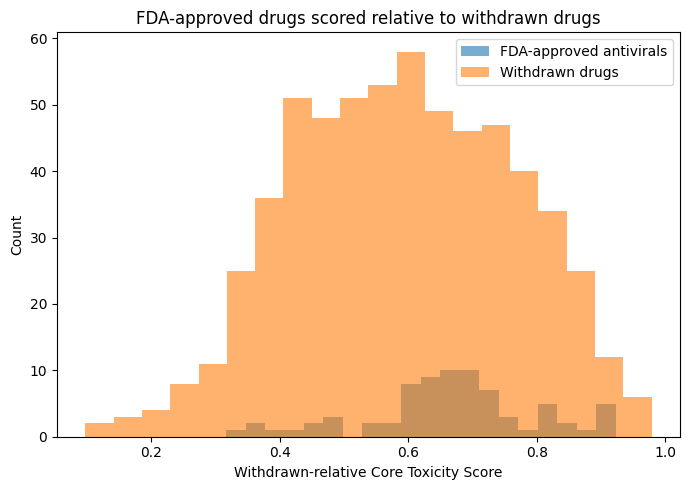

In [125]:
plt.figure(figsize=(7, 5))

plt.hist(
    fdaWithdrawnRelativeScoreDF["WithdrawnRelativeCoreToxicityScore"].dropna(),
    bins=20,
    alpha=0.6,
    label="FDA-approved antivirals",
)

plt.hist(
    withdrawnSelfRelativeScoreDF["WithdrawnRelativeCoreToxicityScore"].dropna(),
    bins=20,
    alpha=0.6,
    label="Withdrawn drugs",
)

plt.xlabel("Withdrawn-relative Core Toxicity Score")
plt.ylabel("Count")
plt.title("FDA-approved drugs scored relative to withdrawn drugs")
plt.legend()
plt.tight_layout()
plt.show()

### Generated compounds calibrated between FDA and withdrawn drugs

In [126]:
def learnFdaWithdrawnCalibration(fdaDF, withdrawnDF, toxicityCols):
    calibration = {}

    for col in toxicityCols:
        fdaVals = fdaDF[col].dropna()
        withdrawnVals = withdrawnDF[col].dropna()

        if len(fdaVals) < 3 or len(withdrawnVals) < 3:
            continue

        fdaMedian = fdaVals.median()
        withdrawnMedian = withdrawnVals.median()
        combinedVals = pd.concat([fdaVals, withdrawnVals])

        center = 0.5 * (fdaMedian + withdrawnMedian)
        scale = robustScale(combinedVals)

        if col == "LD50_Zhu":
            higherIsMoreToxic = False
        else:
            higherIsMoreToxic = withdrawnMedian >= fdaMedian

        separation = abs(withdrawnMedian - fdaMedian) / scale

        calibration[col] = {
            "fdaMedian": fdaMedian,
            "withdrawnMedian": withdrawnMedian,
            "center": center,
            "scale": scale,
            "higherIsMoreToxic": higherIsMoreToxic,
            "separation": separation,
        }

    return calibration


toxicityCalibration = learnFdaWithdrawnCalibration(
    fdaApprovedDF,
    withdrawnDF,
    toxicityCols,
)

calibrationDF = pd.DataFrame(toxicityCalibration).T
calibrationDF

,fdaMedian,withdrawnMedian,center,scale,higherIsMoreToxic,separation
AMES,0.383575,0.168905,0.27624,0.247027,False,0.869015
hERG,0.518539,0.270876,0.394708,0.494058,False,0.501283
DILI,0.881626,0.388564,0.635095,0.537594,False,0.917165
ClinTox,0.246387,0.077688,0.162037,0.162882,False,1.035709
Carcinogens_Lagunin,0.13842,0.177559,0.15799,0.187943,True,0.20825
Skin_Reaction,0.202115,0.491459,0.346787,0.336104,True,0.860877
LD50_Zhu,2.80128,2.504244,2.652762,0.585541,False,0.507285
SR-ARE,0.256918,0.10347,0.180194,0.21641,False,0.709062
SR-ATAD5,0.018997,0.00445,0.011724,0.01924,False,0.756081
SR-HSE,0.018488,0.012983,0.015735,0.031247,False,0.176183


In [127]:
def computeCalibrationWeights(calibration):
    weightDF = pd.DataFrame(calibration).T.copy()

    rawWeights = (
        weightDF["separation"]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
    )

    if rawWeights.sum() == 0:
        rawWeights[:] = 1.0

    weights = rawWeights / rawWeights.sum()
    return weights.to_dict()


toxicityWeights = computeCalibrationWeights(toxicityCalibration)

toxicityWeightDF = pd.DataFrame(
    {
        "endpoint": list(toxicityWeights.keys()),
        "weight": list(toxicityWeights.values()),
    }
).sort_values("weight", ascending=False)

toxicityWeightDF

,endpoint,weight
11,SR-p53,0.113161
3,ClinTox,0.101427
2,DILI,0.089818
0,AMES,0.085103
5,Skin_Reaction,0.084306
8,SR-ATAD5,0.074043
7,SR-ARE,0.069438
15,NR-Aromatase,0.062991
10,SR-MMP,0.061925
18,NR-PPAR-gamma,0.059883


In [128]:
def addGeneratedCalibratedToxicity(DF, calibration):
    DF = DF.copy()

    for col, params in calibration.items():
        x = DF[col].astype(float)
        center = params["center"]
        scale = params["scale"]

        if params["higherIsMoreToxic"]:
            risk = sigmoid((x - center) / scale)
        else:
            risk = sigmoid((center - x) / scale)

        DF[f"{col}_GeneratedCalibratedRisk"] = risk.clip(1e-6, 1.0 - 1e-6)
        DF[f"{col}_GeneratedCalibratedSafety"] = (
            1.0 - DF[f"{col}_GeneratedCalibratedRisk"]
        )

    safetyCols = [
        f"{col}_GeneratedCalibratedSafety"
        for col in calibration.keys()
    ]

    DF["ToxicitySafety"] = weightedGeoMean(
        DF,
        safetyCols,
        weightsDict=toxicityWeights,
    )

    DF["coreToxicityScore"] = 1.0 - DF["ToxicitySafety"]

    return DF

In [129]:
generatedScoreDF = addGeneratedCalibratedToxicity(
    generatedScoreDF,
    toxicityCalibration,
)

fdaApprovedScoreDF = addGeneratedCalibratedToxicity(
    fdaApprovedDF,
    toxicityCalibration,
)

withdrawnScoreDF = addGeneratedCalibratedToxicity(
    withdrawnDF,
    toxicityCalibration,
)

display(generatedScoreDF.head())

,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,molecular_weight,logP,...,NR-Aromatase_GeneratedCalibratedRisk,NR-Aromatase_GeneratedCalibratedSafety,NR-ER-LBD_GeneratedCalibratedRisk,NR-ER-LBD_GeneratedCalibratedSafety,NR-ER_GeneratedCalibratedRisk,NR-ER_GeneratedCalibratedSafety,NR-PPAR-gamma_GeneratedCalibratedRisk,NR-PPAR-gamma_GeneratedCalibratedSafety,ToxicitySafety,coreToxicityScore
0,O=c1[nH]cnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C...,5.459329,0.540618,4.399719,6.518939,0.000003,3.027338e-07,0.000040,268.229,-2.2689,...,0.600589,0.399411,0.479508,0.520492,0.488482,0.511518,0.606562,0.393438,0.493179,0.506821
1,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OP(=O)(O...,5.336136,0.541734,4.274338,6.397935,0.000005,4.000046e-07,0.000053,507.182,-1.6290,...,0.588522,0.411478,0.141660,0.858340,0.790641,0.209359,0.631101,0.368899,0.427012,0.572988
2,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,5.346715,0.540573,4.287192,6.406237,0.000005,3.924304e-07,0.000052,744.417,-2.8989,...,0.541442,0.458558,0.044955,0.955045,0.925203,0.074797,0.629765,0.370235,0.426699,0.573301
3,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,5.356202,0.540410,4.296998,6.415405,0.000004,3.842330e-07,0.000050,745.425,-2.5694,...,0.393631,0.606369,0.007928,0.992072,0.864759,0.135241,0.622296,0.377704,0.478598,0.521402
4,Nc1ncnc2c1ncn2[C@@H]1O[C@H](COP(=O)(O)OS(=O)(=...,5.284823,0.541526,4.223432,6.346214,0.000005,4.505950e-07,0.000060,507.267,-1.9189,...,0.574732,0.425268,0.189523,0.810477,0.818601,0.181399,0.628706,0.371294,0.432900,0.567100


In [130]:
plotDF = generatedScoreDF[
    np.isfinite(generatedScoreDF["pPotency_prediction"]) &
    np.isfinite(generatedScoreDF["coreToxicityScore"])
].copy()

plotDF["potencyDes"] = plotDF["pPotency_prediction"].rank(pct=True)
plotDF["toxicityDes"] = 1 - plotDF["coreToxicityScore"].rank(pct=True)
plotDF["top20PriorityScore"] = np.sqrt(
    plotDF["potencyDes"].clip(1e-6) * plotDF["toxicityDes"].clip(1e-6)
)

top20DF = plotDF.sort_values("top20PriorityScore", ascending=False).head(20).copy()

top20PotencyCutoff = top20DF["pPotency_prediction"].min()
top20ToxicityCutoff = top20DF["coreToxicityScore"].max()

p, ps = top20DF["pPotency_prediction"], top20DF["pPotency_std"]
t = top20DF["coreToxicityScore"]
i_min, i_max = p.idxmin(), p.idxmax()

print(f"Top 20 pPotency cutoff: {top20PotencyCutoff:.3f}")
print(f"Top 20 toxicity cutoff: {top20ToxicityCutoff:.3f}")
print(f"pPotency range: {p.loc[i_min]:.3f} ± {ps.loc[i_min]:.3f}  -  {p.loc[i_max]:.3f} ± {ps.loc[i_max]:.3f}")
print(f"pIC50 range:    {p.loc[i_min]:.3f} ± {ps.loc[i_min]:.3f}  -  {p.loc[i_max]:.3f} ± {ps.loc[i_max]:.3f}")
print(f"Toxicity range: {t.min():.3f} to {t.max():.3f}")

top20Cols = [
    "SMILES", "pPotency_prediction", "pPotency_std", "pPotency_lower_95CI", "pPotency_upper_95CI",
    "coreToxicityScore", "ToxicitySafety", "potencyDes", "toxicityDes", "top20PriorityScore", "QED"
]

top20Path = os.path.join(saveDir, f"{target_organism}_potency_coreToxicity_top20_BasidalinPrecursor.csv")
top20DF[[c for c in top20Cols if c in top20DF.columns]].to_csv(top20Path, index=False)
print(f"Saved: {top20Path}")

Top 20 pPotency cutoff: 5.340
Top 20 toxicity cutoff: 0.434
pPotency range: 5.340 ± 0.540  -  5.525 ± 0.541
pIC50 range:    5.340 ± 0.540  -  5.525 ± 0.541
Toxicity range: 0.312 to 0.434
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB/combinedEbolaVirus_potency_coreToxicity_top20_BasidalinPrecursor.csv


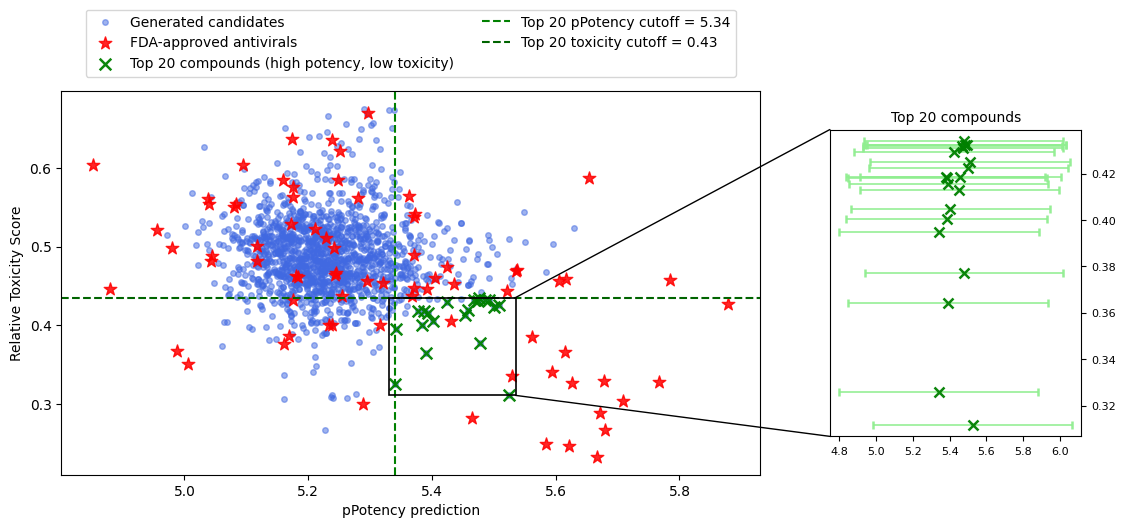

In [131]:
xDisplay = top20PotencyCutoff
yDisplay = top20ToxicityCutoff

fig, ax = plt.subplots(figsize=(10, 6))

# Main plot (no error bars)
ax.scatter(plotDF["pPotency_prediction"], plotDF["coreToxicityScore"],
           s=16, alpha=0.5, color="royalblue", label=f"Generated candidates")
ax.scatter(fdaApprovedScoreDF["pPotency_prediction"], fdaApprovedScoreDF["coreToxicityScore"],
           marker="*", s=90, alpha=0.85, color="red", label="FDA-approved antivirals")
ax.scatter(top20DF["pPotency_prediction"], top20DF["coreToxicityScore"],
           marker="x", s=70, linewidths=1.8, alpha=0.95, color="green",
           label="Top 20 compounds (high potency, low toxicity)")

ax.axvline(xDisplay, linestyle="--", linewidth=1.5, color="green",
           label=f"Top 20 pPotency cutoff = {xDisplay:.2f}")
ax.axhline(yDisplay, linestyle="--", linewidth=1.5, color="darkgreen",
           label=f"Top 20 toxicity cutoff = {yDisplay:.2f}")

ax.set_xlabel("pPotency prediction")
ax.set_ylabel("Relative Toxicity Score")
#ax.set_title("High-potency, low-toxicity candidate prioritization")


# ---------- small box on main plot ----------
bx1 = top20DF["pPotency_prediction"].min() - 0.01
bx2 = top20DF["pPotency_prediction"].max() + 0.01
by1 = top20DF["coreToxicityScore"].min() - 0.001
by2 = top20DF["coreToxicityScore"].max() + 0.001

small_box = patches.Rectangle((bx1, by1), bx2 - bx1, by2 - by1,
                              fill=False, ec="k", lw=1.2, ls="-", zorder=6)
ax.add_patch(small_box)

# ---------- inset limits (bigger; include full error bars) ----------
x1 = (top20DF["pPotency_prediction"] - top20DF["pPotency_std"]).min() - 0.05
x2 = (top20DF["pPotency_prediction"] + top20DF["pPotency_std"]).max() + 0.05
y1 = top20DF["coreToxicityScore"].min() - 0.005
y2 = top20DF["coreToxicityScore"].max() + 0.005

axins = inset_axes(
    ax, width="36%", height="80%",
    loc="lower left", bbox_to_anchor=(1.1, 0.10, 1, 1),
    bbox_transform=ax.transAxes, borderpad=0
)

axins.errorbar(
    top20DF["pPotency_prediction"], top20DF["coreToxicityScore"],
    xerr=top20DF["pPotency_std"].values,
    fmt="x", color="green", ecolor="lightgreen",
    elinewidth=1.2, capsize=3, capthick=1.2,
    markersize=7, markeredgewidth=1.8, alpha=0.95
)
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)
axins.set_title("Top 20 compounds", fontsize=10)
axins.tick_params(labelsize=8)
axins.yaxis.tick_right()
axins.yaxis.set_label_position("right")

# ---------- connect: right corners of small box -> left corners of inset ----------
con_top = ConnectionPatch(
    xyA=(bx2, by2), coordsA=ax.transData,      # main: top-right
    xyB=(x1, y2),  coordsB=axins.transData,    # inset: top-left
    color="k", lw=1.0
)
con_bot = ConnectionPatch(
    xyA=(bx2, by1), coordsA=ax.transData,      # main: bottom-right
    xyB=(x1, y1),  coordsB=axins.transData,    # inset: bottom-left
    color="k", lw=1.0
)

fig.add_artist(con_top)
fig.add_artist(con_bot)

ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=True)
plt.tight_layout(rect=[0, 0, 0.78, 0.90])

plt.savefig(os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_candidates.svg"),format="svg", dpi=600, bbox_inches="tight")
plt.savefig(os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_candidates.png"),format="png", dpi=600, bbox_inches="tight")
plt.show()

### Plot: `high pPotency`, `low Toxicity Score`, `high ADME feasibility`

In [132]:
# =========================================================
# Compute ADMEFeasibility
# =========================================================

admeHigherIsBetterCols = [
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
]

admeLowerIsBetterCols = [
    "Pgp_Broccatelli",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Veith",
    "CYP2D6_Veith",
    "CYP3A4_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP3A4_Substrate_CarbonMangels",
]

admeHigherIsBetterCols = [
    col for col in admeHigherIsBetterCols
    if col in generatedScoreDF.columns and col in fdaApprovedDF.columns
]

admeLowerIsBetterCols = [
    col for col in admeLowerIsBetterCols
    if col in generatedScoreDF.columns and col in fdaApprovedDF.columns
]

admeCols = admeHigherIsBetterCols + admeLowerIsBetterCols

for DF in [generatedScoreDF, fdaApprovedScoreDF, fdaApprovedDF]:
    for col in admeCols:
        if col in DF.columns:
            DF[col] = pd.to_numeric(DF[col], errors="coerce")


def endpointDesirability(values, referenceValues, higherIsBetter=True, eps=1e-6):
    referenceValues = pd.Series(referenceValues).dropna().astype(float).sort_values().values
    values = pd.Series(values).astype(float)

    if len(referenceValues) == 0:
        return pd.Series(np.nan, index=values.index)

    percentiles = np.searchsorted(referenceValues, values.values, side="right") / len(referenceValues)

    if higherIsBetter:
        desirability = percentiles
    else:
        desirability = 1.0 - percentiles

    return pd.Series(desirability, index=values.index).clip(eps, 1.0)


def addADMEFeasibility(DF, referenceDF, admeHigherIsBetterCols, admeLowerIsBetterCols):
    DF = DF.copy()
    admeDesCols = []

    for col in admeHigherIsBetterCols:
        desCol = f"{col}_ADMESuitability"
        DF[desCol] = endpointDesirability(
            DF[col],
            referenceDF[col],
            higherIsBetter=True,
        )
        admeDesCols.append(desCol)

    for col in admeLowerIsBetterCols:
        desCol = f"{col}_ADMESuitability"
        DF[desCol] = endpointDesirability(
            DF[col],
            referenceDF[col],
            higherIsBetter=False,
        )
        admeDesCols.append(desCol)

    DF["ADMEFeasibility"] = np.exp(
        np.nanmean(np.log(DF[admeDesCols].clip(1e-6, 1.0)), axis=1)
    )

    return DF


generatedScoreDF = addADMEFeasibility(
    generatedScoreDF,
    fdaApprovedDF,
    admeHigherIsBetterCols,
    admeLowerIsBetterCols,
)

fdaApprovedScoreDF = addADMEFeasibility(
    fdaApprovedScoreDF,
    fdaApprovedDF,
    admeHigherIsBetterCols,
    admeLowerIsBetterCols,
)

print("ADMEFeasibility added.")
print(generatedScoreDF["ADMEFeasibility"].describe())

ADMEFeasibility added.
count    1474.000000
mean        0.508274
std         0.116261
min         0.029564
25%         0.440029
50%         0.512552
75%         0.594437
max         0.835075
Name: ADMEFeasibility, dtype: float64


In [133]:
plot3DDF = generatedScoreDF.copy()
plot3DDF = plot3DDF[
    np.isfinite(plot3DDF["pPotency_prediction"]) &
    np.isfinite(plot3DDF["coreToxicityScore"]) &
    np.isfinite(plot3DDF["ADMEFeasibility"])
].copy()

plot3DDF["potencyDes"]  = plot3DDF["pPotency_prediction"].rank(pct=True)          # higher better
plot3DDF["toxicityDes"] = 1 - plot3DDF["coreToxicityScore"].rank(pct=True)        # lower better
plot3DDF["admeDes"]     = plot3DDF["ADMEFeasibility"].rank(pct=True)               # higher better

plot3DDF["top20PriorityScore3D"] = (
    plot3DDF["potencyDes"].clip(1e-6) *
    plot3DDF["toxicityDes"].clip(1e-6) *
    plot3DDF["admeDes"].clip(1e-6)
) ** (1/3)

top20_ADMET = plot3DDF.sort_values("top20PriorityScore3D", ascending=False).head(20).copy()
top20_ADMET["Top20Rank_3D"] = range(1, len(top20_ADMET) + 1)

top20PotencyCutoff3D  = top20_ADMET["pPotency_prediction"].min()
top20ToxicityCutoff3D = top20_ADMET["coreToxicityScore"].max()
top20AdmeCutoff3D     = top20_ADMET["ADMEFeasibility"].min()

p, ps = top20_ADMET["pPotency_prediction"], top20_ADMET["pPotency_std"]
t, a  = top20_ADMET["coreToxicityScore"], top20_ADMET["ADMEFeasibility"]
i_min, i_max = p.idxmin(), p.idxmax()

print(f"Top 20 pPotency cutoff: {top20PotencyCutoff3D:.3f}")
print(f"Top 20 toxicity cutoff: {top20ToxicityCutoff3D:.3f}")
print(f"Top 20 ADME feasibility cutoff: {top20AdmeCutoff3D:.3f}\n")
print(f"pPotency range: {p.loc[i_min]:.3f} ± {ps.loc[i_min]:.3f}  -  {p.loc[i_max]:.3f} ± {ps.loc[i_max]:.3f}")
print(f"pIC50 range:    {p.loc[i_min]:.3f} ± {ps.loc[i_min]:.3f}  -  {p.loc[i_max]:.3f} ± {ps.loc[i_max]:.3f}")
print(f"Toxicity range: {t.min():.3f} to {t.max():.3f}")
print(f"ADME range:     {a.min():.3f} to {a.max():.3f}")

top20_3D_cols = [
    "Top20Rank_3D", "SMILES", "pPotency_prediction", "pPotency_std",
    "pPotency_lower_95CI", "pPotency_upper_95CI", "coreToxicityScore",
    "ADMEFeasibility", "ToxicitySafety", "top20PriorityScore3D", "QED"
]

admetTop20Path = os.path.join(saveDir, f"{target_organism}_potency_coreToxicity_adme_top20_BasidalinPrecursor.csv")
top20_ADMET[[c for c in top20_3D_cols if c in top20_ADMET.columns]].to_csv(admetTop20Path, index=False)
print(f"\nSaved: {admetTop20Path}")

Top 20 pPotency cutoff: 5.278
Top 20 toxicity cutoff: 0.464
Top 20 ADME feasibility cutoff: 0.580

pPotency range: 5.278 ± 0.542  -  5.509 ± 0.543
pIC50 range:    5.278 ± 0.542  -  5.509 ± 0.543
Toxicity range: 0.379 to 0.464
ADME range:     0.580 to 0.714

Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/combinedEbolaVirus_bestMACAW_allDB/combinedEbolaVirus_potency_coreToxicity_adme_top20_BasidalinPrecursor.csv


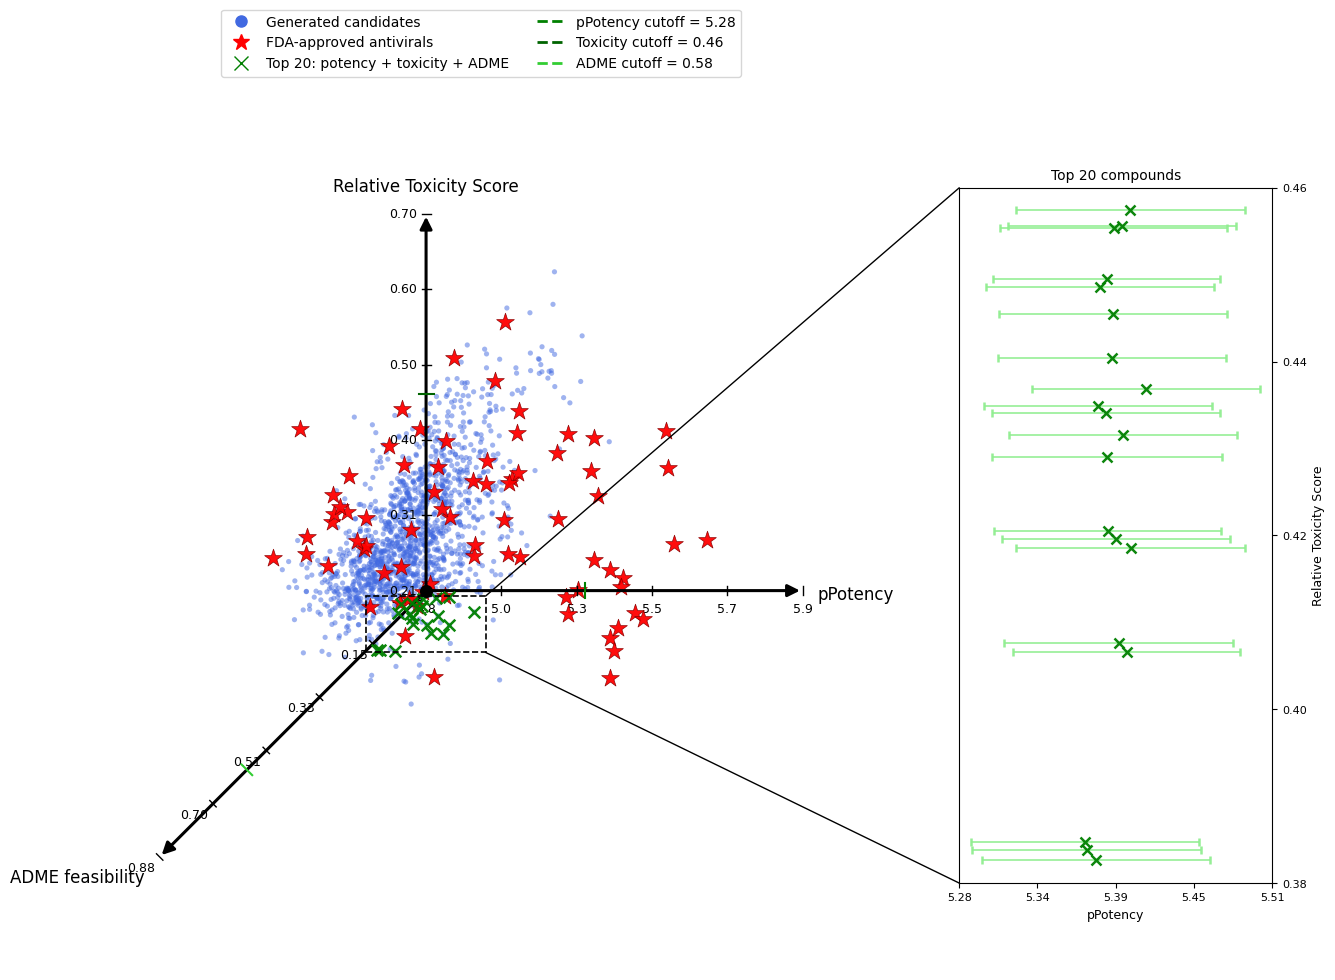

In [134]:
xCol, yCol, zCol = "pPotency_prediction", "coreToxicityScore", "ADMEFeasibility"
cols = [xCol, yCol, zCol]

allPlotDF = plot3DDF[cols][np.isfinite(plot3DDF[cols]).all(axis=1)].copy()
refPlotDF = (
    fdaApprovedScoreDF[cols][np.isfinite(fdaApprovedScoreDF[cols]).all(axis=1)].copy()
    if set(cols).issubset(fdaApprovedScoreDF.columns) else pd.DataFrame(columns=cols)
)
topPlotDF = top20_ADMET[cols][np.isfinite(top20_ADMET[cols]).all(axis=1)].copy()

def paddedRange(arr, frac=0.05):
    lo, hi = np.nanmin(arr), np.nanmax(arr)
    pad = (hi - lo) * frac if (hi - lo) > 0 else 1.0
    return lo - pad, hi + pad

combined = pd.concat([allPlotDF, refPlotDF, topPlotDF], ignore_index=True)
(X_MIN, X_MAX), (Y_MIN, Y_MAX), (Z_MIN, Z_MAX) = [paddedRange(combined[c]) for c in cols]

O  = np.zeros(2)
UX = np.array([1.0, 0.0])
UY = np.array([0.0, 1.0])
UZ = np.array([math.cos(math.radians(225)), math.sin(math.radians(225))])

def project(x, y, z):
    return O + ((x - X_MIN) / (X_MAX - X_MIN)) * UX + ((y - Y_MIN) / (Y_MAX - Y_MIN)) * UY + ((z - Z_MIN) / (Z_MAX - Z_MIN)) * UZ

def projectDF(df):
    if df.empty: return np.array([]), np.array([])
    pts = np.array([project(r[xCol], r[yCol], r[zCol]) for _, r in df.iterrows()])
    return pts[:, 0], pts[:, 1]

allCX, allCY = projectDF(allPlotDF)
refCX, refCY = projectDF(refPlotDF)
topCX, topCY = projectDF(topPlotDF)

TIP_X, TIP_Y, TIP_Z = O + UX, O + UY, O + UZ

fig, ax = plt.subplots(figsize=(12, 11), facecolor="white")
ax.set(facecolor="white", aspect="equal")
ax.axis("off")

for tip in [TIP_X, TIP_Y, TIP_Z]:
    ax.annotate("", xy=tip, xytext=O, zorder=5,
                arrowprops=dict(arrowstyle="-|>", color="black", lw=2.2, mutation_scale=18))
ax.scatter(*O, s=70, c="black", zorder=6)

def drawTicks(unitVec, valMin, valMax, offset, nTicks=5, fmt="{:.2f}"):
    perp = np.array([unitVec[1], -unitVec[0]])
    perp /= np.linalg.norm(perp)
    for i in range(nTicks + 1):
        t, pos = i / nTicks, O + (i / nTicks) * unitVec
        ax.plot(*zip(pos - 0.012 * perp, pos + 0.012 * perp), color="black", lw=1.0, zorder=5)
        ax.text(*(pos + offset), fmt.format(valMin + t * (valMax - valMin)), fontsize=9, ha="center", va="center")

drawTicks(UX, X_MIN, X_MAX, np.array([0.00, -0.05]), fmt="{:.1f}")
drawTicks(UY, Y_MIN, Y_MAX, np.array([-0.06, 0.00]))
drawTicks(UZ, Z_MIN, Z_MAX, np.array([-0.05, -0.03]))

ax.scatter(allCX, allCY, color="royalblue", s=14, alpha=0.5, edgecolors="none", zorder=2)
if len(refCX):
    ax.scatter(refCX, refCY, color="red", s=180, alpha=0.95, marker="*", edgecolors="darkred", linewidths=0.5, zorder=4)
ax.scatter(topCX, topCY, color="green", s=70, alpha=0.95, marker="x", linewidths=1.8, zorder=5)

xCut, yCut, zCut = topPlotDF[xCol].min(), topPlotDF[yCol].max(), topPlotDF[zCol].min()
tickLen = 0.02
UZ_perp = np.array([-UZ[1], UZ[0]])
UZ_perp /= np.linalg.norm(UZ_perp)
zPt = O + ((zCut - Z_MIN) / (Z_MAX - Z_MIN)) * UZ

for pt, color, dx, dy in [
    (O + ((xCut - X_MIN) / (X_MAX - X_MIN)) * UX, "green", 0, tickLen),
    (O + ((yCut - Y_MIN) / (Y_MAX - Y_MIN)) * UY, "darkgreen", tickLen, 0),
]:
    ax.plot([pt[0] - dx, pt[0] + dx], [pt[1] - dy, pt[1] + dy], color=color, lw=1.5, zorder=5)

ax.plot([zPt[0] - tickLen * UZ_perp[0], zPt[0] + tickLen * UZ_perp[0]],
        [zPt[1] - tickLen * UZ_perp[1], zPt[1] + tickLen * UZ_perp[1]],
        color="limegreen", lw=1.5, zorder=5)

ax.text(TIP_X[0] + 0.04, TIP_X[1] - 0.01, "pPotency", fontsize=12, ha="left", va="center")
ax.text(TIP_Y[0], TIP_Y[1] + 0.05, "Relative Toxicity Score", fontsize=12, ha="center", va="bottom")
ax.text(TIP_Z[0] - 0.04, TIP_Z[1] - 0.03, "ADME feasibility", fontsize=12, ha="right", va="top")

allPx = np.concatenate([allCX, refCX, topCX, [TIP_X[0], TIP_Y[0], TIP_Z[0]]])
allPy = np.concatenate([allCY, refCY, topCY, [TIP_X[1], TIP_Y[1], TIP_Z[1]]])
ax.set_xlim(allPx.min() - 0.3, allPx.max() + 0.3)
ax.set_ylim(allPy.min() - 0.3, allPy.max() + 0.3)

# ---- small box on main plot (tight around top20 points) ----
bx1, bx2 = topCX.min() - 0.03, topCX.max() + 0.03
by1, by2 = topCY.min() - 0.003, topCY.max() + 0.003
small_box = patches.Rectangle((bx1, by1), bx2 - bx1, by2 - by1,
                              fill=False, ec="k", lw=1.2, ls="--", zorder=6)
ax.add_patch(small_box)

# ---- inset outside right: bigger limits (include full projected ±1σ) ----
axins = inset_axes(
    ax, width="36%", height="80%",
    loc="lower left",
    bbox_to_anchor=(1.05, 0.10, 1, 1),
    bbox_transform=ax.transAxes,
    borderpad=0
)

xerr_proj = np.abs(top20_ADMET["pPotency_std"].values / (X_MAX - X_MIN) * UX[0])

x1 = np.min(topCX - xerr_proj) - 0.05
x2 = np.max(topCX + xerr_proj) + 0.05
y1 = topCY.min() - 0.005
y2 = topCY.max() + 0.005

axins.errorbar(
    topCX, topCY, xerr=xerr_proj,
    fmt="x", color="green", ecolor="lightgreen",
    elinewidth=1.2, capsize=3, capthick=1.2,
    markersize=7, markeredgewidth=1.8, alpha=0.95
)
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)

# inset ticks shown in original data scale
xt = np.linspace(x1, x2, 5)
xt_labels = np.linspace(top20_ADMET[xCol].min(), top20_ADMET[xCol].max(), 5)
axins.set_xticks(xt)
axins.set_xticklabels([f"{v:.2f}" for v in xt_labels], fontsize=8)
axins.set_xlabel("pPotency", fontsize=9)

yt = np.linspace(y1, y2, 5)
yt_labels = np.linspace(top20_ADMET[yCol].min(), top20_ADMET[yCol].max(), 5)
axins.set_yticks(yt)
axins.set_yticklabels([f"{v:.2f}" for v in yt_labels], fontsize=8)
axins.yaxis.tick_right()
axins.yaxis.set_label_position("right")
axins.set_ylabel("Relative Toxicity Score", fontsize=9)
axins.set_title("Top 20 compounds", fontsize=10)

# ---- connect right corners of small box -> left corners of inset ----
con_top = ConnectionPatch(
    xyA=(bx2, by2), coordsA=ax.transData,
    xyB=(x1, y2),  coordsB=axins.transData,
    color="k", lw=1.0
)
con_bot = ConnectionPatch(
    xyA=(bx2, by1), coordsA=ax.transData,
    xyB=(x1, y1),  coordsB=axins.transData,
    color="k", lw=1.0
)
fig.add_artist(con_top)
fig.add_artist(con_bot)

handles = [
    mlines.Line2D([], [], color="royalblue", marker="o", linestyle="None", markersize=8, label="Generated candidates"),
    mlines.Line2D([], [], color="red", marker="*", linestyle="None", markersize=12, label="FDA-approved antivirals"),
    mlines.Line2D([], [], color="green", marker="x", linestyle="None", markersize=10, label="Top 20: potency + toxicity + ADME"),
    mlines.Line2D([], [], color="green", linestyle="--", lw=2, label=f"pPotency cutoff = {xCut:.2f}"),
    mlines.Line2D([], [], color="darkgreen", linestyle="--", lw=2, label=f"Toxicity cutoff = {yCut:.2f}"),
    mlines.Line2D([], [], color="limegreen", linestyle="--", lw=2, label=f"ADME cutoff = {zCut:.2f}"),
]
ax.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=2, frameon=True)

plt.tight_layout(rect=[0, 0, 0.78, 0.90])
plt.savefig(os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_ADME.svg"),format="svg", dpi=600, bbox_inches="tight", facecolor="white")
plt.savefig(os.path.join(saveDir, f"{target_organism}_pPotency_CoreToxicity_ADME.png"),format="png", dpi=600, bbox_inches="tight", facecolor="white")
plt.show()

# Use `ADMETLab3.0` API for Calculating ADMET endpoints

### Read `ADMET` endpoints with `pPotency`of the FDA approved Drug data from `Drugbank`

In [135]:
drugBankDrug_FDAapproved_AntiViral_wART = pd.read_csv(saveDir + f'{target_organism}Data_FDA_approved_Antivirals_ARTprediction.csv')
drugBankDrug_FDAapproved_AntiViral_wART = drugBankDrug_FDAapproved_AntiViral_wART.rename(columns={'smiles': 'SMILES'})
# Identify columns that match the string
matched_cols = drugBankDrug_FDAapproved_AntiViral_wART.filter(like='drugbank_approved_percentile').columns
# Keep everything EXCEPT those columns
drugBankDrug_FDAapproved_AntiViral_wART = drugBankDrug_FDAapproved_AntiViral_wART.drop(columns=matched_cols)
max_val = drugBankDrug_FDAapproved_AntiViral_wART['pPotency_prediction'].max()
min_val = drugBankDrug_FDAapproved_AntiViral_wART['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
drugBankDrug_FDAapproved_AntiViral_wART

pPotency_prediction range: 4.852 → 5.879


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI
0,Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1,5.237696,0.541353,4.176643,6.298748,0.000006,5.026341e-07,0.000067
1,Nc1nc(=O)c2ncn(COCCO)c2[nH]1,5.037581,0.543129,3.973048,6.102114,0.000009,7.904713e-07,0.000106
2,CC(C)(C)C(=O)OCOP(=O)(COCCn1cnc2c(N)ncnc21)OCO...,5.233644,0.545209,4.165035,6.302253,0.000006,4.985938e-07,0.000068
3,CC(C)CN(C[C@@H](O)[C@H](Cc1ccccc1)NC(=O)O[C@H]...,5.175844,0.542325,4.112886,6.238802,0.000007,5.770297e-07,0.000077
4,C=C[C@@H]1C[C@]1(NC(=O)[C@@H]1C[C@@H](Oc2ncc(O...,5.626048,0.541898,4.563928,6.688167,0.000002,2.050374e-07,0.000027
...,...,...,...,...,...,...,...,...
70,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@@H]1O,5.536453,0.540180,4.477700,6.595206,0.000003,2.539768e-07,0.000033
71,CC[C@@H]1[C@@H]2CN(C(=O)[C@H](C(C)(C)C)NC(=O)O...,5.878781,0.543114,4.814277,6.943285,0.000001,1.139502e-07,0.000015
72,Nc1ccn([C@H]2CC[C@@H](CO)O2)c(=O)n1,5.039875,0.540991,3.979532,6.100217,0.000009,7.939315e-07,0.000105
73,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)OC(C(=O)...,5.297290,0.545680,4.227758,6.366822,0.000005,4.297122e-07,0.000059


In [140]:
import time
import requests
import pandas as pd


def predictAdmetlab3RobustFromDF(
    DF,
    smilesCol="SMILES",
    batchSize=25,
    sleepSeconds=0.35,
    timeoutSeconds=60,
    retryCount=2,
    includeUncertainty=True,
    includeFeature=False,
    baseUrl="https://admetlab3.scbdd.com",
):
    """
    Robust ADMETlab 3.0 workflow:
      1) wash SMILES
      2) predict ADMET
      3) if a batch fails, split it into smaller batches
      4) if a single molecule still fails, keep the row and store the error

    Returns
    -------
    pandas.DataFrame
    """

    if smilesCol not in DF.columns:
        raise KeyError(f"Column '{smilesCol}' not found in DF.")

    workDF = DF.copy().reset_index(drop=False).rename(columns={"index": "_origIndex"})
    workDF["SMILES_original"] = workDF[smilesCol].fillna("").astype(str).str.strip()

    session = requests.Session()

    def sleepBriefly():
        time.sleep(sleepSeconds)

    def postJson(url, payload):
        lastError = None
        for attempt in range(retryCount + 1):
            try:
                response = session.post(url, json=payload, timeout=timeoutSeconds)
                response.raise_for_status()
                return response.json()
            except Exception as exc:
                lastError = exc
                if attempt < retryCount:
                    time.sleep(min(2 ** attempt, 4))
                else:
                    raise lastError

    def extractTaskId(obj):
        if isinstance(obj, dict):
            for key in ["taskid", "taskId", "task_id"]:
                if key in obj and obj[key]:
                    return obj[key]
            for value in obj.values():
                found = extractTaskId(value)
                if found is not None:
                    return found
        elif isinstance(obj, list):
            for item in obj:
                found = extractTaskId(item)
                if found is not None:
                    return found
        return None

    def extractSmilesValue(rowDict):
        for key in [
            "SMILES", "smiles",
            "washedSMILES", "washed_smiles",
            "cleanSMILES", "clean_smiles",
            "standardizedSMILES", "standardized_smiles"
        ]:
            if key in rowDict and pd.notna(rowDict[key]) and str(rowDict[key]).strip():
                return str(rowDict[key]).strip()
        return None

    def findWashedSmiles(obj, expectedLen):
        if isinstance(obj, list):
            if len(obj) == expectedLen and all(isinstance(x, str) for x in obj):
                return [str(x).strip() for x in obj]
            if len(obj) == expectedLen and all(isinstance(x, dict) for x in obj):
                extracted = [extractSmilesValue(x) for x in obj]
                if all(x is not None for x in extracted):
                    return extracted
            for item in obj:
                found = findWashedSmiles(item, expectedLen)
                if found is not None:
                    return found

        if isinstance(obj, dict):
            for key in [
                "data", "result", "results", "SMILES", "smiles",
                "washedSMILES", "washed_smiles", "cleaned", "clean"
            ]:
                if key in obj:
                    found = findWashedSmiles(obj[key], expectedLen)
                    if found is not None:
                        return found
            for value in obj.values():
                found = findWashedSmiles(value, expectedLen)
                if found is not None:
                    return found

        return None

    def extractPredictionRows(obj):
        if isinstance(obj, dict):
            for key in ["data", "result", "results"]:
                if key in obj and isinstance(obj[key], list):
                    return obj[key]
            for value in obj.values():
                found = extractPredictionRows(value)
                if found is not None:
                    return found

        if isinstance(obj, list):
            if len(obj) == 0:
                return obj
            if all(isinstance(x, dict) for x in obj):
                return obj
            for item in obj:
                found = extractPredictionRows(item)
                if found is not None:
                    return found

        return None

    def washBatch(smilesList):
        if len(smilesList) == 0:
            return []

        payload = {"SMILES": smilesList}

        try:
            responseJson = postJson(f"{baseUrl}/api/washmol", payload)
            washedList = findWashedSmiles(responseJson, expectedLen=len(smilesList))
            if washedList is not None:
                return [
                    newSmiles if (newSmiles is not None and str(newSmiles).strip()) else oldSmiles
                    for oldSmiles, newSmiles in zip(smilesList, washedList)
                ]
        except Exception:
            pass

        return smilesList

    def tryAdmetBatch(smilesList):
        """
        Try a few payload variants because the upstream service can be inconsistent.
        """
        endpoints = ["/api/admet", "/api/single/admet"]
        payloads = []

        if includeUncertainty:
            payloads.append({
                "SMILES": smilesList,
                "uncertain": True,
                "feature": includeFeature,
            })
            payloads.append({
                "SMILES": smilesList,
                "uncertain": True,
            })

        payloads.append({
            "SMILES": smilesList,
            "feature": includeFeature,
        })
        payloads.append({
            "SMILES": smilesList,
        })

        lastError = None

        for endpoint in endpoints:
            for payload in payloads:
                try:
                    responseJson = postJson(f"{baseUrl}{endpoint}", payload)
                    predRows = extractPredictionRows(responseJson)
                    if predRows is not None:
                        return {
                            "predRows": predRows,
                            "taskId": extractTaskId(responseJson),
                            "endpoint": endpoint,
                            "payload": payload,
                        }
                except Exception as exc:
                    lastError = exc

        raise RuntimeError(str(lastError) if lastError else "Unknown ADMET API failure")

    def predictRecursively(batchDF):
        """
        Returns a dataframe with one row per input row.
        Never raises for a single-molecule failure; it records the error instead.
        """
        if len(batchDF) == 0:
            return pd.DataFrame()

        smilesList = batchDF["washedSMILES"].tolist()

        try:
            result = tryAdmetBatch(smilesList)
            predDF = pd.json_normalize(result["predRows"])
            predDF["_origIndex"] = batchDF["_origIndex"].values
            predDF["admetTaskId"] = result["taskId"]
            predDF["admetEndpointUsed"] = result["endpoint"]
            predDF["admetUncertaintyRequested"] = includeUncertainty
            predDF["admetFeatureRequested"] = includeFeature
            predDF["apiError"] = ""
            sleepBriefly()
            return predDF

        except Exception as exc:
            if len(batchDF) == 1:
                oneRow = pd.DataFrame({
                    "_origIndex": [batchDF["_origIndex"].iloc[0]],
                    "admetTaskId": [None],
                    "admetEndpointUsed": [None],
                    "admetUncertaintyRequested": [includeUncertainty],
                    "admetFeatureRequested": [includeFeature],
                    "apiError": [str(exc)],
                })
                return oneRow

            mid = len(batchDF) // 2
            leftDF = predictRecursively(batchDF.iloc[:mid].copy())
            rightDF = predictRecursively(batchDF.iloc[mid:].copy())
            return pd.concat([leftDF, rightDF], ignore_index=True)

    # remove blank SMILES from API calls but preserve rows
    validMask = workDF["SMILES_original"].str.len() > 0

    validDF = workDF.loc[validMask, ["_origIndex", "SMILES_original"]].copy()
    invalidDF = workDF.loc[~validMask, ["_origIndex"]].copy()

    invalidPredDF = pd.DataFrame()
    if len(invalidDF) > 0:
        invalidPredDF = pd.DataFrame({
            "_origIndex": invalidDF["_origIndex"].values,
            "washedSMILES": [None] * len(invalidDF),
            "admetTaskId": [None] * len(invalidDF),
            "admetEndpointUsed": [None] * len(invalidDF),
            "admetUncertaintyRequested": [includeUncertainty] * len(invalidDF),
            "admetFeatureRequested": [includeFeature] * len(invalidDF),
            "apiError": ["Blank or missing SMILES"] * len(invalidDF),
        })

    washedChunks = []
    for startIdx in range(0, len(validDF), batchSize):
        stopIdx = min(startIdx + batchSize, len(validDF))
        chunkDF = validDF.iloc[startIdx:stopIdx].copy()
        chunkSmiles = chunkDF["SMILES_original"].tolist()
        chunkDF["washedSMILES"] = washBatch(chunkSmiles)
        washedChunks.append(chunkDF)
        sleepBriefly()

    if len(washedChunks) > 0:
        washedDF = pd.concat(washedChunks, ignore_index=True)
    else:
        washedDF = pd.DataFrame(columns=["_origIndex", "SMILES_original", "washedSMILES"])

    predChunks = []
    for startIdx in range(0, len(washedDF), batchSize):
        stopIdx = min(startIdx + batchSize, len(washedDF))
        chunkDF = washedDF.iloc[startIdx:stopIdx].copy()
        predChunks.append(predictRecursively(chunkDF))

    if len(predChunks) > 0:
        predDF = pd.concat(predChunks, ignore_index=True)
    else:
        predDF = pd.DataFrame(columns=["_origIndex"])

    predDF = pd.concat([predDF, invalidPredDF], ignore_index=True)

    outDF = workDF.merge(
        washedDF[["_origIndex", "washedSMILES"]],
        on="_origIndex",
        how="left"
    )
    outDF = outDF.merge(predDF, on="_origIndex", how="left", suffixes=("", "_pred"))
    outDF = outDF.drop(columns=["_origIndex"])

    return outDF




drugBankDrug_FDAapproved_AntiViral_wART_wADMETlab = predictAdmetlab3RobustFromDF(
    DF=drugBankDrug_FDAapproved_AntiViral_wART,
    smilesCol="SMILES",
    batchSize=25,
    sleepSeconds=0.35,
    includeUncertainty=True,
    includeFeature=False,
)
drugBankDrug_FDAapproved_AntiViral_wART_wADMETlab

,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,SMILES_original,washedSMILES,admetTaskId,admetEndpointUsed,admetUncertaintyRequested,admetFeatureRequested,apiError
0,Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1,5.237696,0.541353,4.176643,6.298748,0.000006,5.026341e-07,0.000067,Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1,Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1,None,None,True,False,422 Client Error: Unprocessable Entity for url...
1,Nc1nc(=O)c2ncn(COCCO)c2[nH]1,5.037581,0.543129,3.973048,6.102114,0.000009,7.904713e-07,0.000106,Nc1nc(=O)c2ncn(COCCO)c2[nH]1,Nc1nc(=O)c2ncn(COCCO)c2[nH]1,None,None,True,False,422 Client Error: Unprocessable Entity for url...
2,CC(C)(C)C(=O)OCOP(=O)(COCCn1cnc2c(N)ncnc21)OCO...,5.233644,0.545209,4.165035,6.302253,0.000006,4.985938e-07,0.000068,CC(C)(C)C(=O)OCOP(=O)(COCCn1cnc2c(N)ncnc21)OCO...,CC(C)(C)C(=O)OCOP(=O)(COCCn1cnc2c(N)ncnc21)OCO...,None,None,True,False,422 Client Error: Unprocessable Entity for url...
3,CC(C)CN(C[C@@H](O)[C@H](Cc1ccccc1)NC(=O)O[C@H]...,5.175844,0.542325,4.112886,6.238802,0.000007,5.770297e-07,0.000077,CC(C)CN(C[C@@H](O)[C@H](Cc1ccccc1)NC(=O)O[C@H]...,CC(C)CN(C[C@@H](O)[C@H](Cc1ccccc1)NC(=O)O[C@H]...,None,None,True,False,422 Client Error: Unprocessable Entity for url...
4,C=C[C@@H]1C[C@]1(NC(=O)[C@@H]1C[C@@H](Oc2ncc(O...,5.626048,0.541898,4.563928,6.688167,0.000002,2.050374e-07,0.000027,C=C[C@@H]1C[C@]1(NC(=O)[C@@H]1C[C@@H](Oc2ncc(O...,C=C[C@@H]1C[C@]1(NC(=O)[C@@H]1C[C@@H](Oc2ncc(O...,None,None,True,False,422 Client Error: Unprocessable Entity for url...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@@H]1O,5.536453,0.540180,4.477700,6.595206,0.000003,2.539768e-07,0.000033,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@@H]1O,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@@H]1O,None,None,True,False,422 Client Error: Unprocessable Entity for url...
71,CC[C@@H]1[C@@H]2CN(C(=O)[C@H](C(C)(C)C)NC(=O)O...,5.878781,0.543114,4.814277,6.943285,0.000001,1.139502e-07,0.000015,CC[C@@H]1[C@@H]2CN(C(=O)[C@H](C(C)(C)C)NC(=O)O...,CC[C@@H]1[C@@H]2CN(C(=O)[C@H](C(C)(C)C)NC(=O)O...,None,None,True,False,422 Client Error: Unprocessable Entity for url...
72,Nc1ccn([C@H]2CC[C@@H](CO)O2)c(=O)n1,5.039875,0.540991,3.979532,6.100217,0.000009,7.939315e-07,0.000105,Nc1ccn([C@H]2CC[C@@H](CO)O2)c(=O)n1,Nc1ccn([C@H]2CC[C@@H](CO)O2)c(=O)n1,None,None,True,False,422 Client Error: Unprocessable Entity for url...
73,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)OC(C(=O)...,5.297290,0.545680,4.227758,6.366822,0.000005,4.297122e-07,0.000059,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)OC(C(=O)...,CC(=O)N[C@H]1[C@H]([C@H](O)[C@H](O)CO)OC(C(=O)...,None,None,True,False,422 Client Error: Unprocessable Entity for url...


In [141]:
import requests
import pandas as pd
import time
import json
from typing import List, Dict, Optional

# =============================================================================
# ADMETlab 3.0 — End-to-End ADMET Prediction Pipeline
# Reference: Fu et al. (2024) Nucleic Acids Research, 52, W422–W431
#            https://doi.org/10.1093/nar/gkae236
# API Docs : https://admetlab3.scbdd.com/apis/#/
# =============================================================================

# --- API Configuration -------------------------------------------------------

baseUrl       = "https://admetlab3.scbdd.com"
washEndpoint  = f"{baseUrl}/api/wash"
admetEndpoint = f"{baseUrl}/api/admet"


# --- Molecule Wash -----------------------------------------------------------

def washBatch(smilesBatch: List[str]) -> List[Dict]:
    """
    Submit a batch of SMILES strings to the ADMETlab 3.0 Molecule Wash API.

    The wash step performs the following standardisation procedures:
        - Molecular standardisation
        - Fragment handling
        - Charge assignment
        - Tautomer enumeration and selection
        - Isotope correction
        - Stereochemistry normalisation

    These steps are essential prior to ADMET prediction to ensure
    reproducible and reliable model inputs.

    Parameters
    ----------
    smilesBatch : list of str
        Raw SMILES strings to be standardised.

    Returns
    -------
    list of dict
        One record per input SMILES, containing the washed SMILES
        and associated metadata returned by the API.
    """
    payload = {"SMILES": smilesBatch}
    try:
        response = requests.post(washEndpoint, json=payload, timeout=60)
        response.raise_for_status()
        return response.json().get("data", [{}] * len(smilesBatch))
    except Exception as exceptionInfo:
        return [{"error": str(exceptionInfo), "smiles": smi} for smi in smilesBatch]


# --- ADMET Prediction --------------------------------------------------------

def predictBatch(smilesBatch: List[str], modelType: str = "DMPNN-Des") -> List[Dict]:
    """
    Submit a batch of (washed) SMILES strings to the ADMETlab 3.0 ADMET
    prediction API.

    The API returns all 119 ADMET-related endpoints simultaneously using a
    multi-task Directed Message Passing Neural Network (DMPNN) framework
    combined with RDKit 2D molecular descriptors (DMPNN-Des). Uncertainty
    estimates are included in the response:
        - Regression endpoints: evidential deep learning
          (epistemic + aleatoric uncertainty)
        - Classification endpoints: Monte Carlo Dropout variance

    Parameters
    ----------
    smilesBatch : list of str
        Standardised SMILES strings (preferably post-wash).
    modelType : str, optional
        Prediction model to use. Options:
            - "DMPNN-Des" : DMPNN + RDKit 2D descriptors (default;
              superior accuracy, recommended for uncertainty estimation)
            - "DMPNN"     : DMPNN only (faster, slightly lower accuracy)

    Returns
    -------
    list of dict
        One record per input SMILES containing predicted values for all
        119 ADMET endpoints and their associated uncertainty scores.
    """
    payload = {"SMILES": smilesBatch, "model": modelType}
    try:
        response = requests.post(admetEndpoint, json=payload, timeout=120)
        response.raise_for_status()
        return response.json().get("data", [{}] * len(smilesBatch))
    except Exception as exceptionInfo:
        return [{"error": str(exceptionInfo)} for _ in smilesBatch]


# --- Extract Washed SMILES ---------------------------------------------------

def extractWashedSmiles(washRecord: Dict, fallbackSmiles: str) -> str:
    """
    Extract the standardised SMILES string from an API wash response record.

    Attempts multiple possible key names returned by the API before
    falling back to the original input SMILES.

    Parameters
    ----------
    washRecord : dict
        A single record from the wash API response.
    fallbackSmiles : str
        The original SMILES string to use if no washed SMILES is found.

    Returns
    -------
    str
        The standardised SMILES string, or the original if unavailable.
    """
    washedSmiles = (
        washRecord.get("smiles")
        or washRecord.get("SMILES")
        or washRecord.get("smi")
    )
    return washedSmiles if washedSmiles else fallbackSmiles


# --- Main Pipeline -----------------------------------------------------------

def runAdmetlabPipeline(
    df: pd.DataFrame,
    smilesCol: str = "SMILES",
    modelType: str = "DMPNN-Des",
    batchSize: int = 5,
    requestDelay: float = 0.25,
) -> pd.DataFrame:
    """
    Execute an end-to-end ADMET profiling pipeline using the ADMETlab 3.0 API.

    This pipeline performs two sequential steps:
        Step 1 — Molecule Wash: standardises all input SMILES via the
                 ADMETlab wash API prior to prediction.
        Step 2 — ADMET Prediction: predicts all 119 ADMET-related endpoints
                 (physicochemical, absorption, distribution, metabolism,
                 excretion, and toxicity) with uncertainty estimates.

    Uncertainty estimates are exclusively available via the API and are
    appended as separate columns (suffix: '_uncertainty').

    Rate limiting: ADMETlab 3.0 recommends no more than 5 requests per
    second. Default settings (batchSize=5, requestDelay=0.25 s) ensure
    compliance with this constraint.

    Parameters
    ----------
    df : pd.DataFrame
        Input DataFrame containing at minimum one column of SMILES strings.
    smilesCol : str, optional
        Name of the column containing SMILES strings (default: "SMILES").
    modelType : str, optional
        Prediction model to use: "DMPNN-Des" (default) or "DMPNN".
        "DMPNN-Des" is recommended for optimal accuracy and uncertainty
        estimation (Fu et al., 2024).
    batchSize : int, optional
        Number of SMILES per API request (default: 5).
        Keep at or below 5 to comply with the server rate limit.
    requestDelay : float, optional
        Pause in seconds between successive API requests (default: 0.25 s).
        Increase this value if server-side throttling errors are encountered.

    Returns
    -------
    pd.DataFrame
        The input DataFrame extended with:
            - "washedSmiles"        : standardised SMILES strings
            - <endpoint>            : predicted value per ADMET endpoint
            - <endpoint>_uncertainty: uncertainty score per endpoint

    References
    ----------
    Fu, L. et al. (2024) ADMETlab 3.0: an updated comprehensive online ADMET
    prediction platform enhanced with broader coverage, improved performance,
    API functionality and decision support. Nucleic Acids Research, 52,
    W422-W431. https://doi.org/10.1093/nar/gkae236
    """
    smilesList = df[smilesCol].fillna("").tolist()
    totalCompounds = len(smilesList)
    totalBatches   = (totalCompounds + batchSize - 1) // batchSize

    print("ADMETlab 3.0 — ADMET Prediction Pipeline")
    print(f"  Reference  : Fu et al. (2024) Nucleic Acids Research, 52, W422-W431")
    print(f"  Compounds  : {totalCompounds}")
    print(f"  Model      : {modelType}")
    print(f"  Batch size : {batchSize}")
    print(f"  Delay (s)  : {requestDelay}")
    print("-" * 60)

    # -- Step 1: Molecule Wash ------------------------------------------------
    print("\nStep 1 of 2 — Molecule Wash")

    washRecords: List[Dict] = []

    for batchStart in range(0, totalCompounds, batchSize):
        smilesBatch = smilesList[batchStart : batchStart + batchSize]
        batchNumber = batchStart // batchSize + 1
        batchEnd    = min(batchStart + len(smilesBatch), totalCompounds)

        print(
            f"  Batch {batchNumber:>4} / {totalBatches}  "
            f"(compounds {batchStart + 1}–{batchEnd} of {totalCompounds})",
            end="\r",
        )

        batchResult = washBatch(smilesBatch)

        # Pad response to match batch length if API returns fewer records
        while len(batchResult) < len(smilesBatch):
            batchResult.append({"error": "no_response", "smiles": smilesBatch[len(batchResult)]})

        washRecords.extend(batchResult)
        time.sleep(requestDelay)

    nWashSuccess = sum(1 for record in washRecords if "error" not in record)
    print(f"\n  Wash complete — {nWashSuccess} / {totalCompounds} compounds standardised successfully.")

    # Extract washed SMILES with fallback to original
    washedSmilesList: List[str] = [
        extractWashedSmiles(washRecords[idx], smilesList[idx])
        for idx in range(totalCompounds)
    ]

    # -- Step 2: ADMET Prediction ---------------------------------------------
    print("\nStep 2 of 2 — ADMET Prediction (with uncertainty estimation)")

    admetRecords: List[Dict] = []

    for batchStart in range(0, totalCompounds, batchSize):
        smilesBatch = washedSmilesList[batchStart : batchStart + batchSize]
        batchNumber = batchStart // batchSize + 1
        batchEnd    = min(batchStart + len(smilesBatch), totalCompounds)

        print(
            f"  Batch {batchNumber:>4} / {totalBatches}  "
            f"(compounds {batchStart + 1}–{batchEnd} of {totalCompounds})",
            end="\r",
        )

        batchResult = predictBatch(smilesBatch, modelType=modelType)

        # Pad response to match batch length if API returns fewer records
        while len(batchResult) < len(smilesBatch):
            batchResult.append({"error": "no_response"})

        admetRecords.extend(batchResult)
        time.sleep(requestDelay)

    nPredSuccess = sum(1 for record in admetRecords if "error" not in record)
    print(f"\n  Prediction complete — {nPredSuccess} / {totalCompounds} compounds predicted successfully.")

    # -- Assemble Output DataFrame --------------------------------------------
    print("\nAssembling output DataFrame...")

    outputDf = df.copy().reset_index(drop=True)
    outputDf["washedSmiles"] = washedSmilesList

    admetDf = pd.json_normalize(admetRecords)

    predictionCols  = [col for col in admetDf.columns if "uncertainty" not in col.lower()]
    uncertaintyCols = [col for col in admetDf.columns if "uncertainty"     in col.lower()]

    outputDf = pd.concat(
        [outputDf, admetDf.reset_index(drop=True)],
        axis=1,
    )

    print("-" * 60)
    print("Pipeline completed.")
    print(f"  Output shape          : {outputDf.shape}")
    print(f"  ADMET endpoints       : {len(predictionCols)}")
    print(f"  Uncertainty columns   : {len(uncertaintyCols)}")
    print(f"  Wash failures         : {totalCompounds - nWashSuccess}")
    print(f"  Prediction failures   : {totalCompounds - nPredSuccess}")

    return outputDf


# =============================================================================
# Execute Pipeline
# =============================================================================

drugBankDrug_FDAapproved_AntiViral_wART_wADMETlab = runAdmetlabPipeline(
    df           = drugBankDrug_FDAapproved_AntiViral_wART,
    smilesCol    = "SMILES",
    modelType    = "DMPNN-Des",
    batchSize    = 5,
    requestDelay = 0.25,
)

# --- Preview -----------------------------------------------------------------

print("\nOutput DataFrame shape:", drugBankDrug_FDAapproved_AntiViral_wART_wADMETlab.shape)
drugBankDrug_FDAapproved_AntiViral_wART_wADMETlab.head(3)

ADMETlab 3.0 — ADMET Prediction Pipeline
  Reference  : Fu et al. (2024) Nucleic Acids Research, 52, W422-W431
  Compounds  : 75
  Model      : DMPNN-Des
  Batch size : 5
  Delay (s)  : 0.25
------------------------------------------------------------

Step 1 of 2 — Molecule Wash
  Batch   15 / 15  (compounds 71–75 of 75)
  Wash complete — 0 / 75 compounds standardised successfully.

Step 2 of 2 — ADMET Prediction (with uncertainty estimation)
  Batch   15 / 15  (compounds 71–75 of 75)
  Prediction complete — 0 / 75 compounds predicted successfully.

Assembling output DataFrame...
------------------------------------------------------------
Pipeline completed.
  Output shape          : (75, 10)
  ADMET endpoints       : 1
  Uncertainty columns   : 0
  Wash failures         : 75
  Prediction failures   : 75

Output DataFrame shape: (75, 10)


,SMILES,pPotency_prediction,pPotency_std,pPotency_lower_95CI,pPotency_upper_95CI,IC50(M)_prediction,IC50(M)_lower_95CI,IC50(M)_upper_95CI,washedSmiles,error
0,Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1,5.237696,0.541353,4.176643,6.298748,0.000006,5.026341e-07,0.000067,Nc1nc(NC2CC2)c2ncn([C@H]3C=C[C@@H](CO)C3)c2n1,404 Client Error: Not Found for url: https://a...
1,Nc1nc(=O)c2ncn(COCCO)c2[nH]1,5.037581,0.543129,3.973048,6.102114,0.000009,7.904713e-07,0.000106,Nc1nc(=O)c2ncn(COCCO)c2[nH]1,404 Client Error: Not Found for url: https://a...
2,CC(C)(C)C(=O)OCOP(=O)(COCCn1cnc2c(N)ncnc21)OCO...,5.233644,0.545209,4.165035,6.302253,0.000006,4.985938e-07,0.000068,CC(C)(C)C(=O)OCOP(=O)(COCCn1cnc2c(N)ncnc21)OCO...,404 Client Error: Not Found for url: https://a...
